In [54]:
!pip install pillow numpy


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [57]:
# -*- coding: utf-8 -*-
"""
보고싶다 3D 타이포 이미지를 ENTP 산업/시각디자이너 감성의
키네틱 타이포그래피 애니메이션으로 업그레이드하는 스크립트.

필요 패키지:
    pip install pillow numpy

입력:
    보고싶다_3d.png          # 최종 3D 타이포 이미지
    보고싶다_writing.gif     # 선택. 배경 톤 참고용. 실제 GIF가 아니어도 동작.

출력:
    보고싶다_ENTP_upgrade.gif
"""

from __future__ import annotations

from pathlib import Path
import math
import random
from typing import Tuple

import numpy as np
from PIL import Image, ImageDraw, ImageFilter, ImageOps


# =========================
# 1. 경로 / 품질 설정
# =========================
INPUT_TEXT = Path("./보고싶다_3d.png")          # 로컬에서 실행 시 같은 폴더 파일명으로 변경 가능
INPUT_REF = Path("./보고싶다_writing.gif")      # 없어도 됨
OUTPUT_GIF = Path("./보고싶다_ENTP_upgrade.gif")

FPS = 20
DURATION_SEC = 5.0
N_FRAMES = int(FPS * DURATION_SEC)

# SNS/메신저 공유용 기본값. 고해상도는 0.75~0.9, 빠른 미리보기는 0.45 추천
SCALE = 0.60

# 디자인 톤
PAPER_BASE = np.array([232, 224, 211], dtype=np.float32)
INK_BROWN = (54, 27, 15, 255)
DARK_BROWN = (35, 18, 10, 255)
WARM_LIGHT = (255, 235, 190, 255)


# =========================
# 2. 유틸리티
# =========================
def clamp01(x: float) -> float:
    return max(0.0, min(1.0, x))


def smoothstep(x: float) -> float:
    x = clamp01(x)
    return x * x * (3.0 - 2.0 * x)


def smootherstep(x: float) -> float:
    x = clamp01(x)
    return x * x * x * (x * (x * 6 - 15) + 10)


def ease_out_back(x: float, s: float = 1.45) -> float:
    x = clamp01(x) - 1.0
    return 1.0 + x * x * ((s + 1.0) * x + s)


def rgba_from_np(arr: np.ndarray) -> Image.Image:
    return Image.fromarray(np.uint8(np.clip(arr, 0, 255)), "RGBA")


def alpha_composite(base: Image.Image, overlay: Image.Image) -> Image.Image:
    return Image.alpha_composite(base.convert("RGBA"), overlay.convert("RGBA"))


def resize_if_needed(img: Image.Image, scale: float) -> Image.Image:
    if abs(scale - 1.0) < 1e-6:
        return img.convert("RGBA")
    w, h = img.size
    return img.convert("RGBA").resize((int(w * scale), int(h * scale)), Image.Resampling.LANCZOS)


# =========================
# 3. 원본 이미지에서 글자 마스크 추출
# =========================
def estimate_background_rgb(img: Image.Image) -> np.ndarray:
    """외곽 픽셀 median으로 베이지 배경색을 추정."""
    rgb = np.array(img.convert("RGB"), dtype=np.float32)
    h, w, _ = rgb.shape
    pad = max(12, int(min(w, h) * 0.025))
    border = np.concatenate(
        [
            rgb[:pad, :, :].reshape(-1, 3),
            rgb[-pad:, :, :].reshape(-1, 3),
            rgb[:, :pad, :].reshape(-1, 3),
            rgb[:, -pad:, :].reshape(-1, 3),
        ],
        axis=0,
    )
    return np.median(border, axis=0)


def extract_text_layer(img: Image.Image) -> Tuple[Image.Image, Image.Image, Tuple[int, int, int, int]]:
    """
    배경이 투명하지 않은 3D PNG에서 어두운 글자/그림자를 분리한다.
    반환: text_rgba, alpha_mask, bbox
    """
    rgb_img = img.convert("RGB")
    rgb = np.array(rgb_img, dtype=np.float32)
    h, w, _ = rgb.shape

    bg = estimate_background_rgb(rgb_img)
    diff = np.sqrt(np.sum((rgb - bg) ** 2, axis=2))
    luma = 0.2126 * rgb[:, :, 0] + 0.7152 * rgb[:, :, 1] + 0.0722 * rgb[:, :, 2]

    # 어두운 입체 글자 + 부드러운 그림자까지 보존하는 알파 추정
    alpha = (diff - 15.0) * 5.5 + (188.0 - luma) * 2.2
    alpha = np.clip(alpha, 0, 255)

    # 배경 노이즈 억제 + 엣지 보강
    alpha_img = Image.fromarray(np.uint8(alpha), "L")
    alpha_img = alpha_img.filter(ImageFilter.MedianFilter(3))
    alpha_img = alpha_img.filter(ImageFilter.MaxFilter(3))
    alpha_img = alpha_img.filter(ImageFilter.GaussianBlur(0.45))

    arr_a = np.array(alpha_img)
    ys, xs = np.where(arr_a > 14)
    if len(xs) == 0:
        bbox = (0, 0, w, h)
    else:
        margin = 24
        bbox = (
            max(0, int(xs.min()) - margin),
            max(0, int(ys.min()) - margin),
            min(w, int(xs.max()) + margin),
            min(h, int(ys.max()) + margin),
        )

    rgba = np.dstack([rgb.astype(np.uint8), np.array(alpha_img)])
    return Image.fromarray(rgba, "RGBA"), alpha_img, bbox


# =========================
# 4. 배경: 종이 질감 + 산업디자인 그리드
# =========================
def make_background(w: int, h: int, t: float, seed: int = 7) -> Image.Image:
    rng = np.random.default_rng(seed)

    yy, xx = np.mgrid[0:h, 0:w]
    cx = w * (0.52 + 0.015 * math.sin(t * math.tau))
    cy = h * (0.50 + 0.012 * math.cos(t * math.tau * 0.8))
    r = np.sqrt(((xx - cx) / w) ** 2 + ((yy - cy) / h) ** 2)

    # 중앙은 따뜻하게, 외곽은 살짝 빈티지하게
    vignette = np.clip(1.0 - r * 1.75, 0, 1)[:, :, None]
    base = PAPER_BASE + vignette * np.array([20, 17, 8], dtype=np.float32)

    # 종이 입자 + 미묘한 가로 결
    grain = rng.normal(0, 3.1, (h, w, 1))
    fiber = 3.0 * np.sin((yy / h) * math.tau * 6.0 + 0.8 * math.sin(t * math.tau))[:, :, None]
    rgb = base + grain + fiber
    alpha = np.full((h, w, 1), 255, dtype=np.float32)
    bg = rgba_from_np(np.concatenate([rgb, alpha], axis=2))

    draw = ImageDraw.Draw(bg, "RGBA")

    # 낮은 대비의 산업디자인 construction grid
    grid_alpha = int(18 + 6 * math.sin(t * math.tau * 1.3))
    step = max(42, int(w * 0.045))
    for x in range(0, w, step):
        draw.line([(x, 0), (x, h)], fill=(90, 70, 45, grid_alpha), width=1)
    for y in range(0, h, step):
        draw.line([(0, y), (w, y)], fill=(90, 70, 45, grid_alpha), width=1)

    # ENTP 느낌: 약간 비대칭인 도면식 원호/대각선
    sweep = smootherstep((t - 0.05) / 0.42)
    a = int(28 * sweep)
    draw.arc(
        [int(w * 0.12), int(h * 0.18), int(w * 0.52), int(h * 0.86)],
        start=-25 + 8 * math.sin(t * 6),
        end=210 + 18 * sweep,
        fill=(78, 55, 32, a),
        width=2,
    )
    draw.arc(
        [int(w * 0.55), int(h * 0.12), int(w * 0.95), int(h * 0.78)],
        start=160,
        end=335 + 15 * math.cos(t * 5),
        fill=(78, 55, 32, int(a * 0.75)),
        width=2,
    )
    draw.line(
        [(int(w * 0.10), int(h * 0.79)), (int(w * 0.92), int(h * 0.26))],
        fill=(80, 54, 31, int(a * 0.75)),
        width=1,
    )
    return bg


# =========================
# 5. 텍스트 reveal / 3D build / light sweep
# =========================
def make_reveal_alpha(alpha_mask: Image.Image, t: float, bbox: Tuple[int, int, int, int]) -> Image.Image:
    """좌→우 필기 + 약간의 파형을 가진 reveal mask."""
    w, h = alpha_mask.size
    base_a = np.array(alpha_mask, dtype=np.float32)
    yy, xx = np.mgrid[0:h, 0:w]
    x0, y0, x1, y1 = bbox

    p = smootherstep((t - 0.12) / 0.40)
    width = max(1, x1 - x0)
    norm_x = (xx - x0) / width

    # 손으로 쓰는 느낌: 기준선이 직선이 아니라 흔들리는 파형으로 이동
    wave = 0.055 * np.sin(yy * 0.021 + t * 18.0) + 0.020 * np.sin(yy * 0.053 - t * 9.0)
    soft_edge = 0.075
    reveal = np.clip((p + wave - norm_x) / soft_edge + 0.5, 0, 1)
    reveal = reveal * reveal * (3 - 2 * reveal)

    return Image.fromarray(np.uint8(base_a * reveal), "L")


def tint_from_alpha(alpha: Image.Image, color: Tuple[int, int, int, int]) -> Image.Image:
    out = Image.new("RGBA", alpha.size, color)
    out.putalpha(alpha)
    return out


def shifted_layer(layer: Image.Image, dx: int, dy: int) -> Image.Image:
    out = Image.new("RGBA", layer.size, (0, 0, 0, 0))
    out.alpha_composite(layer, (dx, dy))
    return out


def add_text_system(
    frame: Image.Image,
    text_rgba: Image.Image,
    alpha_mask: Image.Image,
    t: float,
    bbox: Tuple[int, int, int, int],
) -> Image.Image:
    w, h = frame.size
    x0, y0, x1, y1 = bbox

    reveal_alpha = make_reveal_alpha(alpha_mask, t, bbox)
    build = smootherstep((t - 0.36) / 0.22)
    settle = smootherstep((t - 0.55) / 0.24)

    # 1) 부드러운 접지 그림자
    shadow_a = reveal_alpha.filter(ImageFilter.GaussianBlur(12 + 4 * build))
    shadow_np = np.array(shadow_a, dtype=np.float32) * (0.33 + 0.12 * build)
    shadow = tint_from_alpha(Image.fromarray(np.uint8(shadow_np), "L"), (45, 25, 12, 255))
    frame = alpha_composite(frame, shifted_layer(shadow, int(10 + 5 * build), int(18 + 8 * build)))

    # 2) 입체 압출 레이어. final image 이전에 depth가 먼저 '조립'되는 느낌
    depth_n = 11
    for k in range(depth_n, 0, -1):
        depth_strength = build * (k / depth_n)
        if depth_strength <= 0.01:
            continue
        a = np.array(reveal_alpha, dtype=np.float32) * (0.11 + 0.025 * k) * depth_strength
        a = np.clip(a, 0, 170)
        color = (
            int(30 + k * 3),
            int(14 + k * 1.4),
            int(7 + k * 0.8),
            255,
        )
        layer = tint_from_alpha(Image.fromarray(np.uint8(a), "L"), color)
        frame = alpha_composite(frame, shifted_layer(layer, int(k * 1.6), int(k * 2.2)))

    # 3) 메인 3D 원본 텍스트
    main = text_rgba.copy()
    main.putalpha(reveal_alpha)

    # 미세한 '숨'과 카메라 느낌을 위해 텍스트만 1~2px 이동
    micro_dx = int(round(2.0 * math.sin(t * math.tau * 1.2) * settle))
    micro_dy = int(round(1.5 * math.cos(t * math.tau * 0.9) * settle))
    frame = alpha_composite(frame, shifted_layer(main, micro_dx, micro_dy))

    # 4) 따뜻한 사선 light sweep: “제품 렌더링” 같은 순간
    sweep_p = smootherstep((t - 0.45) / 0.32)
    if sweep_p > 0.01:
        yy, xx = np.mgrid[0:h, 0:w]
        diagonal = (xx + yy * 0.36) / (w + h * 0.36)
        center = -0.18 + sweep_p * 1.36
        band = np.exp(-((diagonal - center) ** 2) / (2 * 0.016 ** 2))
        a = np.array(reveal_alpha, dtype=np.float32) * band * 0.50
        hi = np.zeros((h, w, 4), dtype=np.float32)
        hi[:, :, 0] = 255
        hi[:, :, 1] = 235
        hi[:, :, 2] = 178
        hi[:, :, 3] = np.clip(a, 0, 150)
        frame = alpha_composite(frame, rgba_from_np(hi))

    # 5) 디자인 도면식 bbox/anchor. 완성 직전에 나타났다 사라짐
    ui_phase = smoothstep((t - 0.18) / 0.18) * (1.0 - smoothstep((t - 0.72) / 0.18))
    if ui_phase > 0.01:
        overlay = Image.new("RGBA", (w, h), (0, 0, 0, 0))
        d = ImageDraw.Draw(overlay, "RGBA")
        a = int(72 * ui_phase)
        pad = 16
        d.rounded_rectangle([x0 - pad, y0 - pad, x1 + pad, y1 + pad], radius=10, outline=(72, 45, 24, a), width=2)
        for px, py in [(x0, y0), (x1, y0), (x0, y1), (x1, y1)]:
            d.ellipse([px - 5, py - 5, px + 5, py + 5], fill=(72, 45, 24, int(a * 1.2)))
        # 균형을 일부러 살짝 깨는 ENTP식 포인트 라인
        d.line([(x0 - 48, y1 + 20), (x1 + 82, y0 - 30)], fill=(72, 45, 24, int(a * 0.55)), width=1)
        frame = alpha_composite(frame, overlay)

    return frame


# =========================
# 6. 감정 포인트: 작은 불꽃/마커/잔상
# =========================
def add_idea_particles(frame: Image.Image, t: float, bbox: Tuple[int, int, int, int]) -> Image.Image:
    w, h = frame.size
    x0, y0, x1, y1 = bbox
    overlay = Image.new("RGBA", (w, h), (0, 0, 0, 0))
    d = ImageDraw.Draw(overlay, "RGBA")

    appear = smoothstep((t - 0.22) / 0.25) * (1.0 - smoothstep((t - 0.96) / 0.18))
    if appear <= 0.01:
        return frame

    rng = random.Random(1234)
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    bw, bh = (x1 - x0), (y1 - y0)

    for i in range(56):
        base_angle = rng.random() * math.tau
        orbit = 0.35 + rng.random() * 0.72
        speed = 0.35 + rng.random() * 1.5
        phase = rng.random() * math.tau
        r_x = bw * orbit * 0.54
        r_y = bh * orbit * 0.44
        px = cx + math.cos(base_angle + t * math.tau * speed + phase) * r_x
        py = cy + math.sin(base_angle * 1.7 - t * math.tau * speed * 0.7 + phase) * r_y

        # 텍스트 외곽 쪽으로만 배치
        if x0 + 20 < px < x1 - 20 and y0 + 20 < py < y1 - 20:
            continue

        size = 2 + int(rng.random() * 4)
        a = int((28 + rng.random() * 70) * appear)
        if rng.random() < 0.55:
            d.rectangle([px, py, px + size * 1.8, py + size], fill=(96, 58, 28, a))
        else:
            d.ellipse([px - size, py - size, px + size, py + size], fill=(255, 210, 130, int(a * 0.7)))

    # 필기 진행점: 작고 따뜻한 마커가 왼쪽에서 오른쪽으로 이동
    write_p = smootherstep((t - 0.12) / 0.40)
    if 0.02 < write_p < 0.98:
        mx = x0 + write_p * (x1 - x0)
        my = cy + math.sin(write_p * math.tau * 2.3) * bh * 0.12
        pulse = 0.5 + 0.5 * math.sin(t * math.tau * 7)
        d.ellipse([mx - 13, my - 13, mx + 13, my + 13], fill=(255, 196, 104, int(58 * appear)))
        d.ellipse([mx - 5 - pulse * 2, my - 5 - pulse * 2, mx + 5 + pulse * 2, my + 5 + pulse * 2], fill=(74, 46, 28, int(130 * appear)))

    return alpha_composite(frame, overlay.filter(ImageFilter.GaussianBlur(0.2)))


# =========================
# 7. 최종 카메라 처리
# =========================
def camera_post(frame: Image.Image, t: float) -> Image.Image:
    """너무 과하지 않은 제품 광고식 푸시인/호흡."""
    w, h = frame.size
    zoom_in = 1.0 + 0.018 * smootherstep((t - 0.00) / 0.80)
    breathe = 1.0 + 0.004 * math.sin(t * math.tau * 1.1)
    scale = zoom_in * breathe
    nw, nh = int(w * scale), int(h * scale)
    img = frame.resize((nw, nh), Image.Resampling.BICUBIC)
    left = (nw - w) // 2 + int(4 * math.sin(t * math.tau * 0.55))
    top = (nh - h) // 2 + int(3 * math.cos(t * math.tau * 0.45))
    return img.crop((left, top, left + w, top + h))


def add_final_film_grain(frame: Image.Image, frame_idx: int) -> Image.Image:
    rng = np.random.default_rng(9000 + frame_idx)
    arr = np.array(frame.convert("RGBA"), dtype=np.float32)
    noise = rng.normal(0, 1.3, arr[:, :, :1].shape)
    arr[:, :, :3] += noise
    return rgba_from_np(arr)


# =========================
# 8. 렌더링
# =========================
def render() -> None:
    if not INPUT_TEXT.exists():
        raise FileNotFoundError(f"입력 파일이 없습니다: {INPUT_TEXT}")

    source = resize_if_needed(Image.open(INPUT_TEXT), SCALE)
    w, h = source.size
    text_rgba, alpha_mask, bbox = extract_text_layer(source)

    frames = []
    for i in range(N_FRAMES):
        t = i / max(1, N_FRAMES - 1)  # 0~1
        frame = make_background(w, h, t)
        frame = add_text_system(frame, text_rgba, alpha_mask, t, bbox)
        frame = add_idea_particles(frame, t, bbox)
        frame = camera_post(frame, t)
        frame = add_final_film_grain(frame, i)
        frames.append(frame.convert("P", palette=Image.Palette.ADAPTIVE, colors=160))

    # GIF loop=0: 무한 반복
    frames[0].save(
        OUTPUT_GIF,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / FPS),
        loop=0,
        optimize=True,
        disposal=2,
    )
    print(f"saved: {OUTPUT_GIF}")


if __name__ == "__main__":
    render()


saved: 보고싶다_ENTP_upgrade.gif


# 01. Cloudless DET Feedback GA Search Tutorial

이 노트북은 기존 01의 cell 기능/process를 유지하되, 실제 local 모델 실행 경로를 `00_local_qwen_worker_preflight.ipynb`에서 검증된 canonical model-suite 경로로 교체한 버전입니다.

최종 실행 경로:

```text
utils/ga_search/model_suite_benchmark.py
utils/ga_search/local_model_registry.py
utils/ga_search/local_worker.py
utils/ga_search/candidate_generation.py
utils/ga_search/evaluation.py
```

유지하는 process:

1. canonical import / compile / render smoke
2. single-row strict DET evaluation
3. single-row retry / diagnostic
4. optional worker real row smoke
5. category-level benchmark
6. manual prompt patch application and visibility check
7. prompt logs / raw responses / service context inspection

중요:

- 기본 평가 경로에서 `mock`을 사용하지 않습니다.
- `mock`은 GT를 Generated로 복사할 수 있으므로, 이 노트북의 모델 성능 확인에는 사용하지 않습니다.
- 먼저 `qwen25_coder_7b`로 row-level smoke를 확인하고, 이후 14B를 실행합니다.
- `max_new_tokens=64`는 JSON truncation으로 `invalid_json`이 날 수 있으므로 7B 기본값은 `512`, 14B 기본값은 `1024`입니다.

추가 overnight process:

8. full local DET smoke run
9. full local DET all-row run without category limit
10. monitor detached full run
11. aggregate Excel-ready CSV files for next-day advisor/prompt editing
12. rerun failed rows after prompt modification

이 notebook의 `full local DET`는 local Qwen이 생성한 JOICode를 strict DET로 평가하고, 다음 날 Excel에서 실패 row를 검토해 advisor prompt와 JOICode generation prompt를 수정하기 위한 입력 artifact를 만드는 단계입니다.


추가 후처리 process:

15. strict DET `row_evaluation.csv` 로드
16. failure taxonomy/advisor routing table 정의
17. row-level diagnostic mapping 함수 정의
18. row advisor feedback record 생성
19. `advisor_rich_feedback.json`저장
20. cluster별 localized prompt patch 확장/구현/검증


In [1]:
# ============================================================
# Setup 1: imports and server preset
# ============================================================

import os
import sys
import json
import shlex
import time
import html
import subprocess
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

SERVER_PRESET = os.environ.get("SERVER_PRESET", "a6000")  # "a6000" or "a100"

if SERVER_PRESET == "a6000":
    os.environ.setdefault("JOILANG_BASE_DIR", "/home/mgjeong/Desktop/llm/JOILang-Server")
    os.environ.setdefault("JOI_PY", "/home/mgjeong/miniconda3/envs/joi/bin/python")
    os.environ.setdefault("LOCAL_MODEL_BASE", "/home/mgjeong/Desktop/llm/local_models")
elif SERVER_PRESET == "a100":
    os.environ.setdefault("JOILANG_BASE_DIR", "/root/llm/JOILang-Server")
    # A100/root server keeps the existing root Python unless explicitly overridden.
    os.environ.setdefault("JOI_PY", "/root/miniconda3/bin/python")
    os.environ.setdefault("LOCAL_MODEL_BASE", "/root/llm/local_models")
else:
    raise ValueError(f"Unknown SERVER_PRESET={SERVER_PRESET!r}")

In [2]:
# ============================================================
# Setup 2: paths, canonical helpers, and viewers
# ============================================================

BASE_DIR = Path(os.environ["JOILANG_BASE_DIR"]).expanduser().resolve()
JOI_PY = Path(os.environ["JOI_PY"]).expanduser().resolve()
LOCAL_MODEL_BASE = Path(os.environ["LOCAL_MODEL_BASE"]).expanduser().resolve()

assert BASE_DIR.exists(), f"BASE_DIR not found: {BASE_DIR}"
assert JOI_PY.exists(), f"JOI_PY not found: {JOI_PY}"

GA_CLI = BASE_DIR / "utils" / "ga_search" / "cli.py"
DATASET = BASE_DIR / "datasets" / "JOICommands-280.csv"
SERVICE_SCHEMA = BASE_DIR / "datasets" / "service_list_ver2.0.1.json"

MODEL = os.environ.get("JOI_GA_MODEL", "gpt_mg.version0_13")
ROW_NO = int(os.environ.get("ROW_NO", "251"))

MODEL_KEY_7B = os.environ.get("MODEL_KEY_7B", "qwen25_coder_7b")
MODEL_KEY_14B = os.environ.get("MODEL_KEY_14B", "qwen25_coder_14b")

CUDA_VISIBLE_DEVICES = os.environ.get("CUDA_VISIBLE_DEVICES_FOR_NOTEBOOK", "0")
LOCAL_DEVICE = os.environ.get("LOCAL_DEVICE", "cuda:0")

MAX_NEW_TOKENS_7B = int(os.environ.get("MAX_NEW_TOKENS_7B", "512"))
MAX_NEW_TOKENS_14B = int(os.environ.get("MAX_NEW_TOKENS_14B", "1024"))

CATEGORY_TO_RUN = int(os.environ.get("CATEGORY_TO_RUN", "5"))
LIMIT_PER_CATEGORY_RAW = os.environ.get("LIMIT_PER_CATEGORY", "all").strip().lower()
if LIMIT_PER_CATEGORY_RAW in {"", "all", "none", "null", "0", "-1"}:
    LIMIT_PER_CATEGORY = None
else:
    LIMIT_PER_CATEGORY = int(LIMIT_PER_CATEGORY_RAW)

RUN_TAG = os.environ.get("RUN_TAG", datetime.now().strftime("%Y%m%d_%H%M%S"))
NB_ROOT = BASE_DIR / "artifacts" / "ga_search_tutorial_runs" / f"cloudless_model_suite_{RUN_TAG}"
NB_ROOT.mkdir(parents=True, exist_ok=True)

print("SERVER_PRESET:", SERVER_PRESET)
print("BASE_DIR:", BASE_DIR)
print("JOI_PY:", JOI_PY)
print("LOCAL_MODEL_BASE:", LOCAL_MODEL_BASE)
print("NB_ROOT:", NB_ROOT)
print("MODEL:", MODEL)
print("ROW_NO:", ROW_NO)
print("MODEL_KEY_7B:", MODEL_KEY_7B)
print("MODEL_KEY_14B:", MODEL_KEY_14B)
print("CUDA_VISIBLE_DEVICES:", CUDA_VISIBLE_DEVICES)
print("LOCAL_DEVICE:", LOCAL_DEVICE)

# Runtime state placeholders.
# These prevent NameError when later inspection/export cells are run independently or after partial execution.
qwen7b_root = None
qwen7b_long_root = None
qwen14b_root = None
category_7b_root = None
category_14b_root = None
patch_apply_dir = None
patched_7b_root = None
full_7b_root = None
full_14b_root = None
category_7b_records = []
category_14b_records = []

def ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def out_dir(label):
    p = NB_ROOT / str(label)
    p.mkdir(parents=True, exist_ok=True)
    return p

def run_cmd(cmd, log_path=None, check=False, timeout_sec=None, env_extra=None):
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["CUDA_VISIBLE_DEVICES"] = str(CUDA_VISIBLE_DEVICES)
    # Avoid stale /usr/local/cuda-* LD paths interfering with PyTorch wheel CUDA runtime.
    env["LD_LIBRARY_PATH"] = ""
    if env_extra:
        env.update({str(k): str(v) for k, v in env_extra.items()})

    cmd = [str(x) for x in cmd]
    print("\n[CMD]")
    print(" ".join(shlex.quote(x) for x in cmd))
    if log_path:
        log_path = Path(log_path)
        log_path.parent.mkdir(parents=True, exist_ok=True)
        print("[LOG]", log_path)

    started = time.time()
    proc = subprocess.run(
        cmd,
        cwd=str(BASE_DIR),
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout_sec,
    )
    elapsed = time.time() - started
    output = proc.stdout or ""

    if log_path:
        log_path.write_text(output, encoding="utf-8", errors="replace")

    print(output[-8000:])
    print(f"[RC] {proc.returncode}  [elapsed] {elapsed:.2f}s")

    if check and proc.returncode != 0:
        raise RuntimeError(f"command failed rc={proc.returncode}: {' '.join(cmd)}")

    return proc.returncode, output

def load_json(path):
    path = Path(path)
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

def read_csv_or_empty(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)

def show_file(path, max_chars=5000):
    path = Path(path)
    print(path, "exists=", path.exists(), "size=", path.stat().st_size if path.exists() else 0)
    if path.exists():
        text = path.read_text(encoding="utf-8", errors="replace")
        print(text[:max_chars])
        if len(text) > max_chars:
            print(f"\n... truncated {len(text) - max_chars} chars")

def suite_model_dir(root, model_key):
    return Path(root) / str(model_key)

def suite_summary(root):
    p = Path(root) / "suite_summary.json"
    return load_json(p) if p.exists() else {}

def model_summary(root, model_key):
    p = suite_model_dir(root, model_key) / "model_summary.json"
    return load_json(p) if p.exists() else {}

def candidates_df(root, model_key=None):
    root = Path(root)
    if model_key:
        p = suite_model_dir(root, model_key) / "candidates" / "generation_000.csv"
    else:
        p = root / "candidates" / "generation_000.csv"
        if not p.exists():
            matches = list(root.glob("*/candidates/generation_000.csv"))
            p = matches[0] if matches else p
    return read_csv_or_empty(p)

def eval_df(root, model_key=None):
    root = Path(root)
    if model_key:
        p = suite_model_dir(root, model_key) / "eval" / "row_evaluation.csv"
    else:
        p = root / "eval" / "row_evaluation.csv"
        if not p.exists():
            matches = list(root.glob("*/eval/row_evaluation.csv"))
            p = matches[0] if matches else p
    return read_csv_or_empty(p)

def cli_base(command):
    return [str(JOI_PY), "-m", "utils.ga_search.cli", command]

def run_render(label="render_smoke", user_input="Turn on the light.", dry_run=True):
    od = out_dir(label)
    cmd = cli_base("render") + [
        "--model", MODEL,
        "--user-input", user_input,
        "--search-mode", "auto",
    ]
    if dry_run:
        cmd.append("--dry-run")
    rc, output = run_cmd(cmd, log_path=od / f"{label}.log", check=True, timeout_sec=300)
    return od, rc

def model_suite_cmd(output_dir, model_key, row_no=None, max_new_tokens=512, timeout_sec=900, extra_args=None):
    cmd = [
        str(JOI_PY), "-m", "utils.ga_search.model_suite_benchmark",
        "--model", MODEL,
        "--model-key", str(model_key),
        "--llm-mode", "worker",
        "--local-model-base-dir", str(LOCAL_MODEL_BASE),
        "--worker-python", str(JOI_PY),
        "--local-device", str(LOCAL_DEVICE),
        "--local-files-only", "true",
        "--local-trust-remote-code", "true",
        "--local-max-new-tokens", str(max_new_tokens),
        "--timeout-sec", str(timeout_sec),
        "--output-dir", str(output_dir),
    ]
    if row_no is not None:
        cmd += ["--row-no", str(row_no)]
    if extra_args:
        cmd += list(map(str, extra_args))
    return cmd

def run_model_suite_row(label, model_key, row_no, max_new_tokens, timeout_sec=1200, extra_args=None, check=False):
    root = out_dir(label)
    cmd = model_suite_cmd(
        root,
        model_key=model_key,
        row_no=row_no,
        max_new_tokens=max_new_tokens,
        timeout_sec=timeout_sec,
        extra_args=extra_args,
    )
    rc, output = run_cmd(cmd, log_path=root / "run.log", check=check, timeout_sec=timeout_sec + 300)
    return root, rc

def inspect_run(root, model_key, max_rows=20):
    root = Path(root)
    print("\nRUN_ROOT:", root)
    print("suite_summary:")
    print(json.dumps(suite_summary(root), ensure_ascii=False, indent=2)[:4000])
    print("\nmodel_summary:")
    print(json.dumps(model_summary(root, model_key), ensure_ascii=False, indent=2)[:4000])

    cand = candidates_df(root, model_key)
    ev = eval_df(root, model_key)

    print("\nCANDIDATES:")
    display(cand.head(max_rows))
    print("\nEVALUATION:")
    display(ev.head(max_rows))

    if not cand.empty:
        first = cand.iloc[0]
        for col in ["generation_error_type", "candidate_error", "prompt_log_paths", "raw_response_path", "service_context_source", "service_list_retrieval_scores", "repair_actions"]:
            if col in cand.columns:
                print("\n" + "=" * 100)
                print(col)
                print(first.get(col, ""))

        raw_path = first.get("raw_response_path", "")
        if isinstance(raw_path, str) and raw_path.strip():
            print("\n" + "=" * 100)
            print("RAW RESPONSE")
            show_file(raw_path, max_chars=6000)
    return cand, ev

def row_summary(root, model_key=None, max_rows=120):
    ev = eval_df(root, model_key)
    if ev.empty:
        print("No eval rows")
        return ev
    cols = [c for c in [
        "row_no", "category", "genome_id", "candidate_index", "det_score", "det_pass", "gt_exact",
        "gt_similarity", "schedule_match", "service_recall", "service_precision", "receiver_recall",
        "numeric_grounding", "enum_grounding", "dataflow_score", "failure_reasons", "generated_code", "gt_code"
    ] if c in ev.columns]
    display(ev[cols].head(max_rows))
    return ev

def gt_pretty(raw):
    if raw is None:
        return ""
    if not isinstance(raw, str):
        raw = json.dumps(raw, ensure_ascii=False)
    raw = raw.strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict):
            script = obj.get("script", obj.get("code", ""))
            meta = dict(obj)
            meta.pop("script", None)
            meta.pop("code", None)
            return "[JSON meta]\n" + json.dumps(meta, ensure_ascii=False, indent=2) + "\n\n[script/code]\n" + str(script).replace("\\n", "\n")
        return json.dumps(obj, ensure_ascii=False, indent=2)
    except Exception:
        return raw.replace("\\n", "\n").replace("\\t", "    ")

def _pre(title, text):
    return f"""
    <div>
      <div style="font-weight:700;background:#f7f7f7;padding:6px;border:1px solid #ddd;border-bottom:none;">{html.escape(str(title))}</div>
      <pre style="margin:0;white-space:pre;overflow:auto;max-height:520px;min-height:160px;tab-size:4;font-family:Consolas,'Courier New',monospace;font-size:13px;line-height:1.45;background:#fbfbfb;padding:10px;border:1px solid #ddd;">{html.escape(gt_pretty(text))}</pre>
    </div>
    """

def show_gt_vs_generated(root, row_no=None, model_key=None, max_rows=20):
    cand = candidates_df(root, model_key)
    ev = eval_df(root, model_key)
    if cand.empty:
        print("No candidates found:", root)
        return pd.DataFrame()

    if row_no is not None and "row_no" in cand.columns:
        cand = cand[cand["row_no"].astype(str) == str(row_no)]

    if not ev.empty:
        join_cols = [c for c in ["row_no", "genome_id", "candidate_index"] if c in cand.columns and c in ev.columns]
        merged = cand.merge(ev, on=join_cols, how="left", suffixes=("", "_eval")) if join_cols else cand
    else:
        merged = cand

    cards = []
    for _, r in merged.head(max_rows).iterrows():
        gt = r.get("gt", r.get("gt_json", ""))
        generated = r.get("generated_json", "") or r.get("candidates", "") or r.get("generated_code", "")
        title = f"row={r.get('row_no')} cat={r.get('category')} genome={r.get('genome_id')} det={r.get('det_score', '')} pass={r.get('det_pass', '')}"
        cards.append(f"""
        <div style="border:1px solid #ccc;border-radius:8px;padding:12px;margin:12px 0;">
          <div style="font-weight:700;margin-bottom:8px;">{html.escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1fr);gap:12px;">
            {_pre("GT", gt)}
            {_pre("Generated", generated)}
          </div>
          <div style="margin-top:8px;font-size:13px;"><b>failure_reasons:</b> {html.escape(str(r.get('failure_reasons', '')))}</div>
          <div style="margin-top:4px;font-size:13px;"><b>prompt_log_paths:</b> {html.escape(str(r.get('prompt_log_paths', '')))}</div>
          <div style="margin-top:4px;font-size:13px;"><b>raw_response_path:</b> {html.escape(str(r.get('raw_response_path', '')))}</div>
        </div>
        """)
    display(HTML("\n".join(cards)))
    return merged

def select_rows_by_category(category, limit_per_category=5):
    ds = pd.read_csv(DATASET)
    cat_col = "category" if "category" in ds.columns else "cat"
    row_col = "row_no" if "row_no" in ds.columns else None
    hit = ds[ds[cat_col].astype(str) == str(category)].copy()
    if row_col:
        rows = hit[row_col].dropna().astype(int).tolist()
    else:
        rows = [int(i) + 1 for i in hit.index.tolist()]
    if limit_per_category is None:
        return rows

    limit_per_category = int(limit_per_category)
    if limit_per_category <= 0:
        return rows

    return rows[:limit_per_category]

def run_category_rows(label, model_key, category, limit_per_category, max_new_tokens, timeout_sec=1200, extra_args=None):
    root = out_dir(label)
    rows = select_rows_by_category(category, limit_per_category)
    print("CATEGORY ROWS:", rows)
    records = []
    for row_no in rows:
        sub_root, rc = run_model_suite_row(
            label=f"{label}_row{row_no:03d}_{ts()}",
            model_key=model_key,
            row_no=row_no,
            max_new_tokens=max_new_tokens,
            timeout_sec=timeout_sec,
            extra_args=extra_args,
            check=False,
        )
        records.append({"row_no": row_no, "rc": rc, "run_root": str(sub_root)})
    idx = pd.DataFrame(records)
    idx_path = root / "category_run_index.csv"
    idx.to_csv(idx_path, index=False)
    print("category index:", idx_path)
    display(idx)
    return root, records

def show_category_results(records, model_key):
    cand_frames = []
    eval_frames = []
    for r in records:
        rr = Path(r["run_root"])
        cdf = candidates_df(rr, model_key)
        edf = eval_df(rr, model_key)
        if not cdf.empty:
            cdf["run_root"] = str(rr)
            cand_frames.append(cdf)
        if not edf.empty:
            edf["run_root"] = str(rr)
            eval_frames.append(edf)
    cand = pd.concat(cand_frames, ignore_index=True) if cand_frames else pd.DataFrame()
    ev = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
    print("CATEGORY CANDIDATES:")
    display(cand.head(80))
    print("CATEGORY EVAL:")
    display(ev.head(80))
    return cand, ev

def show_artifact_table(paths):
    display(pd.DataFrame([
        {
            "path": str(p),
            "exists": Path(p).exists(),
            "size": Path(p).stat().st_size if Path(p).exists() else 0,
        }
        for p in paths
    ]))

def run_patch_apply(label, patches_path, genome_json=None):
    od = out_dir(label)

    cmd = [
        str(JOI_PY),
        "-m",
        "utils.ga_search.prompt_patch_apply",
        "--prompt-patches",
        str(patches_path),
        "--out-dir",
        str(od),
    ]

    if genome_json:
        cmd += ["--base-genome", str(genome_json)]

    rc, out = run_cmd(
        cmd,
        log_path=od / f"{label}.log",
        check=True,
        timeout_sec=300,
    )
    return od

SERVER_PRESET: a6000
BASE_DIR: /home/mgjeong/Desktop/llm/JOILang-Server
JOI_PY: /home/mgjeong/miniconda3/envs/joi/bin/python3.10
LOCAL_MODEL_BASE: /home/mgjeong/Desktop/llm/local_models
NB_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302
MODEL: gpt_mg.version0_13
ROW_NO: 251
MODEL_KEY_7B: qwen25_coder_7b
MODEL_KEY_14B: qwen25_coder_14b
CUDA_VISIBLE_DEVICES: 0
LOCAL_DEVICE: cuda:0


## 1. Canonical import / compile / render smoke

In [3]:
import_check = r"""
import importlib.util
for name in [
    "utils.ga_search.cli",
    "utils.ga_search.model_resolver",
    "utils.ga_search.render_adapter",
    "utils.ga_search.candidate_generation",
    "utils.ga_search.evaluation",
    "utils.ga_search.ga_engine",
    "utils.ga_search.local_model_registry",
    "utils.ga_search.local_worker",
    "utils.ga_search.model_suite_benchmark",
    "utils.det_evaluator",
]:
    spec = importlib.util.find_spec(name)
    print(name, "=>", spec.origin if spec else None)
    assert spec is not None
    forbidden = "version0_15" + "_update20260413"
    assert forbidden not in str(spec.origin)
"""
run_cmd([str(JOI_PY), "-c", import_check], log_path=out_dir("import_origin_check") / "import_origin_check.log", check=True, timeout_sec=120)
run_cmd([str(JOI_PY), "-m", "compileall", "utils/ga_search", "utils/det_evaluator.py"], log_path=out_dir("compileall_utils") / "compileall.log", check=True, timeout_sec=300)
_ = run_render(label="render_smoke", user_input="Turn on the light.", dry_run=True)


[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -c '
import importlib.util
for name in [
    "utils.ga_search.cli",
    "utils.ga_search.model_resolver",
    "utils.ga_search.render_adapter",
    "utils.ga_search.candidate_generation",
    "utils.ga_search.evaluation",
    "utils.ga_search.ga_engine",
    "utils.ga_search.local_model_registry",
    "utils.ga_search.local_worker",
    "utils.ga_search.model_suite_benchmark",
    "utils.det_evaluator",
]:
    spec = importlib.util.find_spec(name)
    print(name, "=>", spec.origin if spec else None)
    assert spec is not None
    forbidden = "version0_15" + "_update20260413"
    assert forbidden not in str(spec.origin)
'
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/import_origin_check/import_origin_check.log
utils.ga_search.cli => /home/mgjeong/Desktop/llm/JOILang-Server/utils/ga_search/cli.py
utils.ga_search.model_resolver => /home/mgjeong/Desktop/llm/JOIL

## 2. Single-row strict DET eval: real local Qwen 7B worker

기존 01의 single-row strict DET 확인 기능을 유지하되, `mock` 대신 00에서 검증한 `utils.ga_search.model_suite_benchmark` worker 경로를 사용합니다.

In [4]:
ROW_NO = int(os.environ.get("ROW_NO", str(ROW_NO)))

print("ACTIVE ROW_NO:", ROW_NO)
print("ACTIVE MODEL_KEY_7B:", MODEL_KEY_7B)
print("ACTIVE MAX_NEW_TOKENS_7B:", MAX_NEW_TOKENS_7B)
print("ACTIVE JOI_PY:", JOI_PY)
print("ACTIVE LOCAL_MODEL_BASE:", LOCAL_MODEL_BASE)

qwen7b_root, qwen7b_rc = run_model_suite_row(
    label=f"qwen7b_row{ROW_NO}_{ts()}",
    model_key=MODEL_KEY_7B,
    row_no=ROW_NO,
    max_new_tokens=MAX_NEW_TOKENS_7B,
    timeout_sec=1200,
    check=False,
)
print("qwen7b_rc:", qwen7b_rc)

qwen7b_cand, qwen7b_eval = inspect_run(qwen7b_root, MODEL_KEY_7B)
_ = show_gt_vs_generated(qwen7b_root, row_no=ROW_NO, model_key=MODEL_KEY_7B, max_rows=10)

qwen7b_ms = model_summary(qwen7b_root, MODEL_KEY_7B) or {}
qwen7b_generation_error_rate = float(qwen7b_ms.get("generation_error_rate", 1.0) or 1.0)
if qwen7b_generation_error_rate != 0.0:
    print("\n[WARN] Qwen 7B generation_error_rate != 0. Inspect raw response above.")
else:
    print("\n[OK] Real local Qwen 7B generation completed without generation error.")

ACTIVE ROW_NO: 251
ACTIVE MODEL_KEY_7B: qwen25_coder_7b
ACTIVE MAX_NEW_TOKENS_7B: 512
ACTIVE JOI_PY: /home/mgjeong/miniconda3/envs/joi/bin/python3.10
ACTIVE LOCAL_MODEL_BASE: /home/mgjeong/Desktop/llm/local_models

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.model_suite_benchmark --model gpt_mg.version0_13 --model-key qwen25_coder_7b --llm-mode worker --local-model-base-dir /home/mgjeong/Desktop/llm/local_models --worker-python /home/mgjeong/miniconda3/envs/joi/bin/python3.10 --local-device cuda:0 --local-files-only true --local-trust-remote-code true --local-max-new-tokens 512 --timeout-sec 1200 --output-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809 --row-no 251
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/run.log
{
  "output_root": "/home/mgjeong/Deskto

,row_no,category,command_eng,command_kor,gt,genome_id,generation,candidate_index,candidate_strategy,prompt_render_mode,prompt_assets_dir,prompt_log_paths,raw_response_path,candidates,generated_code,generated_json,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,service_context_source,service_context_mode,service_list_retrieval_scores,connected_devices_used,service_schema_path,repair_applied,repair_actions,backend
0,251,8,"At midnight, close the door and check the light every hour until 6 AM; if the brightness is greater than 30, lower it to 10.","자정이 되면 문을 닫고, 오전 6시까지 한 시간마다 조명을 체크해서 밝기가 30보다 크면 10으로 낮춰줘.","{""name"": """", \n""cron"": ""0 0 * * *"", \n""period"": 3600000, \n""script"": ""\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(...",suite_base,0,0,worker_direct,monolith,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_2...",/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json,"[{""name"": ""MidnightDoorAndLightControl"", ""cron"": ""0 0 * * *"", ""period"": 3600000, ""code"": ""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(1...","active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 10)\n }\n} while ((#Clock).clock_hour < 6)","{""name"": ""MidnightDoorAndLightControl"", ""cron"": ""0 0 * * *"", ""period"": 3600000, ""code"": ""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10...",NaN,0,53156,138,0,29.498713,24.1082,provided_schema,schema_fallback,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",NaN,datasets/service_list_ver2.0.1.json,False,[],worker



EVALUATION:


,row_no,category,genome_id,candidate_index,det_score,det_pass,gt_exact,gt_similarity,schedule_match,cron_match,period_match,code_match,service_valid,receiver_valid,gt_service_coverage,gt_service_precision,gt_receiver_coverage,dataflow_score,numeric_grounding,enum_grounding,failure_reasons,diff_summary,gt_code,generated_code,gt_json,generated_json,generation,candidate_strategy,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,raw_response_path,prompt_log_paths,service_schema_path,service_context_mode,service_context_source,service_list_retrieval_scores,repair_applied,repair_actions,backend
0,251,8,suite_base,0,52.0533,False,False,0.360111,True,True,True,False,False,False,0.25,0.25,0.5,1.0,0.5,1.0,"[""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","{""gt_services"":[""clock_hour"",""door_close"",""light_movetobrightness"",""lightsensor_brightness""],""generated_services"":[""clock_hour"",""doorControl_close"",""lightLevel_light"",""light_moveToRGB""],""gt_receivers"":[""#Door"",""#Light"",""(#Clock"",""(#Light""],""generated_receivers"":[""#DoorLock"",""#Light"",""#LightSenso...",\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\n},"active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 10)\n }\n} while ((#Clock).clock_hour < 6)","{""name"":"""",""cron"":""0 0 * * *"",""period"":3600000,""script"":""\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\n}""}","{""name"":""MidnightDoorAndLightControl"",""cron"":""0 0 * * *"",""period"":3600000,""code"":""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 1...",0,worker_direct,NaN,0,53156,138,0,29.498713,24.1082,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_2...",datasets/service_list_ver2.0.1.json,schema_fallback,provided_schema,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",False,[],worker



generation_error_type
nan

prompt_log_paths
["/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md", "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.json"]

raw_response_path
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260624_015809/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json

service_context_source
provided_schema

service_list_retrieval_scores
{"status": "retrieval_disabled", "reason": "canonical ga_search has not enabled service retrieval yet"}

repair_actions
[]

RAW RESPONSE
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/qwen7b_row251_20260


[WARN] Qwen 7B generation_error_rate != 0. Inspect raw response above.


## 3. Single-row strict DET eval: retry / diagnostic

기존 01의 non-mock diagnostic 기능을 유지하되, local endpoint unavailable test가 아니라 00에서 검증한 worker 경로의 longer-output retry로 바꿉니다.

In [5]:
RUN_QWEN7B_LONG_RETRY = False
MAX_NEW_TOKENS_7B_LONG = int(os.environ.get("MAX_NEW_TOKENS_7B_LONG", "1024"))

if RUN_QWEN7B_LONG_RETRY:
    qwen7b_long_root, qwen7b_long_rc = run_model_suite_row(
        label=f"qwen7b_row{ROW_NO}_long_{ts()}",
        model_key=MODEL_KEY_7B,
        row_no=ROW_NO,
        max_new_tokens=MAX_NEW_TOKENS_7B_LONG,
        timeout_sec=5000,
        check=False,
    )
    print("qwen7b_long_rc:", qwen7b_long_rc)
    inspect_run(qwen7b_long_root, MODEL_KEY_7B)
    _ = show_gt_vs_generated(qwen7b_long_root, row_no=ROW_NO, model_key=MODEL_KEY_7B, max_rows=10)
else:
    print("Long retry skipped. Set RUN_QWEN7B_LONG_RETRY=True only if 512-token run returns invalid_json or truncated JSON.")

Long retry skipped. Set RUN_QWEN7B_LONG_RETRY=True only if 512-token run returns invalid_json or truncated JSON.


## 4. Optional worker real row smoke

기존 01의 optional worker real smoke 기능을 유지하되, `utils.ga_search.cli search` skeleton이 아니라 model-suite worker row benchmark로 14B를 실행합니다.

In [6]:
RUN_QWEN14B_AFTER_7B_OK = os.environ.get("RUN_QWEN14B_AFTER_7B_OK", "false").lower() == "true"

if RUN_QWEN14B_AFTER_7B_OK and qwen7b_generation_error_rate == 0.0:
    qwen14b_root, qwen14b_rc = run_model_suite_row(
        label=f"qwen14b_row{ROW_NO}_{ts()}",
        model_key=MODEL_KEY_14B,
        row_no=ROW_NO,
        max_new_tokens=MAX_NEW_TOKENS_14B,
        timeout_sec=5000,
        check=False,
    )
    print("qwen14b_rc:", qwen14b_rc)
    inspect_run(qwen14b_root, MODEL_KEY_14B)
    _ = show_gt_vs_generated(qwen14b_root, row_no=ROW_NO, model_key=MODEL_KEY_14B, max_rows=10)
elif RUN_QWEN14B_AFTER_7B_OK:
    print("Qwen 14B skipped because Qwen 7B had generation errors.")
else:
    print("Qwen 14B skipped. Set RUN_QWEN14B_AFTER_7B_OK=true after Qwen 7B succeeds.")

Qwen 14B skipped. Set RUN_QWEN14B_AFTER_7B_OK=true after Qwen 7B succeeds.


## 5. Category search: real local Qwen worker by repeated row-level benchmark

기존 01의 category-level 확인 기능을 유지하되, mock search 대신 category row들을 선택해서 model-suite worker row benchmark를 반복합니다.

In [7]:
RUN_CATEGORY_7B = os.environ.get("RUN_CATEGORY_7B", "true").lower() == "true"
RUN_CATEGORY_14B = os.environ.get("RUN_CATEGORY_14B", "false").lower() == "true"

category_7b_records = []
category_14b_records = []

if RUN_CATEGORY_7B:
    category_7b_root, category_7b_records = run_category_rows(
        label=f"category{CATEGORY_TO_RUN}_qwen7b_{ts()}",
        model_key=MODEL_KEY_7B,
        category=CATEGORY_TO_RUN,
        limit_per_category=LIMIT_PER_CATEGORY,
        max_new_tokens=MAX_NEW_TOKENS_7B,
        timeout_sec=5000,
    )
    category_7b_candidates, category_7b_eval = show_category_results(category_7b_records, MODEL_KEY_7B)
else:
    print("Category 7B run skipped. Set RUN_CATEGORY_7B=true to run.")

if RUN_CATEGORY_14B:
    category_14b_root, category_14b_records = run_category_rows(
        label=f"category{CATEGORY_TO_RUN}_qwen14b_{ts()}",
        model_key=MODEL_KEY_14B,
        category=CATEGORY_TO_RUN,
        limit_per_category=LIMIT_PER_CATEGORY,
        max_new_tokens=MAX_NEW_TOKENS_14B,
        timeout_sec=2400,
    )
    category_14b_candidates, category_14b_eval = show_category_results(category_14b_records, MODEL_KEY_14B)
else:
    print("Category 14B run skipped. Set RUN_CATEGORY_14B=true after 7B category run is stable.")

CATEGORY ROWS: [121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150]

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.model_suite_benchmark --model gpt_mg.version0_13 --model-key qwen25_coder_7b --llm-mode worker --local-model-base-dir /home/mgjeong/Desktop/llm/local_models --worker-python /home/mgjeong/miniconda3/envs/joi/bin/python3.10 --local-device cuda:0 --local-files-only true --local-trust-remote-code true --local-max-new-tokens 512 --timeout-sec 5000 --output-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839 --row-no 121
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839/run.log
{
  "output_root": "/home/mgjeong/De

,row_no,rc,run_root
0,121,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839
1,122,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row122_20260624_015908
2,123,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row123_20260624_015938
3,124,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row124_20260624_020006
4,125,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row125_20260624_020033
5,126,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row126_20260624_020102
6,127,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row127_20260624_020130
7,128,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row128_20260624_020158
8,129,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row129_20260624_020226
9,130,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row130_20260624_020255


CATEGORY CANDIDATES:


,row_no,category,command_eng,command_kor,gt,genome_id,generation,candidate_index,candidate_strategy,prompt_render_mode,prompt_assets_dir,prompt_log_paths,raw_response_path,candidates,generated_code,generated_json,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,service_context_source,service_context_mode,service_list_retrieval_scores,connected_devices_used,service_schema_path,repair_applied,repair_actions,backend,run_root
0,121,5,Switch the TV to channel 7 and switch to channel 11 after 1 hour.,TV 채널을 7번으로 바꾸고 1시간 뒤에 11번으로 바꿔줘.,"{""name"": """", \n""cron"": """", \n""period"": 0, \n""script"": ""\n(#Television).television_setchannel(7)\n\ndelay(1 HOUR)\n\n(#Television).television_setchannel(11)""}",suite_base,0,0,worker_direct,monolith,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839/qwen25_coder_7b/prompts/row_121_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_ru...",/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839/qwen25_coder_7b/raw_responses/row_121_cand_0_gen_000.json,"[{""name"": ""TVChannelChange"", ""cron"": """", ""period"": -1, ""code"": ""if ((#Television).tvChannel_tvChannel != 7) {\n (#Television).tvChannel_setTvChannel(7)\n}\ndelay(1 HOUR)\nif ((#Television).tvChannel_tvChannel != 11) {\n (#Television).tvChannel_setTvChannel(11)\n}""}]",if ((#Television).tvChannel_tvChannel != 7) {\n (#Television).tvChannel_setTvChannel(7)\n}\ndelay(1 HOUR)\nif ((#Television).tvChannel_tvChannel != 11) {\n (#Television).tvChannel_setTvChannel(11)\n},"{""name"": ""TVChannelChange"", ""cron"": """", ""period"": -1, ""code"": ""if ((#Television).tvChannel_tvChannel != 7) {\n (#Television).tvChannel_setTvChannel(7)\n}\ndelay(1 HOUR)\nif ((#Television).tvChannel_tvChannel != 11) {\n (#Television).tvChannel_setTvChannel(11)\n}""}",NaN,0,53141,104,0,28.573905,24.1057,provided_schema,schema_fallback,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",NaN,datasets/service_list_ver2.0.1.json,False,[],worker,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839
1,122,5,Set the air conditioner to cool mode and switch to auto mode after 30 minutes.,에어컨을 냉방 모드로 설정하고 30분 뒤에 자동 모드로 설정해줘.,"{""name"": """", \n""cron"": """", \n""period"": 0, \n""script"": ""\n(#AirConditioner).airconditioner_setairconditionermode(\""cool\"")\n\ndelay(30 MIN)\n\n(#AirConditioner).airconditioner_setairconditionermode(\""auto\"")""}",suite_base,0,0,worker_direct,monolith,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row122_20260624_015908/qwen25_coder_7b/prompts/row_122_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_ru...",/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row122_20260624_015908/qwen25_coder_7b/raw_responses/row_122_cand_0_gen_000.json,"[{""name"": ""AirConditionerCoolAndAuto"", ""cron"": """", ""period"": 1800000, ""code"": ""if ((#AirConditioner).airConditionerMode_airConditionerMode == \""auto\"") {\n (#AirConditioner).airConditionerMode_setAirConditionerMode(\""cool\"")\n} else {\n (#AirConditioner).airConditionerMode_setAirConditionerMod...","if ((#AirConditioner).airConditionerMode_airConditionerMode == ""auto"") 

CATEGORY EVAL:


,row_no,category,genome_id,candidate_index,det_score,det_pass,gt_exact,gt_similarity,schedule_match,cron_match,period_match,code_match,service_valid,receiver_valid,gt_service_coverage,gt_service_precision,gt_receiver_coverage,dataflow_score,numeric_grounding,enum_grounding,failure_reasons,diff_summary,gt_code,generated_code,gt_json,generated_json,generation,candidate_strategy,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,raw_response_path,prompt_log_paths,service_schema_path,service_context_mode,service_context_source,service_list_retrieval_scores,repair_applied,repair_actions,backend,run_root
0,121,5,suite_base,0,51.5377,False,False,0.467925,False,True,False,False,False,True,0.000000,0.000000,1.000000,1.0,1.000000,1.0,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service""]","{""gt_services"":[""television_setchannel""],""generated_services"":[""tvChannel_setTvChannel"",""tvChannel_tvChannel""],""gt_receivers"":[""#Television""],""generated_receivers"":[""#Television"",""(#Television""],""gt_numeric_literals"":[""7"",""1"",""11""],""generated_numeric_literals"":[""7"",""7"",""1"",""11"",""11""],""gt_string_...",\n(#Television).television_setchannel(7)\n\ndelay(1 HOUR)\n\n(#Television).television_setchannel(11),if ((#Television).tvChannel_tvChannel != 7) {\n (#Television).tvChannel_setTvChannel(7)\n}\ndelay(1 HOUR)\nif ((#Television).tvChannel_tvChannel != 11) {\n (#Television).tvChannel_setTvChannel(11)\n},"{""name"":"""",""cron"":"""",""period"":0,""script"":""\n(#Television).television_setchannel(7)\n\ndelay(1 HOUR)\n\n(#Television).television_setchannel(11)""}","{""name"":""TVChannelChange"",""cron"":"""",""period"":-1,""code"":""if ((#Television).tvChannel_tvChannel != 7) {\n (#Television).tvChannel_setTvChannel(7)\n}\ndelay(1 HOUR)\nif ((#Television).tvChannel_tvChannel != 11) {\n (#Television).tvChannel_setTvChannel(11)\n}""}",0,worker_direct,NaN,0,53141,104,0,28.573905,24.1057,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839/qwen25_coder_7b/raw_responses/row_121_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839/qwen25_coder_7b/prompts/row_121_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_ru...",datasets/service_list_ver2.0.1.json,schema_fallback,provided_schema,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",False,[],worker,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_015806/category5_qwen7b_20260624_015839_row121_20260624_015839
1,122,5,suite_base,0,30.2873,False,False,0.092910,False,True,False,False,False,True,0.000000,0.000000,1.000000,1.0,0.000000,1.0,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""numeric_grounding""]","{""gt_services"":[""airconditioner_setairconditionermode""],""generated_services"":[""airConditionerMode_airConditionerMode"",""airConditionerMode_setAirConditionerMode""],""gt_receivers"":[""#AirConditioner""],""generated_receivers"":[""#AirConditioner"",""(#AirConditioner""],""gt_numeric_literals"":[""30""],""generate...","\n(#AirConditioner).airconditioner_setairconditionermode(""cool"")\n\ndelay(30 MIN)\n\n(#AirConditioner).airconditioner_setairconditionermode(""auto"")","if ((#AirConditioner).airConditionerMode_airConditionerMode == ""auto"") {\n (#AirConditioner).airConditionerMode_setAirConditionerMode(""cool"")\n} else {\n (#AirConditioner).airConditionerMode_setAirConditionerMode(""cool"")\n (#AirConditioner).airConditionerMode_setAirConditionerMode(""auto"")\n}","{""name"":"""",""c

Category 14B run skipped. Set RUN_CATEGORY_14B=true after 7B category run is stable.


## 6. Manual prompt patch application and visibility check

기존 01의 manual prompt patch 생성/적용/visibility check 기능을 유지합니다. Patch 적용 후 model-suite가 `--genome-json`을 지원하면 optional patched rerun을 수행합니다.

In [9]:
patch_dir = out_dir(f"manual_patch_{ts()}")
patch_path = patch_dir / "prompt_patches.json"
patch_payload = {
    "advisor_meta": {
        "source": "tutorial_manual_patch",
        "official_metric": "strict_det",
        "target_runtime": "utils.ga_search.model_suite_benchmark",
    },
    "prompt_patches": [
        {
            "patch_id": "manual_det_grounding_rule_001",
            "target_block_family": "DET_Helper",
            "target_block_id": "06",
            "operation": "append_micro_rule",
            "priority": 90,
            "patch_text": "Before final JSON, verify schedule, receiver tags, service coverage, numeric/enum grounding, and temporal order against the command.",
            "evidence_rows": [str(ROW_NO)],
            "evidence_failure_reasons": ["gt_mismatch"],
            "mutation_intent": "strict_det_repair"
        }
    ],
}
patch_path.write_text(json.dumps(patch_payload, ensure_ascii=False, indent=2), encoding="utf-8")
show_file(patch_path)

patch_apply_dir = run_patch_apply(f"patch_apply_{ts()}", patch_path)
show_artifact_table([
    patch_apply_dir / "patched_genome.json",
    patch_apply_dir / "patch_application_report.json",
    patch_apply_dir / "patch_diff.md",
    patch_apply_dir / "patched_prompt_preview.md",
])
show_file(patch_apply_dir / "patch_application_report.json")
show_file(patch_apply_dir / "patch_diff.md", max_chars=3000)

RUN_PATCHED_RERUN = os.environ.get("RUN_PATCHED_RERUN", "false").lower() == "true"
patched_7b_root = None
patched_7b_rc = None

if RUN_PATCHED_RERUN:
    patched_genome = patch_apply_dir / "patched_genome.json"
    if not patched_genome.exists():
        raise FileNotFoundError(patched_genome)
    patched_7b_root, patched_7b_rc = run_model_suite_row(
        label=f"qwen7b_row{ROW_NO}_patched_{ts()}",
        model_key=MODEL_KEY_7B,
        row_no=ROW_NO,
        max_new_tokens=MAX_NEW_TOKENS_7B,
        timeout_sec=1200,
        extra_args=["--genome-json", str(patched_genome)],
        check=False,
    )
    print("patched_7b_rc:", patched_7b_rc)
    inspect_run(patched_7b_root, MODEL_KEY_7B)
    _ = compare_eval_runs(qwen7b_root, patched_7b_root, MODEL_KEY_7B)
else:
    print("Patched rerun skipped. Set RUN_PATCHED_RERUN=true if the current model_suite_benchmark supports --genome-json.")

/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/manual_patch_20260625_212737/prompt_patches.json exists= True size= 707
{
  "advisor_meta": {
    "source": "tutorial_manual_patch",
    "official_metric": "strict_det",
    "target_runtime": "utils.ga_search.model_suite_benchmark"
  },
  "prompt_patches": [
    {
      "patch_id": "manual_det_grounding_rule_001",
      "target_block_family": "DET_Helper",
      "target_block_id": "06",
      "operation": "append_micro_rule",
      "priority": 90,
      "patch_text": "Before final JSON, verify schedule, receiver tags, service coverage, numeric/enum grounding, and temporal order against the command.",
      "evidence_rows": [
        "251"
      ],
      "evidence_failure_reasons": [
        "gt_mismatch"
      ],
      "mutation_intent": "strict_det_repair"
    }
  ]
}

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.prompt_patch_apply --prompt-patc

,path,exists,size
0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patched_genome.json,True,438
1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patch_application_report.json,True,1197
2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patch_diff.md,True,160
3,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patched_prompt_preview.md,True,193


/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patch_application_report.json exists= True size= 1197
{
  "created_at": "2026-06-25T12:27:38.057962+00:00",
  "prompt_patches_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/manual_patch_20260625_212737/prompt_patches.json",
  "base_genome_path": "fallback",
  "patched_genome_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737/patched_genome.json",
  "accepted_proposal_count": 1,
  "advisor_child_scheduled_count": 1,
  "advisor_backed_diff_count": 1,
  "patch_count": 1,
  "visible_patch_ids": [
    "manual_det_grounding_rule_001"
  ],
  "patch_visibility_ok": true,
  "applications": [
    {
      "patch_id": "manual_det_grounding_rule_001",
      "operation": "append_micro_rule",


## 7. Inspect prompt logs / raw responses / service context

기존 01의 artifact inspection 기능을 유지하되, patched mock search가 아니라 실제 model-suite worker 결과를 확인합니다.

In [10]:
inspect_root = None
inspect_model_key = MODEL_KEY_7B

patched_7b_root = globals().get("patched_7b_root", None)
qwen7b_root = globals().get("qwen7b_root", None)
category_7b_records = globals().get("category_7b_records", [])

if patched_7b_root is not None:
    inspect_root = patched_7b_root
elif qwen7b_root is not None:
    inspect_root = qwen7b_root
elif category_7b_records:
    inspect_root = Path(category_7b_records[0]["run_root"])

print("INSPECT_ROOT:", inspect_root)
if inspect_root is None:
    print("No model-suite run available to inspect.")
else:
    cdf = candidates_df(inspect_root, inspect_model_key)
    display(cdf.head(20))
    for col in ["generation_error_type", "prompt_log_paths", "raw_response_path", "service_context_source", "service_list_retrieval_scores", "repair_actions"]:
        if col in cdf.columns:
            print("\nCOLUMN:", col)
            print(cdf[col].head(5).to_string(index=False))

    if not cdf.empty:
        first = cdf.iloc[0]
        prompt_paths_raw = first.get("prompt_log_paths", "")
        try:
            prompt_paths = json.loads(prompt_paths_raw) if isinstance(prompt_paths_raw, str) else prompt_paths_raw
        except Exception:
            prompt_paths = []
        if prompt_paths:
            print("\n" + "=" * 100)
            print("FIRST PROMPT LOG")
            show_file(prompt_paths[0], max_chars=6000)

        raw_path = first.get("raw_response_path", "")
        if isinstance(raw_path, str) and raw_path.strip():
            print("\n" + "=" * 100)
            print("RAW RESPONSE")
            show_file(raw_path, max_chars=6000)

print("\nFINAL RUN INDEX")
run_index = []

for name in ["qwen7b_root", "qwen7b_long_root", "qwen14b_root", "category_7b_root", "category_14b_root", "patch_apply_dir", "patched_7b_root", "full_7b_root", "full_14b_root"]:
    value = globals().get(name, None)
    if value is not None:
        run_index.append({"name": name, "path": str(value), "exists": Path(value).exists()})
        
display(pd.DataFrame(run_index))
print("NB_ROOT:", NB_ROOT)

INSPECT_ROOT: None
No model-suite run available to inspect.

FINAL RUN INDEX


,name,path,exists
0,patch_apply_dir,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302/patch_apply_20260625_212737,True


NB_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260625_212302


## 8. Full local DET smoke and full-run helpers

여기부터는 내일 Excel 후처리를 위해 local DET를 전체 row에 대해 돌리는 단계입니다.

기본 원칙:

- `mock` 사용 안 함
- `utils.ga_search.model_suite_benchmark` 사용
- smoke는 작은 row subset 또는 single row로 확인
- full은 `--row-no` 없이 실행해서 전체 dataset을 처리
- full 결과는 `eval/row_evaluation.csv`, `candidates/generation_000.csv`, `model_summary.json`, `suite_summary.json`을 Excel-ready CSV로 집계

In [14]:
# ============================================================
# Full local DET helpers
# ============================================================

def run_model_suite_full(label, model_key, max_new_tokens, timeout_sec=28800, extra_args=None, check=False):
    """
    Run model_suite_benchmark without --row-no.
    This is intended to evaluate the full dataset with local worker generation.
    """
    root = out_dir(label)
    cmd = model_suite_cmd(
        root,
        model_key=model_key,
        row_no=None,
        max_new_tokens=max_new_tokens,
        timeout_sec=timeout_sec,
        extra_args=extra_args,
    )
    rc, output = run_cmd(cmd, log_path=root / "run.log", check=check, timeout_sec=timeout_sec + 600)
    return root, rc

def write_full_det_launch_script(label, model_key, max_new_tokens, timeout_sec=28800, extra_args=None):
    """
    Write a detached shell script for overnight full local DET.
    Use this when you want the run to continue after closing the browser.
    """
    root = out_dir(label)
    cmd = model_suite_cmd(
        root,
        model_key=model_key,
        row_no=None,
        max_new_tokens=max_new_tokens,
        timeout_sec=timeout_sec,
        extra_args=extra_args,
    )
    log_path = root / "nohup.log"
    script_path = root / "launch_full_det.sh"

    quoted_cmd = " ".join(shlex.quote(str(x)) for x in cmd)
    script = f"""#!/usr/bin/env bash
set -euo pipefail
cd {shlex.quote(str(BASE_DIR))}
export PYTHONUNBUFFERED=1
export CUDA_VISIBLE_DEVICES={shlex.quote(str(CUDA_VISIBLE_DEVICES))}
export LD_LIBRARY_PATH=
echo "[START] $(date)"
echo "[CMD] {quoted_cmd}"
{quoted_cmd} 2>&1 | tee {shlex.quote(str(log_path))}
echo "[END] $(date)"
"""
    script_path.write_text(script, encoding="utf-8")
    script_path.chmod(0o755)
    print("script_path:", script_path)
    print("log_path:", log_path)
    print("run_root:", root)
    print("\nTo launch manually:")
    print(f"nohup bash {shlex.quote(str(script_path))} > {shlex.quote(str(root / 'nohup.stdout'))} 2>&1 &")
    return root, script_path, log_path

def launch_detached_script(script_path, stdout_path=None):
    script_path = Path(script_path)
    stdout_path = Path(stdout_path or (script_path.parent / "nohup.stdout"))
    cmd = ["nohup", "bash", str(script_path)]
    print("[LAUNCH]")
    print(" ".join(shlex.quote(x) for x in cmd), f"> {shlex.quote(str(stdout_path))} 2>&1 &")
    with open(stdout_path, "w", encoding="utf-8") as out:
        proc = subprocess.Popen(cmd, cwd=str(BASE_DIR), stdout=out, stderr=subprocess.STDOUT)
    print("pid:", proc.pid)
    print("stdout:", stdout_path)
    return proc.pid, stdout_path

def aggregate_model_suite_outputs(run_root, model_key):
    """
    Read model-suite outputs and export Excel-friendly CSV files.
    """
    run_root = Path(run_root)
    export_dir = run_root / "excel_exports"
    export_dir.mkdir(parents=True, exist_ok=True)

    cand = candidates_df(run_root, model_key)
    ev = eval_df(run_root, model_key)
    ms = model_summary(run_root, model_key)
    ss = suite_summary(run_root)

    cand_path = export_dir / f"{model_key}_candidates.csv"
    eval_path = export_dir / f"{model_key}_row_evaluation.csv"
    fail_path = export_dir / f"{model_key}_failures_for_advisor.csv"
    summary_path = export_dir / f"{model_key}_summary.json"

    if not cand.empty:
        cand.to_csv(cand_path, index=False, encoding="utf-8-sig")
    if not ev.empty:
        ev.to_csv(eval_path, index=False, encoding="utf-8-sig")

        d = ev.copy()
        if "det_score" in d.columns:
            d["det_score_num"] = pd.to_numeric(d["det_score"], errors="coerce").fillna(0)
        else:
            d["det_score_num"] = 0
        if "det_pass" in d.columns:
            det_pass = d["det_pass"].astype(str).str.lower().eq("true")
        else:
            det_pass = d["det_score_num"] >= 70

        failures = d[(~det_pass) | (d["det_score_num"] < 70)].copy()
        preferred = [c for c in [
            "row_no", "category", "det_score", "det_pass", "gt_exact", "gt_similarity",
            "schedule_match", "service_recall", "service_precision", "receiver_recall",
            "numeric_grounding", "enum_grounding", "dataflow_score",
            "failure_reasons", "gt_code", "generated_code", "gt_json", "generated_json"
        ] if c in failures.columns]
        if preferred:
            failures = failures[preferred]
        failures.to_csv(fail_path, index=False, encoding="utf-8-sig")
    else:
        failures = pd.DataFrame()

    summary_payload = {
        "run_root": str(run_root),
        "model_key": model_key,
        "suite_summary": ss,
        "model_summary": ms,
        "candidate_rows": int(len(cand)) if not cand.empty else 0,
        "eval_rows": int(len(ev)) if not ev.empty else 0,
        "failure_rows": int(len(failures)) if not failures.empty else 0,
        "export_dir": str(export_dir),
    }
    summary_path.write_text(json.dumps(summary_payload, ensure_ascii=False, indent=2), encoding="utf-8")

    print(json.dumps(summary_payload, ensure_ascii=False, indent=2))
    show_artifact_table([cand_path, eval_path, fail_path, summary_path])
    return cand, ev, failures, export_dir

def monitor_run_folder(run_root, model_key):
    run_root = Path(run_root)
    paths = [
        run_root / "run.log",
        run_root / "nohup.log",
        run_root / "nohup.stdout",
        run_root / "suite_summary.json",
        suite_model_dir(run_root, model_key) / "model_summary.json",
        suite_model_dir(run_root, model_key) / "candidates" / "generation_000.csv",
        suite_model_dir(run_root, model_key) / "eval" / "row_evaluation.csv",
    ]
    show_artifact_table(paths)
    for p in [run_root / "nohup.log", run_root / "run.log", run_root / "nohup.stdout"]:
        if p.exists():
            print("\n" + "=" * 100)
            print("TAIL:", p)
            text = p.read_text(encoding="utf-8", errors="replace")
            print(text[-6000:])
            break

## 9. Full local DET smoke

전체 280개를 돌리기 전에 single-row smoke 결과가 정상인지 다시 확인합니다.

- `generation_error_rate=0.0`
- `prompt_tokens/completion_tokens > 0`
- `raw_response_path` 존재
- `row_evaluation.csv` 생성

이 cell은 기존 single-row 결과를 재사용하거나, 필요하면 새 smoke를 돌립니다.

In [15]:
RUN_FULL_DET_SMOKE = os.environ.get("RUN_FULL_DET_SMOKE", "true").lower() == "true"

if RUN_FULL_DET_SMOKE:
    smoke_row = int(os.environ.get("FULL_DET_SMOKE_ROW", str(ROW_NO)))
    smoke_root, smoke_rc = run_model_suite_row(
        label=f"full_det_smoke_{MODEL_KEY_7B}_row{smoke_row}_{ts()}",
        model_key=MODEL_KEY_7B,
        row_no=smoke_row,
        max_new_tokens=MAX_NEW_TOKENS_7B,
        timeout_sec=1200,
        check=False,
    )
    print("smoke_rc:", smoke_rc)
    inspect_run(smoke_root, MODEL_KEY_7B)
    _ = show_gt_vs_generated(smoke_root, row_no=smoke_row, model_key=MODEL_KEY_7B, max_rows=10)
else:
    print("Full DET smoke skipped.")


[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.model_suite_benchmark --model gpt_mg.version0_13 --model-key qwen25_coder_7b --llm-mode worker --local-model-base-dir /home/mgjeong/Desktop/llm/local_models --worker-python /home/mgjeong/miniconda3/envs/joi/bin/python3.10 --local-device cuda:0 --local-files-only true --local-trust-remote-code true --local-max-new-tokens 512 --timeout-sec 1200 --output-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829 --row-no 251
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/run.log
{
  "output_root": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829",
  "preflight": [


,row_no,category,command_eng,command_kor,gt,genome_id,generation,candidate_index,candidate_strategy,prompt_render_mode,prompt_assets_dir,prompt_log_paths,raw_response_path,candidates,generated_code,generated_json,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,service_context_source,service_context_mode,service_list_retrieval_scores,connected_devices_used,service_schema_path,repair_applied,repair_actions,backend
0,251,8,"At midnight, close the door and check the light every hour until 6 AM; if the brightness is greater than 30, lower it to 10.","자정이 되면 문을 닫고, 오전 6시까지 한 시간마다 조명을 체크해서 밝기가 30보다 크면 10으로 낮춰줘.","{""name"": """", \n""cron"": ""0 0 * * *"", \n""period"": 3600000, \n""script"": ""\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(...",suite_base,0,0,worker_direct,monolith,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs...",/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json,"[{""name"": ""MidnightDoorAndLightControl"", ""cron"": ""0 0 * * *"", ""period"": 3600000, ""code"": ""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(1...","active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 10)\n }\n} while ((#Clock).clock_hour < 6)","{""name"": ""MidnightDoorAndLightControl"", ""cron"": ""0 0 * * *"", ""period"": 3600000, ""code"": ""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10...",NaN,0,53156,138,0,29.713297,24.1082,provided_schema,schema_fallback,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",NaN,datasets/service_list_ver2.0.1.json,False,[],worker



EVALUATION:


,row_no,category,genome_id,candidate_index,det_score,det_pass,gt_exact,gt_similarity,schedule_match,cron_match,period_match,code_match,service_valid,receiver_valid,gt_service_coverage,gt_service_precision,gt_receiver_coverage,dataflow_score,numeric_grounding,enum_grounding,failure_reasons,diff_summary,gt_code,generated_code,gt_json,generated_json,generation,candidate_strategy,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,raw_response_path,prompt_log_paths,service_schema_path,service_context_mode,service_context_source,service_list_retrieval_scores,repair_applied,repair_actions,backend
0,251,8,suite_base,0,52.0533,False,False,0.360111,True,True,True,False,False,False,0.25,0.25,0.5,1.0,0.5,1.0,"[""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","{""gt_services"":[""clock_hour"",""door_close"",""light_movetobrightness"",""lightsensor_brightness""],""generated_services"":[""clock_hour"",""doorControl_close"",""lightLevel_light"",""light_moveToRGB""],""gt_receivers"":[""#Door"",""#Light"",""(#Clock"",""(#Light""],""generated_receivers"":[""#DoorLock"",""#Light"",""#LightSenso...",\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\n},"active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 10)\n }\n} while ((#Clock).clock_hour < 6)","{""name"":"""",""cron"":""0 0 * * *"",""period"":3600000,""script"":""\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\n}""}","{""name"":""MidnightDoorAndLightControl"",""cron"":""0 0 * * *"",""period"":3600000,""code"":""active := false\nif (active == false) {\n (#DoorLock).doorControl_close()\n active = true\n}\ndo {\n brightness = (#LightSensor).lightLevel_light\n if (brightness > 30) {\n (#Light).light_moveToRGB(10, 10, 1...",0,worker_direct,NaN,0,53156,138,0,29.713297,24.1082,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs...",datasets/service_list_ver2.0.1.json,schema_fallback,provided_schema,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",False,[],worker



generation_error_type
nan

prompt_log_paths
["/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md", "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.json"]

raw_response_path
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_smoke_qwen25_coder_7b_row251_20260624_021829/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json

service_context_source
provided_schema

service_list_retrieval_scores
{"status": "retrieval_disabled", "reason": "canonical ga_search has not enabled service retrieval yet"}

repair_actions
[]

RAW RESPONSE
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search

## 10. Full local DET all rows: Qwen 7B

이 cell이 오늘 밤 돌려놓을 핵심 cell입니다.

- `RUN_FULL_7B_NOW=true`이면 notebook 안에서 바로 실행합니다.
- `DETACH_FULL_7B=true`이면 `nohup`으로 detached 실행합니다.
- 기본은 detached 실행을 권장합니다.
- 전체 dataset을 돌리므로 `--row-no`를 넣지 않습니다.

In [16]:
RUN_FULL_7B_NOW = os.environ.get("RUN_FULL_7B_NOW", "false").lower() == "true"
DETACH_FULL_7B = os.environ.get("DETACH_FULL_7B", "true").lower() == "true"
RUN_FULL_7B_NOW = True
DETACH_FULL_7B = True

FULL_7B_TIMEOUT_SEC = int(os.environ.get("FULL_7B_TIMEOUT_SEC", "43200"))  # 12 hours

full_7b_root = None
full_7b_rc = None
full_7b_script = None
full_7b_log = None

if RUN_FULL_7B_NOW:
    label = f"full_det_{MODEL_KEY_7B}_allrows_{ts()}"
    if DETACH_FULL_7B:
        full_7b_root, full_7b_script, full_7b_log = write_full_det_launch_script(
            label=label,
            model_key=MODEL_KEY_7B,
            max_new_tokens=MAX_NEW_TOKENS_7B,
            timeout_sec=FULL_7B_TIMEOUT_SEC,
        )
        full_7b_pid, full_7b_stdout = launch_detached_script(full_7b_script)
        print("FULL_7B_PID:", full_7b_pid)
        print("FULL_7B_ROOT:", full_7b_root)
        print("FULL_7B_LOG:", full_7b_log)
    else:
        full_7b_root, full_7b_rc = run_model_suite_full(
            label=label,
            model_key=MODEL_KEY_7B,
            max_new_tokens=MAX_NEW_TOKENS_7B,
            timeout_sec=FULL_7B_TIMEOUT_SEC,
            check=False,
        )
        print("full_7b_rc:", full_7b_rc)
        aggregate_model_suite_outputs(full_7b_root, MODEL_KEY_7B)
else:
    print("Full 7B run not launched.")
    print("To launch overnight from notebook, run:")
    print("  RUN_FULL_7B_NOW = True")
    print("  DETACH_FULL_7B = True")
    print("then rerun this cell.")

script_path: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/launch_full_det.sh
log_path: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/nohup.log
run_root: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859

To launch manually:
nohup bash /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/launch_full_det.sh > /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/nohup.stdout 2>&1 &
[LAUNCH]
nohup bash /home/mgjeong/Desktop/llm/JOILang-S

## 11. Monitor full local DET run

`full_7b_root`가 현재 kernel에 있으면 바로 모니터링합니다.  
kernel을 다시 열었으면 아래 `MANUAL_FULL_7B_ROOT`에 run_root 경로를 넣고 실행하세요.

In [17]:
MANUAL_FULL_7B_ROOT = os.environ.get("MANUAL_FULL_7B_ROOT", "").strip()

monitor_root = None
if "full_7b_root" in globals() and full_7b_root is not None:
    monitor_root = full_7b_root
elif MANUAL_FULL_7B_ROOT:
    monitor_root = Path(MANUAL_FULL_7B_ROOT)

if monitor_root is None:
    print("No full run root to monitor yet.")
    print("Set MANUAL_FULL_7B_ROOT=/path/to/full_det_run_root if the run was launched in another session.")
else:
    monitor_run_folder(monitor_root, MODEL_KEY_7B)

,path,exists,size
0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/run.log,False,0
1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/nohup.log,True,0
2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/nohup.stdout,True,636
3,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/suite_summary.json,False,0
4,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/model_summary.json,False,0
5,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/candidates/generation_000.csv,False,0
6,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/eval/row_evaluation.csv,False,0



TAIL: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/nohup.log



## 12. Export full local DET results for Excel / advisor prompt work

내일 할 작업을 위해 다음 파일을 만듭니다.

- `*_row_evaluation.csv`
- `*_candidates.csv`
- `*_failures_for_advisor.csv`
- `*_summary.json`

`*_failures_for_advisor.csv`를 Excel로 열어서 row별 failure reason, GT, generated code를 보고 advisor prompt와 JOICode generation prompt를 수정하면 됩니다.

In [18]:
EXPORT_FULL_7B_ROOT = os.environ.get("EXPORT_FULL_7B_ROOT", "").strip()

export_root = None
if "full_7b_root" in globals() and full_7b_root is not None:
    export_root = full_7b_root
elif EXPORT_FULL_7B_ROOT:
    export_root = Path(EXPORT_FULL_7B_ROOT)

if export_root is None:
    print("No full 7B root available.")
    print("Set EXPORT_FULL_7B_ROOT=/path/to/full_det_run_root after the overnight run finishes.")
else:
    full_7b_candidates, full_7b_eval, full_7b_failures, full_7b_export_dir = aggregate_model_suite_outputs(export_root, MODEL_KEY_7B)
    print("Excel export dir:", full_7b_export_dir)
    display(full_7b_failures.head(80))

{
  "run_root": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859",
  "model_key": "qwen25_coder_7b",
  "suite_summary": {},
  "model_summary": {},
  "candidate_rows": 0,
  "eval_rows": 0,
  "failure_rows": 0,
  "export_dir": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports"
}


,path,exists,size
0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports/qwen25_coder_7b_candidates.csv,False,0
1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports/qwen25_coder_7b_row_evaluation.csv,False,0
2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports/qwen25_coder_7b_failures_for_advisor.csv,False,0
3,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports/qwen25_coder_7b_summary.json,True,518


Excel export dir: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/excel_exports


""


## 13. Optional full local DET all rows: Qwen 14B

7B full result를 먼저 확인한 뒤 14B를 돌리세요.  
14B는 시간이 오래 걸리므로 기본값은 실행하지 않습니다.

In [19]:
RUN_FULL_14B_NOW = os.environ.get("RUN_FULL_14B_NOW", "false").lower() == "true"
DETACH_FULL_14B = os.environ.get("DETACH_FULL_14B", "true").lower() == "true"
FULL_14B_TIMEOUT_SEC = int(os.environ.get("FULL_14B_TIMEOUT_SEC", "86400"))  # 24 hours

full_14b_root = None

if RUN_FULL_14B_NOW:
    label = f"full_det_{MODEL_KEY_14B}_allrows_{ts()}"
    if DETACH_FULL_14B:
        full_14b_root, full_14b_script, full_14b_log = write_full_det_launch_script(
            label=label,
            model_key=MODEL_KEY_14B,
            max_new_tokens=MAX_NEW_TOKENS_14B,
            timeout_sec=FULL_14B_TIMEOUT_SEC,
        )
        full_14b_pid, full_14b_stdout = launch_detached_script(full_14b_script)
        print("FULL_14B_PID:", full_14b_pid)
        print("FULL_14B_ROOT:", full_14b_root)
        print("FULL_14B_LOG:", full_14b_log)
    else:
        full_14b_root, full_14b_rc = run_model_suite_full(
            label=label,
            model_key=MODEL_KEY_14B,
            max_new_tokens=MAX_NEW_TOKENS_14B,
            timeout_sec=FULL_14B_TIMEOUT_SEC,
            check=False,
        )
        print("full_14b_rc:", full_14b_rc)
        aggregate_model_suite_outputs(full_14b_root, MODEL_KEY_14B)
else:
    print("Full 14B run skipped. Set RUN_FULL_14B_NOW=true only after 7B full run is stable.")

Full 14B run skipped. Set RUN_FULL_14B_NOW=true only after 7B full run is stable.


## 14. Rerun selected failed rows after prompt/advisor edits

내일 Excel 검토 후, 수정한 prompt/genome을 적용해 실패 row만 다시 돌릴 때 사용하는 cell입니다.

`FAILED_ROWS_TO_RERUN`에 row 번호를 넣고, `PATCHED_GENOME_JSON`이 있으면 같이 넘깁니다.

In [7]:
FAILED_ROWS_TO_RERUN_RAW = os.environ.get("FAILED_ROWS_TO_RERUN", "").strip()
PATCHED_GENOME_JSON = os.environ.get("PATCHED_GENOME_JSON", "").strip()
RERUN_FAILED_NOW = os.environ.get("RERUN_FAILED_NOW", "false").lower() == "true"

rerun_records = []

if RERUN_FAILED_NOW:
    if not FAILED_ROWS_TO_RERUN_RAW:
        raise ValueError("Set FAILED_ROWS_TO_RERUN, e.g. '121,122,125'")
    failed_rows = [int(x.strip()) for x in FAILED_ROWS_TO_RERUN_RAW.split(",") if x.strip()]
    extra = []
    if PATCHED_GENOME_JSON:
        extra += ["--genome-json", PATCHED_GENOME_JSON]

    for row_no in failed_rows:
        rr, rc = run_model_suite_row(
            label=f"rerun_failed_row{row_no}_{MODEL_KEY_7B}_{ts()}",
            model_key=MODEL_KEY_7B,
            row_no=row_no,
            max_new_tokens=MAX_NEW_TOKENS_7B,
            timeout_sec=1200,
            extra_args=extra,
            check=False,
        )
        rerun_records.append({"row_no": row_no, "rc": rc, "run_root": str(rr)})
    display(pd.DataFrame(rerun_records))
else:
    print("Failed-row rerun skipped.")
    print("After Excel/advisor prompt edits, set:")
    print("  FAILED_ROWS_TO_RERUN=121,122,125")
    print("  PATCHED_GENOME_JSON=/path/to/patched_genome.json  # optional")
    print("  RERUN_FAILED_NOW=true")

Failed-row rerun skipped.
After Excel/advisor prompt edits, set:
  FAILED_ROWS_TO_RERUN=121,122,125
  PATCHED_GENOME_JSON=/path/to/patched_genome.json  # optional
  RERUN_FAILED_NOW=true


# 커널 재시작 후 bootsrap cell

In [11]:
# ============================================================
# Kernel restart bootstrap: restore paths and existing artifacts
# ============================================================

import os
import re
import json
import shlex
import subprocess
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

# ------------------------------------------------------------
# Server preset
# ------------------------------------------------------------
SERVER_PRESET = os.environ.get("SERVER_PRESET", "a6000")  # "a6000" or "a100"

if SERVER_PRESET == "a6000":
    BASE_DIR = Path(os.environ.get(
        "JOILANG_BASE_DIR",
        "/home/mgjeong/Desktop/llm/JOILang-Server"
    )).expanduser().resolve()

    PY = Path(os.environ.get(
        "JOI_PY",
        "/home/mgjeong/miniconda3/envs/joi/bin/python3.10"
    )).expanduser().resolve()

elif SERVER_PRESET == "a100":
    BASE_DIR = Path(os.environ.get(
        "JOILANG_BASE_DIR",
        "/root/llm/JOILang-Server"
    )).expanduser().resolve()

    PY = Path(os.environ.get(
        "JOI_PY",
        "/root/miniconda3/bin/python"
    )).expanduser().resolve()

else:
    raise ValueError(f"Unknown SERVER_PRESET={SERVER_PRESET!r}")

assert BASE_DIR.exists(), BASE_DIR
assert PY.exists(), PY

DATASET = BASE_DIR / "datasets" / "JOICommands-280.csv"
SERVICE_SCHEMA = BASE_DIR / "datasets" / "service_list_ver2.0.1.json"

MODEL = os.environ.get("JOI_GA_MODEL", "gpt_mg.version0_13")
MODEL_KEY_7B = os.environ.get("MODEL_KEY_7B", "qwen25_coder_7b")
MODEL_KEY_14B = os.environ.get("MODEL_KEY_14B", "qwen25_coder_14b")
MODEL_KEY = os.environ.get("MODEL_KEY", MODEL_KEY_7B)

RUN_TAG = os.environ.get("RUN_TAG", datetime.now().strftime("%Y%m%d_%H%M%S"))
NB_ROOT = BASE_DIR / "artifacts" / "ga_search_tutorial_runs" / f"kernel_resume_{RUN_TAG}"
NB_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("PY:", PY)
print("DATASET:", DATASET, DATASET.exists())
print("SERVICE_SCHEMA:", SERVICE_SCHEMA, SERVICE_SCHEMA.exists())
print("NB_ROOT:", NB_ROOT)
print("MODEL:", MODEL)
print("MODEL_KEY:", MODEL_KEY)

# ------------------------------------------------------------
# Small helpers often needed after restart
# ------------------------------------------------------------
def ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def show_file(path, max_chars=12000):
    path = Path(path)
    print(path, "exists=", path.exists(), "size=", path.stat().st_size if path.exists() else 0)
    if path.exists():
        text = path.read_text(encoding="utf-8", errors="replace")
        print(text[:max_chars])
        if len(text) > max_chars:
            print(f"\n... truncated {len(text) - max_chars} chars")

def run_cmd(cmd, *, log_path=None, check=False, timeout_sec=None, env_extra=None):
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    if env_extra:
        env.update({str(k): str(v) for k, v in env_extra.items()})

    cmd = [str(x) for x in cmd]
    print("\n[CMD]")
    print(" ".join(shlex.quote(x) for x in cmd))

    if log_path:
        log_path = Path(log_path)
        log_path.parent.mkdir(parents=True, exist_ok=True)
        print("[LOG]", log_path)

    proc = subprocess.Popen(
        cmd,
        cwd=str(BASE_DIR),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    lines = []
    start = datetime.now()

    with (open(log_path, "w", encoding="utf-8") if log_path else open(os.devnull, "w", encoding="utf-8")) as lf:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
            lines.append(line)
            if log_path:
                lf.write(line)

    rc = proc.wait(timeout=timeout_sec) if timeout_sec else proc.wait()
    elapsed = (datetime.now() - start).total_seconds()
    output = "".join(lines)

    print(f"\n[RC] {rc}  [elapsed] {elapsed:.2f}s")

    if check and rc != 0:
        raise RuntimeError(f"command failed rc={rc}: {' '.join(cmd)}")

    return rc, output

def read_json(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    return json.loads(path.read_text(encoding="utf-8"))

def write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    return path

print("\n[BOOTSTRAP COMPLETE]")

BASE_DIR: /home/mgjeong/Desktop/llm/JOILang-Server
PY: /home/mgjeong/miniconda3/envs/joi/bin/python3.10
DATASET: /home/mgjeong/Desktop/llm/JOILang-Server/datasets/JOICommands-280.csv True
SERVICE_SCHEMA: /home/mgjeong/Desktop/llm/JOILang-Server/datasets/service_list_ver2.0.1.json True
NB_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912
MODEL: gpt_mg.version0_13
MODEL_KEY: qwen25_coder_7b

[BOOTSTRAP COMPLETE]


In [12]:
# ============================================================
# Restore existing row_evaluation.csv paired with advisor_prompt_patches.json
# ============================================================

SEARCH_ROOT = BASE_DIR / "artifacts" / "ga_search_tutorial_runs"

# 1순위: row_advisor_mapping/advisor_prompt_patches.json이 같이 있는 row_evaluation.csv
hits = []
for p in SEARCH_ROOT.rglob("row_evaluation.csv"):
    row_adv_dir = p.parent.parent / "row_advisor_mapping"
    patch_path = row_adv_dir / "advisor_prompt_patches.json"
    if patch_path.exists():
        hits.append(p)

hits = sorted(hits, key=lambda p: p.stat().st_mtime, reverse=True)

print("row_evaluation.csv with advisor_prompt_patches.json:", len(hits))
for i, p in enumerate(hits[:20]):
    print(f"[{i}] {p}")
    print("    patch:", p.parent.parent / "row_advisor_mapping" / "advisor_prompt_patches.json")

if not hits:
    # 2순위: 그냥 최신 row_evaluation.csv
    hits = sorted(
        SEARCH_ROOT.rglob("row_evaluation.csv"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    print("\nFallback row_evaluation.csv candidates:", len(hits))
    for i, p in enumerate(hits[:20]):
        print(f"[{i}] {p}")

if not hits:
    raise FileNotFoundError(f"No row_evaluation.csv found under {SEARCH_ROOT}")

# 보통 가장 최신 것을 쓰면 됨. 필요하면 index를 바꿔라.
ROW_EVALUATION_CSV = hits[0]
os.environ["ROW_EVALUATION_CSV"] = str(ROW_EVALUATION_CSV)

ROW_ADVISOR_OUT_DIR = ROW_EVALUATION_CSV.parent.parent / "row_advisor_mapping"

print("\nSELECTED ROW_EVALUATION_CSV:", ROW_EVALUATION_CSV)
print("ROW_ADVISOR_OUT_DIR:", ROW_ADVISOR_OUT_DIR)
print("advisor_prompt_patches:", ROW_ADVISOR_OUT_DIR / "advisor_prompt_patches.json", (ROW_ADVISOR_OUT_DIR / "advisor_prompt_patches.json").exists())

row_evaluation.csv with advisor_prompt_patches.json: 1
[0] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/eval/row_evaluation.csv
    patch: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patches.json

SELECTED ROW_EVALUATION_CSV: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/eval/row_evaluation.csv
ROW_ADVISOR_OUT_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping
advisor_prompt_patches: /home/mgjeong/Desktop/llm/J

## 15. Load strict DET row evaluation for row-advisor mapping

이 cell은 full/local DET 실행 결과의 `row_evaluation.csv`를 읽습니다.  
우선순위는 다음입니다.

1. `ROW_EVALUATION_CSV` 환경변수
2. `EXPORT_FULL_7B_ROOT` 환경변수
3. 현재 notebook 변수 `full_7b_root`
4. 현재 notebook 변수 `qwen7b_root`
5. `NB_ROOT` 아래 가장 최근 `row_evaluation.csv`

이후 `row_eval_df`를 만들고, 필요하면 `JOICommands-280.csv`의 command column을 병합합니다.

In [13]:
# ============================================================
# Cell 15. Load strict DET row_evaluation.csv
# ============================================================

from collections import Counter, defaultdict
import re

def _existing_path_or_none(x):
    if x is None:
        return None
    p = Path(str(x)).expanduser()
    return p if p.exists() else None

def _candidate_row_eval_paths_from_root(root, model_keys=None):
    root = Path(root).expanduser()
    model_keys = model_keys or []
    paths = []
    for mk in model_keys:
        paths.append(root / str(mk) / "eval" / "row_evaluation.csv")
    paths.extend([
        root / "eval" / "row_evaluation.csv",
        root / "row_evaluation.csv",
    ])
    paths.extend(sorted(root.glob("*/eval/row_evaluation.csv")))
    paths.extend(sorted(root.rglob("row_evaluation.csv"), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)[:10])
    # preserve order, remove duplicates
    out = []
    seen = set()
    for p in paths:
        key = str(p)
        if key not in seen:
            out.append(p)
            seen.add(key)
    return out

def pick_row_evaluation_csv():
    explicit = os.environ.get("ROW_EVALUATION_CSV", "").strip()
    if explicit:
        p = Path(explicit).expanduser()
        if not p.exists():
            raise FileNotFoundError(f"ROW_EVALUATION_CSV not found: {p}")
        return p

    model_keys = [
        globals().get("MODEL_KEY_7B", os.environ.get("MODEL_KEY_7B", "qwen25_coder_7b")),
        globals().get("MODEL_KEY_14B", os.environ.get("MODEL_KEY_14B", "qwen25_coder_14b")),
    ]

    candidate_roots = []
    for env_name in ["EXPORT_FULL_7B_ROOT", "MANUAL_FULL_7B_ROOT", "EXPORT_FULL_14B_ROOT"]:
        value = os.environ.get(env_name, "").strip()
        if value:
            candidate_roots.append(Path(value).expanduser())

    for var_name in ["full_7b_root", "full_14b_root", "qwen7b_root", "qwen14b_root", "smoke_root", "monitor_root", "export_root"]:
        value = globals().get(var_name, None)
        if value is not None:
            candidate_roots.append(Path(value).expanduser())

    if "NB_ROOT" in globals():
        candidate_roots.append(Path(NB_ROOT))

    for root in candidate_roots:
        if not root.exists():
            continue
        for p in _candidate_row_eval_paths_from_root(root, model_keys=model_keys):
            if p.exists() and p.stat().st_size > 0:
                return p

    raise FileNotFoundError(
        "Cannot find row_evaluation.csv. Set ROW_EVALUATION_CSV=/path/to/row_evaluation.csv"
    )

def merge_dataset_commands(row_df):
    if "DATASET" not in globals():
        return row_df
    dataset_path = Path(DATASET)
    if not dataset_path.exists():
        return row_df
    ds = pd.read_csv(dataset_path)
    if "row_no" not in row_df.columns:
        return row_df

    if "row_no" not in ds.columns:
        ds = ds.copy()
        ds["row_no"] = range(1, len(ds) + 1)

    keep_cols = [c for c in ["row_no", "category", "command_eng", "command_kor", "gt"] if c in ds.columns]
    ds_small = ds[keep_cols].drop_duplicates("row_no")
    merged = row_df.merge(ds_small, on="row_no", how="left", suffixes=("", "_dataset"))

    # Prefer evaluation category/gt when present, fill only missing.
    for c in ["category", "gt"]:
        dc = c + "_dataset"
        if dc in merged.columns:
            if c in merged.columns:
                merged[c] = merged[c].where(merged[c].notna(), merged[dc])
                merged = merged.drop(columns=[dc])
            else:
                merged = merged.rename(columns={dc: c})
    return merged

ROW_EVALUATION_CSV = pick_row_evaluation_csv()
ROW_ADVISOR_OUT_DIR = ROW_EVALUATION_CSV.parent.parent / "row_advisor_mapping"
ROW_ADVISOR_OUT_DIR.mkdir(parents=True, exist_ok=True)

row_eval_df = pd.read_csv(ROW_EVALUATION_CSV)
row_eval_df = merge_dataset_commands(row_eval_df)

print("ROW_EVALUATION_CSV:", ROW_EVALUATION_CSV)
print("ROW_ADVISOR_OUT_DIR:", ROW_ADVISOR_OUT_DIR)
print("row_eval_df rows:", len(row_eval_df))
print("row_eval_df columns:", len(row_eval_df.columns))
display(row_eval_df.head(5))

ROW_EVALUATION_CSV: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/eval/row_evaluation.csv
ROW_ADVISOR_OUT_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping
row_eval_df rows: 280
row_eval_df columns: 47


,row_no,category,genome_id,candidate_index,det_score,det_pass,gt_exact,gt_similarity,schedule_match,cron_match,period_match,code_match,service_valid,receiver_valid,gt_service_coverage,gt_service_precision,gt_receiver_coverage,dataflow_score,numeric_grounding,enum_grounding,failure_reasons,diff_summary,gt_code,generated_code,gt_json,generated_json,generation,candidate_strategy,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,raw_response_path,prompt_log_paths,service_schema_path,service_context_mode,service_context_source,service_list_retrieval_scores,repair_applied,repair_actions,backend,command_eng,command_kor,gt
0,1,1,suite_base,0,65.1471,False,False,0.921569,False,True,False,False,False,True,0.0,0.0,1.0,1.0,1.0,1.0,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service""]","{""gt_services"":[""dishwasher_setdishwashermode""],""generated_services"":[""dishwasherMode_setDishwasherMode""],""gt_receivers"":[""#Dishwasher""],""generated_receivers"":[""#Dishwasher""],""gt_numeric_literals"":[],""generated_numeric_literals"":[],""gt_string_args"":[""dry""],""generated_string_args"":[""dry""]}","(#Dishwasher).dishwasher_setdishwashermode(""dry"")","(#Dishwasher).dishwasherMode_setDishwasherMode(""dry"")","{""name"":"""",""cron"":"""",""period"":0,""script"":""(#Dishwasher).dishwasher_setdishwashermode(\""dry\"")""}","{""name"":""DishwasherDryMode"",""cron"":"""",""period"":-1,""code"":""(#Dishwasher).dishwasherMode_setDishwasherMode(\""dry\"")""}",0,worker_direct,NaN,0,53129,52,0,26.703795,24.1048,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_1_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/prompts/row_1_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudl...",datasets/service_list_ver2.0.1.json,schema_fallback,provided_schema,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",False,[],worker,Switch the dishwasher to dry mode.,식기세척기를 건조 모드로 설정해줘.,"{""name"": """", \n""cron"": """", \n""period"": 0, \n""script"": ""(#Dishwasher).dishwasher_setdishwashermode(\""dry\"")""}"
1,2,1,suite_base,0,27.7439,False,False,0.341463,False,True,False,False,False,False,0.0,0.0,0.0,1.0,0.0,1.0,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","{""gt_services"":[""oven_addmoretime""],""generated_services"":[""dishwasherMode_setDishwasherMode""],""gt_receivers"":[""#Oven""],""generated_receivers"":[""#Dishwasher""],""gt_numeric_literals"":[""300""],""generated_numeric_literals"":[],""gt_string_args"":[],""generated_string_args"":[""dry""]}",(#Oven).oven_addmoretime(300),"(#Dishwasher).dishwasherMode_setDishwasherMode(""dry"")","{""name"":"""",""cron"":"""",""period"":0,""script"":""(#Oven).oven_addmoretime(300)""}","{""name"":""DishwasherDryMode"",""cron"":"""",""period"":-1,""code"":""(#Dishwasher).dishwasherMode_setDishwasherMode(\""dry\"")""}",0,worker_direct,NaN,0,53129,52,0,26.894260,24.1048,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_2_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/prompts/row_2_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudl...",datasets/se

## 16. Failure taxonomy table and advisor routing policy

이 cell은 `failure_reason`, `generation_state`, cloud auxiliary signal을 advisor target family / block / mutation policy로 매핑하는 taxonomy를 정의합니다.

검증 포인트:

- `cron_mismatch`, `period_mismatch`는 fallback이 아니라 `Temporal_Rule`로 직접 매핑합니다.
- `missing_required_key:<keys>`는 `missing_required_key`로 normalize해서 `Output_Schema`로 매핑합니다.
- `gt_mismatch`, `semantic`, `gpt_semantic`은 umbrella signal이므로 concrete reason이 있으면 후순위로 처리합니다.
- generation/runtime failure는 semantic/service mutation이 아니라 health/runtime/budget route로 short-circuit합니다.

In [14]:
# ============================================================
# Cell 16. Failure taxonomy table and routing policy
# ============================================================

TAXONOMY_ROWS = [
    # Schedule
    {
        "category": "Schedule",
        "signal": "cron_mismatch",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["gt_json.cron", "generated_json.cron", "cron_match", "schedule_match"],
        "diagnostic_template": 'cron mismatch: gt cron={gt_cron!r}, generated cron={generated_cron!r}. Fixed wall-clock schedule was lost.',
        "target_family": "Temporal_Rule",
        "target_block_id": "06",
        "mutation_policy": "fixed wall-clock/day schedule uses cron first; do not replace with period + Clock guard",
        "difficulty": "easy",
        "priority": 30,
        "final_check": "Added explicit mapping; no DET_Helper fallback.",
        "micro_rule": "For explicit fixed times, weekdays, midnight, or scheduled one-shot commands, derive cron first and preserve it exactly. Do not replace a fixed schedule with a period loop or a Clock guard unless repeated monitoring is explicit.",
    },
    {
        "category": "Schedule",
        "signal": "period_mismatch",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["gt_json.period", "generated_json.period", "period_match", "schedule_match"],
        "diagnostic_template": "period mismatch: gt period={gt_period!r}, generated period={generated_period!r}.",
        "target_family": "Temporal_Rule",
        "target_block_id": "06",
        "mutation_policy": "classify one-shot / cron / repeated loop first, then apply period policy",
        "difficulty": "easy",
        "priority": 30,
        "final_check": "Added explicit mapping; no DET_Helper fallback.",
        "micro_rule": "For one-shot action or scheduled one-shot commands, use period=0 unless repeated monitoring is explicit. Use positive period only for repeated monitoring loops and never use -1 as a substitute for a valid one-shot period.",
    },
    # Overall / umbrella
    {
        "category": "Overall",
        "signal": "gt_mismatch",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["gt_code", "generated_code", "gt_similarity", "diff_summary"],
        "diagnostic_template": "gt mismatch: code is schema-valid but not target-equivalent; prioritize concrete mismatches.",
        "target_family": "DET_Helper",
        "target_block_id": "06",
        "mutation_policy": "umbrella only; do not make primary patch if concrete service/receiver/schedule/numeric/enum reason exists",
        "difficulty": "medium",
        "priority": 90,
        "final_check": "Keep as fallback or support reason only.",
        "micro_rule": "When code is schema-valid but not target-equivalent, compare schedule, receiver, service, numeric, enum, dataflow, and action order before final output.",
    },
    # Service
    {
        "category": "Service",
        "signal": "gt_service_coverage",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["diff_summary.gt_services", "diff_summary.generated_services"],
        "diagnostic_template": "missing GT service: gt services={gt_services}, generated services={generated_services}.",
        "target_family": "Service_Mapping",
        "target_block_id": "02",
        "mutation_policy": "select command target receiver first, then select schema-valid service under that receiver",
        "difficulty": "easy",
        "priority": 20,
        "final_check": "High automation value.",
        "micro_rule": "Include every service implied by the command. Select services only from the injected schema under the selected receiver and do not substitute adjacent service families.",
    },
    {
        "category": "Service",
        "signal": "unknown_service",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["diff_summary.generated_services", "diff_summary.gt_services", "generated_code"],
        "diagnostic_template": "unknown/canonical service error: generated services={generated_services}; expected schema/GT services={gt_services}.",
        "target_family": "Service_Mapping",
        "target_block_id": "02",
        "mutation_policy": "replace non-schema member with nearest valid canonical schema member before final output",
        "difficulty": "easy",
        "priority": 10,
        "final_check": "Already maps to Service_Mapping; expand with camelCase/class-style prohibition.",
        "micro_rule": "Never invent service/member names. Copy the canonical device-prefixed service member exactly from the injected service schema. Do not emit camelCase, class-style, capitalized, or paraphrased service names.",
    },
    # Receiver
    {
        "category": "Receiver",
        "signal": "gt_receiver_coverage",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["diff_summary.gt_receivers", "diff_summary.generated_receivers"],
        "diagnostic_template": "receiver mismatch: gt receivers={gt_receivers}, generated receivers={generated_receivers}.",
        "target_family": "Receiver_Tag_Preservation",
        "target_block_id": "02",
        "mutation_policy": "owner/location/group/sector tag preservation; condition receiver and action receiver may differ",
        "difficulty": "easy",
        "priority": 15,
        "final_check": "Mapping is appropriate.",
        "micro_rule": "Select receiver tags from the current command target before service selection. Preserve owner, location, group, and sector tags exactly, and do not reuse a receiver from another row.",
    },
    # Numeric / enum / args
    {
        "category": "Numeric",
        "signal": "numeric_grounding",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["diff_summary.gt_numeric_literals", "diff_summary.generated_numeric_literals", "service descriptor"],
        "diagnostic_template": "numeric mismatch: gt numeric literals={gt_numeric_literals}, generated numeric literals={generated_numeric_literals}.",
        "target_family": "Numeric_Unit_Grounding",
        "target_block_id": "06",
        "mutation_policy": "temporal numbers and service argument numbers both use descriptor-grounded conversion",
        "difficulty": "easy",
        "priority": 35,
        "final_check": "Separate from pure Temporal_Rule when numeric is a service argument.",
        "micro_rule": "Preserve required numeric arguments and thresholds from the command. Convert units using the selected service descriptor, such as minutes to seconds for seconds-based arguments.",
    },
    {
        "category": "Enum/String",
        "signal": "enum_grounding",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["diff_summary.gt_string_args", "diff_summary.generated_string_args"],
        "diagnostic_template": "enum mismatch: gt string args={gt_string_args}, generated string args={generated_string_args}.",
        "target_family": "Enum_Grounding",
        "target_block_id": "02",
        "mutation_policy": "copy allowed enum from selected service descriptor only",
        "difficulty": "easy",
        "priority": 40,
        "final_check": "Mapping is appropriate.",
        "micro_rule": "For enum-valued services, copy the allowed enum value exactly from the selected service descriptor. Do not translate, paraphrase, or borrow enum values from another device or service.",
    },
    {
        "category": "Argument",
        "signal": "arg_type",
        "signal_type": "failure_reason",
        "produced_by": "local_report",
        "evidence_fields": ["service descriptor", "gt_code", "generated_code"],
        "diagnostic_template": "argument type mismatch: preserve positional order, numeric/string/boolean type, and schema separator.",
        "target_family": "Argument_Grounding",
        "target_block_id": "02",
        "mutation_policy": "type/order/separator/format rule",
        "difficulty": "medium",
        "priority": 45,
        "final_check": "Argument shape must be descriptor-grounded.",
        "micro_rule": "Preserve positional argument order, argument type, separator, bounds, and format from the selected service descriptor.",
    },
    # Dataflow and structure
    {
        "category": "Dataflow",
        "signal": "dataflow",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["gt_code", "generated_code", "variable assignment/use pattern"],
        "diagnostic_template": "dataflow mismatch: generated does not preserve read-bind-use structure required by GT.",
        "target_family": "Dataflow",
        "target_block_id": "06",
        "mutation_policy": "sensor read → variable bind → downstream speak/action structure preservation",
        "difficulty": "medium",
        "priority": 50,
        "final_check": "JOILang ':=' variable pattern should be included in diagnostic logic.",
        "micro_rule": "When reading a value for reporting or control, bind it with JOILang ':=' and use that bound value downstream. Do not replace read-bind-use flow with an unrelated direct action.",
    },
    {
        "category": "Semantic",
        "signal": "semantic",
        "signal_type": "failure_reason",
        "produced_by": "local_or_cloud",
        "evidence_fields": ["command", "gt_code", "generated_code", "reasoning"],
        "diagnostic_template": "semantic intent mismatch: generated code follows a different high-level intent than the command.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "use only with concrete diagnostic; do not patch from semantic alone",
        "difficulty": "hard",
        "priority": 100,
        "final_check": "Dangerous as standalone patch reason.",
        "micro_rule": "Classify the current command as one-shot, condition-action, cron schedule, period loop, or trigger-then-repeat before service emission.",
    },
    {
        "category": "Condition",
        "signal": "conditions",
        "signal_type": "cloud_dimension",
        "produced_by": "cloud_auxiliary",
        "evidence_fields": ["condition diff", "cloud reasoning"],
        "diagnostic_template": "condition mismatch: generated condition does not preserve command precondition or trigger subject.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "condition subject/action target separation",
        "difficulty": "hard",
        "priority": 85,
        "final_check": "Use only as auxiliary with strict DET evidence.",
        "micro_rule": "Preserve explicit if-condition subjects and action targets separately. Do not convert a precondition into an action or omit the trigger subject.",
    },
    {
        "category": "Precondition",
        "signal": "precondition",
        "signal_type": "failure_reason",
        "produced_by": "local_report",
        "evidence_fields": ["command", "gt condition blocks", "generated condition blocks"],
        "diagnostic_template": "precondition mismatch: output ignores or changes required if-condition before action.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "precondition-first skeleton",
        "difficulty": "medium",
        "priority": 60,
        "final_check": "Mapping to Skeleton is appropriate.",
        "micro_rule": "Represent explicit state preconditions as guard conditions before actions. Do not replace a required state check with an unconditional action.",
    },
    # Output schema and generation state
    {
        "category": "JSON",
        "signal": "invalid_json",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["generation_error_type", "raw candidate", "extraction status"],
        "diagnostic_template": "invalid JSON: return exactly one JSON object with keys name, cron, period, code; no markdown/prose/code fences.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "JSON-only if raw candidate exists; Generation_Health if raw candidate is empty",
        "difficulty": "easy",
        "priority": 5,
        "final_check": "Use generation-state route to split empty/runtime vs malformed JSON.",
        "micro_rule": "Return exactly one JSON object with required keys name, cron, period, and code. Do not emit markdown fences, prose, comments, or multiple JSON objects.",
    },
    {
        "category": "JSON",
        "signal": "invalid_json.non_json_text",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw candidate excerpt", "json_error_type"],
        "diagnostic_template": "non-json output: raw candidate exists but starts as prose/text.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "JSON-only rule",
        "difficulty": "easy",
        "priority": 5,
        "final_check": "Route exists.",
        "micro_rule": "Return bare JSON only. Do not introduce the answer with prose or explanation.",
    },
    {
        "category": "JSON",
        "signal": "invalid_json.markdown_fence",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw candidate", "had_markdown_fence"],
        "diagnostic_template": "markdown fence error: remove JSON/code fences and return bare JSON only.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "fence prohibition",
        "difficulty": "easy",
        "priority": 5,
        "final_check": "Route exists.",
        "micro_rule": "Do not wrap the final JSON in markdown code fences. Output the JSON object directly.",
    },
    {
        "category": "JSON",
        "signal": "invalid_json.malformed_json",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw candidate excerpt", "parse error"],
        "diagnostic_template": "malformed JSON: raw output exists but cannot be parsed.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "parseable JSON contract",
        "difficulty": "easy",
        "priority": 5,
        "final_check": "Semantic mutation prohibited.",
        "micro_rule": "Emit parseable JSON with double-quoted keys and values where required. Do not output trailing text after the JSON object.",
    },
    {
        "category": "JSON",
        "signal": "truncated_json",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw candidate excerpt", "max tokens"],
        "diagnostic_template": "truncated JSON: output ended before a complete JSON object was produced.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "shorter parseable JSON; also inspect max_new_tokens",
        "difficulty": "easy",
        "priority": 5,
        "final_check": "May require runtime token budget.",
        "micro_rule": "Keep the final JSON concise and complete. Close every object/string and avoid verbose names or explanations that risk truncation.",
    },
    {
        "category": "Schema",
        "signal": "missing_required_key",
        "signal_type": "failure_reason_prefix",
        "produced_by": "strict_det",
        "evidence_fields": ["generated JSON keys", "missing suffix"],
        "diagnostic_template": "missing required JSON key: {reason}.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "required key rule",
        "difficulty": "easy",
        "priority": 7,
        "final_check": "Normalize missing_required_key:<keys>.",
        "micro_rule": "Always include required keys name, cron, period, and code. Do not rename code to script in final generated JSON unless the evaluator explicitly accepts it.",
    },
    {
        "category": "Schema",
        "signal": "schema_missing_required_keys",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["parsed JSON keys", "missing key list"],
        "diagnostic_template": "schema missing required keys: required final keys were omitted.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "required keys and aliases",
        "difficulty": "easy",
        "priority": 7,
        "final_check": "Route exists.",
        "micro_rule": "Validate final JSON keys before returning. The object must contain name, cron, period, and code.",
    },
    {
        "category": "Schema",
        "signal": "schema_invalid_field_type",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["parsed JSON field types"],
        "diagnostic_template": "schema invalid field type: name/cron/code must be strings and period must be scalar.",
        "target_family": "Output_Schema",
        "target_block_id": "03",
        "mutation_policy": "field type rule",
        "difficulty": "easy",
        "priority": 7,
        "final_check": "Route exists.",
        "micro_rule": "Use string values for name, cron, and code, and use an integer/scalar value for period. Do not use arrays or objects for these fields.",
    },
    {
        "category": "Empty",
        "signal": "missing_generated_code",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["generated_json.code", "raw_response_path", "generation_state"],
        "diagnostic_template": "empty generated code: candidate has no behavior although GT is non-empty.",
        "target_family": "Intent_Fulfillment",
        "target_block_id": "06",
        "mutation_policy": "valid JSON empty behavior routes to Intent/Skeleton unless raw generation failed",
        "difficulty": "easy",
        "priority": 12,
        "final_check": "Do not route blindly to Output_Schema.",
        "micro_rule": "For a non-empty user command, the code field must contain at least one required JOILang action, condition, or schedule body. Do not return empty code unless the GT behavior is explicitly empty.",
    },
    {
        "category": "Dataset",
        "signal": "missing_official_gt",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["dataset gt column"],
        "diagnostic_template": "dataset issue: official gt is missing; do not mutate prompt based on this row.",
        "target_family": "No_Mutation",
        "target_block_id": "00",
        "mutation_policy": "exclude from prompt mutation",
        "difficulty": "easy",
        "priority": 0,
        "final_check": "Add No_Mutation mapping.",
        "micro_rule": "Do not mutate prompts from rows whose official GT is missing.",
    },
    {
        "category": "Dataset",
        "signal": "missing_gt_code",
        "signal_type": "failure_reason",
        "produced_by": "strict_det",
        "evidence_fields": ["gt_json", "gt_code"],
        "diagnostic_template": "dataset issue: GT code is empty; suppress semantic prompt mutation unless empty behavior is intended.",
        "target_family": "No_Mutation",
        "target_block_id": "00",
        "mutation_policy": "exclude or validate empty behavior",
        "difficulty": "easy",
        "priority": 0,
        "final_check": "Connect with valid_json_empty_behavior_match.",
        "micro_rule": "Do not create semantic/service patches from rows with empty GT code unless the row explicitly tests empty behavior.",
    },
    {
        "category": "Generation",
        "signal": "generation_empty_output",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw candidate presence", "output fields", "generation error"],
        "diagnostic_template": "generation failure: no valid raw candidate was produced.",
        "target_family": "Generation_Health",
        "target_block_id": "00",
        "mutation_policy": "short-circuit semantic diagnostics; inspect worker/runtime/prompt length",
        "difficulty": "easy",
        "priority": 1,
        "final_check": "Route exists.",
        "micro_rule": "Fix generation health before semantic prompt mutation. Inspect raw response, worker logs, prompt length, model config, and timeout.",
    },
    {
        "category": "Generation",
        "signal": "generation_runtime_error",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["generation_error_type", "worker error"],
        "diagnostic_template": "runtime failure: generation raised runtime error.",
        "target_family": "Generation_Health",
        "target_block_id": "00",
        "mutation_policy": "runtime fix first",
        "difficulty": "easy",
        "priority": 1,
        "final_check": "Route exists.",
        "micro_rule": "Runtime failures are not JOILang semantic failures. Fix worker/runtime error before adding service or receiver rules.",
    },
    {
        "category": "Generation",
        "signal": "generation_cuda_oom",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["OOM flag", "error text", "prompt tokens", "VRAM"],
        "diagnostic_template": "CUDA OOM: reduce prompt payload/context or runtime memory before semantic rules.",
        "target_family": "Prompt_Budget",
        "target_block_id": "00",
        "mutation_policy": "prompt budget reduction, schema top-k, quantization/runtime config",
        "difficulty": "easy",
        "priority": 1,
        "final_check": "Route exists.",
        "micro_rule": "For CUDA OOM, reduce prompt payload or runtime memory first. Do not add semantic rules that increase prompt length.",
    },
    {
        "category": "Generation",
        "signal": "generation_timeout",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["timeout flag/error", "latency", "worker timeout"],
        "diagnostic_template": "generation timeout: tune timeout/retry/model loading before semantic prompt mutation.",
        "target_family": "Runtime_Health",
        "target_block_id": "00",
        "mutation_policy": "retry/time budget/runtime policy",
        "difficulty": "easy",
        "priority": 1,
        "final_check": "Route exists.",
        "micro_rule": "For timeouts, tune worker timeout, retry policy, or model loading. Do not infer service/receiver semantic failure from timeout rows.",
    },
    {
        "category": "Extraction",
        "signal": "candidate_extraction_failure",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["raw output exists", "extraction failure"],
        "diagnostic_template": "candidate extraction failure: inspect wrapping/fences/prose and extraction regex before semantic changes.",
        "target_family": "Parser_Extraction",
        "target_block_id": "03",
        "mutation_policy": "extractor improvement or JSON-only rule",
        "difficulty": "medium",
        "priority": 8,
        "final_check": "Route exists.",
        "micro_rule": "Ensure the model returns exactly one bare JSON object so the extractor can identify it unambiguously.",
    },
    {
        "category": "Empty valid",
        "signal": "valid_json_empty_behavior_match",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["parsed JSON empty", "GT empty", "DET pass"],
        "diagnostic_template": "no-op match: valid empty JSON was expected because GT behavior is empty.",
        "target_family": "No_Mutation",
        "target_block_id": "00",
        "mutation_policy": "no mutation",
        "difficulty": "easy",
        "priority": 0,
        "final_check": "Route exists.",
        "micro_rule": "Do not mutate prompts for rows where empty behavior is the correct GT behavior.",
    },
    {
        "category": "Empty valid",
        "signal": "valid_json_empty_behavior_failure",
        "signal_type": "generation_state",
        "produced_by": "generation_state",
        "evidence_fields": ["parsed JSON empty", "GT non-empty"],
        "diagnostic_template": "valid JSON but empty behavior: command requires non-empty code.",
        "target_family": "Intent_Fulfillment",
        "target_block_id": "06",
        "mutation_policy": "minimum behavior generation",
        "difficulty": "easy",
        "priority": 12,
        "final_check": "Route exists.",
        "micro_rule": "If the command requests any action, condition, schedule, or notification, generate non-empty code that implements it.",
    },
    # Cloud auxiliary
    {
        "category": "Cloud semantic",
        "signal": "semantic_intent",
        "signal_type": "cloud_dimension",
        "produced_by": "cloud_auxiliary",
        "evidence_fields": ["ls_semantic_intent", "Lang reasoning"],
        "diagnostic_template": "cloud semantic-intent low score: use only as auxiliary explanation; strict DET remains primary.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "priority boost only when aligned with strict DET",
        "difficulty": "medium",
        "priority": 95,
        "final_check": "Cloud is not official metric.",
        "micro_rule": "Use cloud semantic feedback only as auxiliary reasoning when it agrees with strict DET component failures.",
    },
    {
        "category": "Device/service cloud",
        "signal": "device_service",
        "signal_type": "cloud_dimension",
        "produced_by": "cloud_auxiliary",
        "evidence_fields": ["ls_device_service", "Lang reasoning"],
        "diagnostic_template": "cloud device-service low score: selected receiver/service does not align with command target.",
        "target_family": "Service_Mapping",
        "target_block_id": "02",
        "mutation_policy": "combine with strict service/receiver diagnostics only",
        "difficulty": "medium",
        "priority": 80,
        "final_check": "Cloud-only patch is overclaim.",
        "micro_rule": "Use device-service cloud feedback only when strict DET also shows service or receiver mismatch.",
    },
    {
        "category": "Cloud semantic",
        "signal": "gpt_semantic",
        "signal_type": "cloud_dimension",
        "produced_by": "cloud_auxiliary",
        "evidence_fields": ["overall_gpt", "GPT reasoning"],
        "diagnostic_template": "GPT semantic mismatch: auxiliary holistic judgment says output changes user intent.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "strict DET first",
        "difficulty": "medium",
        "priority": 95,
        "final_check": "Advisor prompt must say cloud auxiliary, not official.",
        "micro_rule": "Do not use GPT holistic score as the official metric. Use it only to explain strict DET-backed failures.",
    },
    # Minimality / collapse
    {
        "category": "Minimality",
        "signal": "extraneous",
        "signal_type": "failure_reason",
        "produced_by": "local_report",
        "evidence_fields": ["generated-only services/actions/receivers"],
        "diagnostic_template": "extraneous action: remove generated actions not implied by command or GT.",
        "target_family": "Minimality",
        "target_block_id": "06",
        "mutation_policy": "remove unnecessary read/action/wrapper/state",
        "difficulty": "medium",
        "priority": 70,
        "final_check": "Mapping to Minimality.",
        "micro_rule": "Do not add services, actions, reads, variables, or wrapper logic that are not implied by the current command.",
    },
    {
        "category": "Collapse",
        "signal": "output_collapse",
        "signal_type": "postprocess",
        "produced_by": "row_advisor_mapping",
        "evidence_fields": ["generated_code grouping", "row_no", "command diversity"],
        "diagnostic_template": "output collapse: same generated code reused across unrelated rows.",
        "target_family": "Skeleton",
        "target_block_id": "06",
        "mutation_policy": "row independence and command-specific receiver/service selection",
        "difficulty": "medium",
        "priority": 3,
        "final_check": "Not native DET reason; generated by postprocess.",
        "micro_rule": "Solve each row independently from the current command. Never reuse a previous row's JSON name, receiver, service, enum, or code skeleton.",
    },
]

taxonomy_df = pd.DataFrame(TAXONOMY_ROWS)
FAILURE_ADVISOR_MAP = {r["signal"]: r for r in TAXONOMY_ROWS}
DEFAULT_TAXONOMY_ROW = {
    "category": "Unknown",
    "signal": "unknown",
    "signal_type": "fallback",
    "produced_by": "row_advisor_mapping",
    "evidence_fields": ["gt_code", "generated_code"],
    "diagnostic_template": "unclassified failure: compare GT and generated output component-by-component.",
    "target_family": "DET_Helper",
    "target_block_id": "06",
    "mutation_policy": "fallback only",
    "difficulty": "unknown",
    "priority": 999,
    "final_check": "Needs manual review.",
    "micro_rule": "Compare GT and generated output component-by-component and repair the most concrete mismatch first.",
}

GENERATION_SHORT_CIRCUIT_STATES = {
    "generation_empty_output",
    "generation_runtime_error",
    "generation_cuda_oom",
    "generation_timeout",
    "candidate_extraction_failure",
}

NO_MUTATION_STATES = {
    "valid_json_empty_behavior_match",
    "missing_official_gt",
    "missing_gt_code",
}

UMBRELLA_SIGNALS = {
    "gt_mismatch",
    "semantic",
    "semantic_intent",
    "gpt_semantic",
}

print("taxonomy rows:", len(taxonomy_df))
display(taxonomy_df[[
    "category", "signal", "signal_type", "target_family", "target_block_id",
    "mutation_policy", "difficulty", "final_check"
]])

taxonomy rows: 36


,category,signal,signal_type,target_family,target_block_id,mutation_policy,difficulty,final_check
0,Schedule,cron_mismatch,failure_reason,Temporal_Rule,06,fixed wall-clock/day schedule uses cron first; do not replace with period + Clock guard,easy,Added explicit mapping; no DET_Helper fallback.
1,Schedule,period_mismatch,failure_reason,Temporal_Rule,06,"classify one-shot / cron / repeated loop first, then apply period policy",easy,Added explicit mapping; no DET_Helper fallback.
2,Overall,gt_mismatch,failure_reason,DET_Helper,06,umbrella only; do not make primary patch if concrete service/receiver/schedule/numeric/enum reason exists,medium,Keep as fallback or support reason only.
3,Service,gt_service_coverage,failure_reason,Service_Mapping,02,"select command target receiver first, then select schema-valid service under that receiver",easy,High automation value.
4,Service,unknown_service,failure_reason,Service_Mapping,02,replace non-schema member with nearest valid canonical schema member before final output,easy,Already maps to Service_Mapping; expand with camelCase/class-style prohibition.
5,Receiver,gt_receiver_coverage,failure_reason,Receiver_Tag_Preservation,02,owner/location/group/sector tag preservation; condition receiver and action receiver may differ,easy,Mapping is appropriate.
6,Numeric,numeric_grounding,failure_reason,Numeric_Unit_Grounding,06,temporal numbers and service argument numbers both use descriptor-grounded conversion,easy,Separate from pure Temporal_Rule when numeric is a service argument.
7,Enum/String,enum_grounding,failure_reason,Enum_Grounding,02,copy allowed enum from selected service descriptor only,easy,Mapping is appropriate.
8,Argument,arg_type,failure_reason,Argument_Grounding,02,type/order/separator/format rule,medium,Argument shape must be descriptor-grounded.
9,Dataflow,dataflow,failure_reason,Dataflow,06,sensor read → variable bind → downstream speak/action structure preservation,medium,JOILang ':=' variable pattern should be included in diagnostic logic.


## 17. Row-level diagnostic and mapping functions

이 cell은 `failure_reasons + diff_summary + gt_json + generated_json + generation_state + optional cloud auxiliary`를 row-level advisor evidence로 변환하는 함수를 정의합니다.

핵심 구현:

- `missing_required_key:<keys>` normalize
- `period_mismatch`, `cron_mismatch` 상세 값 비교
- service/receiver/numeric/enum mismatch 상세 비교
- camelCase/class-style service hallucination 감지
- repeated output collapse 감지
- generation-state branch short-circuit
- umbrella reason은 concrete reason 뒤로 priority 조정

In [67]:
# ============================================================
# Cell 17. Row-level diagnostic and mapping functions
# ============================================================

def safe_json_loads(value, default):
    """
    Robust JSON loader for row_evaluation/advisor cells.

    Important fix:
    pandas NaN must be treated as empty before it becomes the string "nan".
    Also, list/dict values must be returned before pd.isna(value), because
    pd.isna(list_like) can produce ambiguous truth-value warnings.
    """
    if value is None:
        return default

    if isinstance(value, (dict, list, tuple)):
        return value

    try:
        if pd.isna(value):
            return default
    except Exception:
        pass

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return default

    try:
        return json.loads(text)
    except Exception:
        return default

def as_list(value):
    obj = safe_json_loads(value, [])
    if isinstance(obj, list):
        return [str(x) for x in obj if str(x).strip()]
    if isinstance(obj, str) and obj.strip():
        # tolerate comma-delimited fallback
        if obj.strip().startswith("["):
            return []
        return [x.strip() for x in obj.split(",") if x.strip()]
    return []

def as_dict(value):
    obj = safe_json_loads(value, {})
    return obj if isinstance(obj, dict) else {}

def normalize_code_text(value):
    """
    Normalize JOILang code text while treating NaN/None/null as empty.

    This prevents generated_code=NaN from being interpreted as a non-empty
    string and prevents generation_error_type=NaN from cascading into a
    false runtime failure classification.
    """
    if value is None:
        return ""

    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False)

    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    text = str(value).replace("\\n", "\n").replace("\\t", "    ").strip()
    if text.lower() in {"nan", "none", "null"}:
        return ""
    return text

def row_gt_json(row):
    obj = as_dict(row.get("gt_json", ""))
    if obj:
        return obj
    return as_dict(row.get("gt", ""))

def row_generated_json(row):
    obj = as_dict(row.get("generated_json", ""))
    if obj:
        return obj
    candidates = safe_json_loads(row.get("candidates", ""), [])
    if isinstance(candidates, list) and candidates and isinstance(candidates[0], dict):
        return candidates[0]
    return {}

def json_code(obj):
    if not isinstance(obj, dict):
        return ""
    return normalize_code_text(obj.get("code", obj.get("script", "")))

def row_gt_code(row):
    code = normalize_code_text(row.get("gt_code", ""))
    return code or json_code(row_gt_json(row))

def row_generated_code(row):
    code = normalize_code_text(row.get("generated_code", ""))
    return code or json_code(row_generated_json(row))

def row_diff_summary(row):
    return as_dict(row.get("diff_summary", ""))

def get_period(obj):
    return obj.get("period", "") if isinstance(obj, dict) else ""

def get_cron(obj):
    return obj.get("cron", "") if isinstance(obj, dict) else ""

def compact_list(xs, max_items=10):
    if xs is None:
        return []
    xs = list(xs) if isinstance(xs, (list, tuple, set)) else [xs]
    xs = [str(x) for x in xs if str(x).strip()]
    if len(xs) <= max_items:
        return xs
    return xs[:max_items] + [f"...(+{len(xs) - max_items})"]

def unique_keep_order(items):
    out = []
    seen = set()
    for item in items:
        key = json.dumps(item, ensure_ascii=False, sort_keys=True) if isinstance(item, (dict, list)) else str(item)
        if key not in seen:
            out.append(item)
            seen.add(key)
    return out

def normalize_signal(reason):
    token = str(reason or "").strip()
    if not token:
        return ""
    if token.startswith("missing_required_key"):
        return "missing_required_key"
    if token in {"malformed_json", "invalid_json.malformed", "invalid_json.malformed_json"}:
        return "invalid_json.malformed_json"
    if token in {"non_json_text", "invalid_json.non_json"}:
        return "invalid_json.non_json_text"
    if token in {"markdown_fence", "invalid_json.fence"}:
        return "invalid_json.markdown_fence"
    return token.split(":", 1)[0]

def taxonomy_for_signal(signal):
    signal = normalize_signal(signal)
    return FAILURE_ADVISOR_MAP.get(signal, DEFAULT_TAXONOMY_ROW)

def is_probably_camel_or_class_style(member):
    text = str(member or "")
    return bool(re.search(r"[a-z][A-Z]|[A-Z][a-z]", text))

def row_failure_reasons(row):
    return as_list(row.get("failure_reasons", ""))


def _clean_error_type(value):
    """
    Return a meaningful generation error type, or an empty string.

    Critical policy:
    NaN, "nan", None, "none", and "null" are not generation errors.
    """
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    text = str(value).strip()
    if text.lower() in {"", "nan", "none", "null"}:
        return ""
    return text

def infer_generation_state(row):
    """
    Best-effort state inference for row_evaluation.csv-only workflow.

    Critical repair:
    - generated_code or generated_json.code/script being non-empty means the
      model produced a candidate, so the row must not be short-circuited as
      generation_runtime_error.
    - generation_error_type=NaN is not an error.
    - only a meaningful non-empty error_type with no usable code becomes a
      generation health state.
    """
    existing = as_dict(row.get("generation_state", ""))
    if existing.get("class"):
        return existing

    error_type = _clean_error_type(row.get("generation_error_type", ""))
    error_count = pd.to_numeric(row.get("generation_error_count", 0), errors="coerce")
    if pd.isna(error_count):
        error_count = 0

    gt = row_gt_json(row)
    gen = row_generated_json(row)
    gen_code = row_generated_code(row)
    gt_code = row_gt_code(row)
    raw_exists = bool(normalize_code_text(row.get("raw_response_path", "")))

    # Most important branch:
    # a non-empty candidate/code is a semantic/schema DET case, not a runtime failure.
    if gen_code:
        klass = "valid_json_nonempty"
    elif not gen and error_type:
        lowered = error_type.lower()
        if "oom" in lowered:
            klass = "generation_cuda_oom"
        elif "timeout" in lowered:
            klass = "generation_timeout"
        elif "extraction" in lowered:
            klass = "candidate_extraction_failure"
        elif "invalid_json" in lowered:
            klass = "invalid_json"
        elif "worker_crash" in lowered or "runtime" in lowered or "crash" in lowered:
            klass = "generation_runtime_error"
        else:
            klass = "generation_runtime_error"
    elif not gen:
        klass = "generation_empty_output"
    elif not gen_code and gt_code:
        klass = "valid_json_empty_behavior_failure"
    elif not gen_code and not gt_code:
        klass = "valid_json_empty_behavior_match"
    else:
        klass = "valid_json_nonempty"

    return {
        "class": klass,
        "generation_error_type": error_type,
        "generation_error_count": int(error_count),
        "raw_response_path": str(row.get("raw_response_path", "") or ""),
        "raw_response_recorded": raw_exists,
        "gt_code_empty": not bool(gt_code),
        "generated_code_empty": not bool(gen_code),
    }

def service_diagnostic(diff):
    gt_services = compact_list(diff.get("gt_services", []))
    gen_services = compact_list(diff.get("generated_services", []))
    msg = f"service mismatch: gt services={gt_services}, generated services={gen_services}"
    notes = []
    for svc in gen_services:
        if is_probably_camel_or_class_style(svc):
            notes.append(f"generated service {svc!r} looks camelCase/class-style; copy schema canonical lowercase_underscore member")
    if notes:
        msg += "; " + "; ".join(notes)
    return msg

def receiver_diagnostic(diff):
    return (
        f"receiver mismatch: gt receivers={compact_list(diff.get('gt_receivers', []))}, "
        f"generated receivers={compact_list(diff.get('generated_receivers', []))}"
    )

def numeric_diagnostic(diff):
    return (
        f"numeric mismatch: gt numeric literals={compact_list(diff.get('gt_numeric_literals', []))}, "
        f"generated numeric literals={compact_list(diff.get('generated_numeric_literals', []))}"
    )

def enum_diagnostic(diff):
    return (
        f"enum/string mismatch: gt string args={compact_list(diff.get('gt_string_args', []))}, "
        f"generated string args={compact_list(diff.get('generated_string_args', []))}"
    )

def build_diagnostic_for_signal(signal, row):
    signal = normalize_signal(signal)
    gt = row_gt_json(row)
    gen = row_generated_json(row)
    diff = row_diff_summary(row)

    if signal == "period_mismatch":
        return f"period mismatch: gt period={get_period(gt)!r}, generated period={get_period(gen)!r}"
    if signal == "cron_mismatch":
        return f"cron mismatch: gt cron={get_cron(gt)!r}, generated cron={get_cron(gen)!r}"
    if signal in {"gt_service_coverage", "unknown_service", "service_match", "device_service"}:
        return service_diagnostic(diff)
    if signal in {"gt_receiver_coverage", "receiver_invalid"}:
        return receiver_diagnostic(diff)
    if signal == "numeric_grounding":
        return numeric_diagnostic(diff)
    if signal == "enum_grounding":
        return enum_diagnostic(diff)
    if signal == "arg_type":
        return "argument type mismatch: compare selected service descriptor with generated argument order, type, separator, and bounds"
    if signal == "dataflow":
        return "dataflow mismatch: compare JOILang ':=' variable binding, sensor read, and downstream use"
    if signal in {"precondition", "conditions"}:
        return "condition/precondition mismatch: generated condition does not preserve command trigger or required state guard"
    if signal in {"semantic", "semantic_intent", "gpt_semantic"}:
        return "semantic intent mismatch: use only as auxiliary unless backed by strict DET component mismatch"
    if signal == "gt_mismatch":
        return (
            f"overall GT mismatch: gt_similarity={row.get('gt_similarity', '')}, "
            f"code_match={row.get('code_match', '')}; prioritize concrete component diagnostics"
        )
    if signal == "missing_generated_code":
        return (
            f"empty generated code: gt code length={len(row_gt_code(row))}, "
            f"generated code length={len(row_generated_code(row))}"
        )
    if signal == "missing_required_key":
        return f"missing required JSON key: {str(row.get('failure_reasons', ''))}"
    if signal == "invalid_json":
        return "invalid JSON: generated output could not be parsed as the required single JSON object"
    if signal.startswith("invalid_json."):
        return taxonomy_for_signal(signal)["diagnostic_template"]
    if signal.startswith("schema_"):
        return taxonomy_for_signal(signal)["diagnostic_template"]
    if signal in GENERATION_SHORT_CIRCUIT_STATES:
        return taxonomy_for_signal(signal)["diagnostic_template"]
    if signal in NO_MUTATION_STATES:
        return taxonomy_for_signal(signal)["diagnostic_template"]
    if signal == "extraneous":
        return "extraneous action: generated output contains actions/services not implied by command or GT"

    return f"{signal}: no specialized diagnostic rule; compare gt_code and generated_code"

def row_cloud_auxiliary(row):
    """
    Collect optional cloud judge fields if merged into row_evaluation.csv.
    Missing/skipped/error cloud evidence must not be interpreted as semantic failure.
    """
    out = {}
    for c in row.index:
        lc = str(c).lower()
        if lc.startswith("ls_") or lc.startswith("cloud_") or lc in {"overall_gpt", "gpt_reasoning", "lang_reasoning"}:
            val = row.get(c, "")
            try:
                if pd.isna(val):
                    continue
            except Exception:
                pass
            if str(val).strip():
                out[c] = val
    return out

def collapse_key_for_row(row):
    gen_code = row_generated_code(row)
    if gen_code:
        text = gen_code
    else:
        gen = row_generated_json(row)
        text = json.dumps(gen, ensure_ascii=False, sort_keys=True) if gen else ""
    return re.sub(r"\s+", "", text.strip().lower())

def build_collapse_counts(df):
    keys = [collapse_key_for_row(row) for _, row in df.iterrows()]
    return Counter([k for k in keys if k])

def branch_for_row(signals, generation_state):
    klass = generation_state.get("class", "")
    if klass in GENERATION_SHORT_CIRCUIT_STATES:
        return "generation_health_short_circuit"
    if klass in {"invalid_json", "invalid_json.non_json_text", "invalid_json.markdown_fence", "invalid_json.malformed_json", "truncated_json", "schema_missing_required_keys", "schema_invalid_field_type"}:
        return "output_schema"
    if klass in NO_MUTATION_STATES:
        return "no_mutation"
    if klass == "valid_json_empty_behavior_failure" or "missing_generated_code" in signals:
        return "intent_fulfillment"
    if any(s not in UMBRELLA_SIGNALS for s in signals):
        return "strict_det_concrete_mismatch"
    if any(s in UMBRELLA_SIGNALS for s in signals):
        return "umbrella_semantic_fallback"
    return "no_failure_signal"

def sort_signals_for_patch(signals):
    def key(sig):
        row = taxonomy_for_signal(sig)
        # umbrella goes last unless no other signal
        umb = 1 if sig in UMBRELLA_SIGNALS else 0
        return (umb, int(row.get("priority", 999)))
    return sorted(unique_keep_order(signals), key=key)

def record_recommended_mutation(signal, row):
    tax = taxonomy_for_signal(signal)
    return {
        "source_signal": signal,
        "target_block_id": tax["target_block_id"],
        "target_block_family": tax["target_family"],
        "suggested_mutation_type": tax["mutation_policy"],
        "micro_rule": tax["micro_rule"],
        "verification": tax["final_check"],
    }

## 18. Build row-level advisor feedback records

이 cell은 `row_evaluation.csv`의 각 실패 row를 advisor가 바로 쓸 수 있는 evidence row로 변환합니다.

산출 컬럼:

- `concrete_diagnostics`
- `recommended_prompt_mutations`
- `advisor_families`
- `target_block_ids`
- `branch`
- `severity_score`
- `generated_collapse_count`

In [68]:
# ============================================================
# Cell 18. Build row-level advisor feedback records
# ============================================================

def severity_score_for_row(row, signals, generation_state, collapse_count):
    det_score = pd.to_numeric(row.get("det_score", 0), errors="coerce")
    if pd.isna(det_score):
        det_score = 0.0

    score = max(0.0, 100.0 - float(det_score))
    score += min(len(signals), 10) * 2.0

    branch = branch_for_row(signals, generation_state)
    if branch == "generation_health_short_circuit":
        score += 30.0
    if "unknown_service" in signals:
        score += 10.0
    if "gt_receiver_coverage" in signals:
        score += 10.0
    if "missing_generated_code" in signals:
        score += 20.0
    if collapse_count >= 2:
        score += min(collapse_count, 20) * 3.0

    return round(score, 4)

def build_row_advisor_record(row, collapse_counts):
    raw_reasons = row_failure_reasons(row)
    signals = [normalize_signal(r) for r in raw_reasons if normalize_signal(r)]

    generation_state = infer_generation_state(row)
    gen_state_class = generation_state.get("class", "")
    has_generated_code = bool(row_generated_code(row))

    # Only add generation-health state as a signal when there is no usable generated code.
    # A row with generated_code/generated_json.code is a strict DET semantic/schema mismatch,
    # even if generation_error_type is NaN or a stale metadata field.
    if gen_state_class and gen_state_class not in {"valid_json_nonempty"} and not has_generated_code:
        signals.append(normalize_signal(gen_state_class))

    # Add output collapse postprocess signal.
    ckey = collapse_key_for_row(row)
    collapse_count = collapse_counts.get(ckey, 0) if ckey else 0
    if collapse_count >= 2:
        signals.append("output_collapse")

    signals = sort_signals_for_patch(signals)
    branch = branch_for_row(signals, generation_state)

    # Short-circuit: generation health rows should not get semantic/service patches
    # only when no generated code exists. If generated code exists, keep concrete
    # strict DET signals such as unknown_service, period_mismatch, receiver mismatch, etc.
    if branch == "generation_health_short_circuit" and not has_generated_code:
        allowed = set(GENERATION_SHORT_CIRCUIT_STATES) | {"output_collapse"}
        signals = [s for s in signals if s in allowed] or [gen_state_class]
    elif branch == "generation_health_short_circuit" and has_generated_code:
        branch = "strict_det_concrete_mismatch"

    # No mutation branch excludes all patchable rules.
    if branch == "no_mutation":
        signals = [s for s in signals if taxonomy_for_signal(s)["target_family"] == "No_Mutation"] or [gen_state_class]

    diagnostics = []
    for sig in signals:
        diagnostics.append(build_diagnostic_for_signal(sig, row))

    if collapse_count >= 2 and "output_collapse" not in signals:
        diagnostics.append(
            f"output collapse: same generated output appears in {collapse_count} rows; enforce row independence"
        )

    mutations = [record_recommended_mutation(sig, row) for sig in signals]
    mutations = [m for m in mutations if m["target_block_family"] != "No_Mutation"]

    if has_generated_code:
        # Defensive cleanup: stale generation-health signals must not dominate rows
        # that produced actual JOILang code.
        mutations = [
            m for m in mutations
            if m["target_block_family"] not in {"Generation_Health", "Runtime_Health", "Prompt_Budget", "Parser_Extraction"}
            and m["target_block_id"] != "00"
        ]

    families = unique_keep_order([m["target_block_family"] for m in mutations])
    target_block_ids = unique_keep_order([m["target_block_id"] for m in mutations])

    gt = row_gt_json(row)
    gen = row_generated_json(row)
    diff = row_diff_summary(row)
    cloud_aux = row_cloud_auxiliary(row)

    record = {
        "row_no": row.get("row_no", ""),
        "category": row.get("category", ""),
        "command_eng": row.get("command_eng", ""),
        "command_kor": row.get("command_kor", ""),
        "det_score": row.get("det_score", ""),
        "det_pass": row.get("det_pass", ""),
        "gt_exact": row.get("gt_exact", ""),
        "gt_similarity": row.get("gt_similarity", ""),
        "branch": branch,
        "generation_state_class": generation_state.get("class", ""),
        "generation_state": json.dumps(generation_state, ensure_ascii=False),

        "failure_reasons": json.dumps(raw_reasons, ensure_ascii=False),
        "normalized_signals": json.dumps(signals, ensure_ascii=False),
        "primary_advisor_family": families[0] if families else taxonomy_for_signal(signals[0])["target_family"] if signals else "No_Mutation",
        "advisor_families": json.dumps(families, ensure_ascii=False),
        "target_block_ids": json.dumps(target_block_ids, ensure_ascii=False),
        "concrete_diagnostics": json.dumps(unique_keep_order(diagnostics), ensure_ascii=False),
        "recommended_prompt_mutations": json.dumps(mutations, ensure_ascii=False),

        "severity_score": severity_score_for_row(row, signals, generation_state, collapse_count),
        "generated_collapse_count": collapse_count,

        "gt_period": get_period(gt),
        "generated_period": get_period(gen),
        "gt_cron": get_cron(gt),
        "generated_cron": get_cron(gen),

        "gt_services": json.dumps(diff.get("gt_services", []), ensure_ascii=False),
        "generated_services": json.dumps(diff.get("generated_services", []), ensure_ascii=False),
        "gt_receivers": json.dumps(diff.get("gt_receivers", []), ensure_ascii=False),
        "generated_receivers": json.dumps(diff.get("generated_receivers", []), ensure_ascii=False),
        "gt_numeric_literals": json.dumps(diff.get("gt_numeric_literals", []), ensure_ascii=False),
        "generated_numeric_literals": json.dumps(diff.get("generated_numeric_literals", []), ensure_ascii=False),
        "gt_string_args": json.dumps(diff.get("gt_string_args", []), ensure_ascii=False),
        "generated_string_args": json.dumps(diff.get("generated_string_args", []), ensure_ascii=False),

        "gt_code": row_gt_code(row),
        "generated_code": row_generated_code(row),
        "gt_json": json.dumps(gt, ensure_ascii=False),
        "generated_json": json.dumps(gen, ensure_ascii=False),
        "diff_summary": json.dumps(diff, ensure_ascii=False),
        "cloud_auxiliary": json.dumps(cloud_aux, ensure_ascii=False),

        "raw_response_path": row.get("raw_response_path", ""),
        "prompt_log_paths": row.get("prompt_log_paths", ""),
    }
    return record

In [69]:
row_eval_df[row_eval_df['row_no']==1]

,row_no,category,genome_id,candidate_index,det_score,det_pass,gt_exact,gt_similarity,schedule_match,cron_match,period_match,code_match,service_valid,receiver_valid,gt_service_coverage,gt_service_precision,gt_receiver_coverage,dataflow_score,numeric_grounding,enum_grounding,failure_reasons,diff_summary,gt_code,generated_code,gt_json,generated_json,generation,candidate_strategy,generation_error_type,generation_error_count,generation_prompt_tokens_total,generation_completion_tokens_total,generation_total_tokens_total,latency_sec,peak_vram_gb,raw_response_path,prompt_log_paths,service_schema_path,service_context_mode,service_context_source,service_list_retrieval_scores,repair_applied,repair_actions,backend,command_eng,command_kor,gt
0,1,1,suite_base,0,65.1471,False,False,0.921569,False,True,False,False,False,True,0.0,0.0,1.0,1.0,1.0,1.0,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service""]","{""gt_services"":[""dishwasher_setdishwashermode""],""generated_services"":[""dishwasherMode_setDishwasherMode""],""gt_receivers"":[""#Dishwasher""],""generated_receivers"":[""#Dishwasher""],""gt_numeric_literals"":[],""generated_numeric_literals"":[],""gt_string_args"":[""dry""],""generated_string_args"":[""dry""]}","(#Dishwasher).dishwasher_setdishwashermode(""dry"")","(#Dishwasher).dishwasherMode_setDishwasherMode(""dry"")","{""name"":"""",""cron"":"""",""period"":0,""script"":""(#Dishwasher).dishwasher_setdishwashermode(\""dry\"")""}","{""name"":""DishwasherDryMode"",""cron"":"""",""period"":-1,""code"":""(#Dishwasher).dishwasherMode_setDishwasherMode(\""dry\"")""}",0,worker_direct,NaN,0,53129,52,0,26.703795,24.1048,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_1_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/prompts/row_1_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudl...",datasets/service_list_ver2.0.1.json,schema_fallback,provided_schema,"{""status"": ""retrieval_disabled"", ""reason"": ""canonical ga_search has not enabled service retrieval yet""}",False,[],worker,Switch the dishwasher to dry mode.,식기세척기를 건조 모드로 설정해줘.,"{""name"": """", \n""cron"": """", \n""period"": 0, \n""script"": ""(#Dishwasher).dishwasher_setdishwashermode(\""dry\"")""}"


In [70]:
collapse_counts = build_collapse_counts(row_eval_df)

row_advisor_records = []
for _, row in row_eval_df.iterrows():
    reasons = row_failure_reasons(row)
    det_pass = str(row.get("det_pass", "")).strip().lower() == "true"
    gen_state = infer_generation_state(row)

    # Keep failed rows, generation issue rows, and rows with explicit reasons.
    if det_pass and not reasons and gen_state.get("class") in {"valid_json_nonempty", "valid_json_empty_behavior_match"}:
        continue

    row_advisor_records.append(build_row_advisor_record(row, collapse_counts))

row_advisor_df = pd.DataFrame(row_advisor_records)
if not row_advisor_df.empty:
    row_advisor_df = row_advisor_df.sort_values(
        by=["severity_score", "row_no"],
        ascending=[False, True],
    ).reset_index(drop=True)

print("row_advisor_records:", len(row_advisor_df))
display_cols = [c for c in [
    "row_no", "category", "det_score", "branch", "generation_state_class",
    "primary_advisor_family", "target_block_ids", "failure_reasons",
    "concrete_diagnostics", "severity_score", "generated_collapse_count"
] if c in row_advisor_df.columns]
display(row_advisor_df[display_cols].head(50))

# Coverage verification: every observed normalized signal should have taxonomy.
observed_signals = Counter()
for s in row_advisor_df.get("normalized_signals", []):
    for sig in as_list(s):
        observed_signals[sig] += 1
taxonomy_coverage_rows = []
for sig, count in observed_signals.most_common():
    tax = taxonomy_for_signal(sig)
    taxonomy_coverage_rows.append({
        "signal": sig,
        "count": count,
        "mapped": tax is not DEFAULT_TAXONOMY_ROW,
        "target_family": tax["target_family"],
        "target_block_id": tax["target_block_id"],
        "final_check": tax["final_check"],
    })
taxonomy_coverage_df = pd.DataFrame(taxonomy_coverage_rows)
print("taxonomy coverage")
display(taxonomy_coverage_df)

row_advisor_records: 280


,row_no,category,det_score,branch,generation_state_class,primary_advisor_family,target_block_ids,failure_reasons,concrete_diagnostics,severity_score,generated_collapse_count
0,218,7,10.0350,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/cla...",187.9650,280
1,222,7,11.9512,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwashe...",186.0488,280
2,195,7,12.4534,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['menuprovider_getmenu', 'speaker_speak'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-st...",185.5466,280
3,186,7,14.1463,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['clock_hour', 'robotvacuumcleaner_setrobotvacuumcleanermodemode'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode'...",183.8537,280
4,187,7,15.0000,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['clock_hour', 'siren_setsirenmode'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-style; ...",183.0000,280
5,251,8,13.6620,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['clock_hour', 'door_close', 'light_movetobrightness', 'lightsensor_brightness'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setD...",182.3380,280
6,211,7,13.8554,strict_det_concrete_mismatch,valid_json_nonempty,Skeleton,"[""06"", ""02""]","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated

taxonomy coverage


,signal,count,mapped,target_family,target_block_id,final_check
0,output_collapse,280,True,Skeleton,06,Not native DET reason; generated by postprocess.
1,unknown_service,280,True,Service_Mapping,02,Already maps to Service_Mapping; expand with camelCase/class-style prohibition.
2,gt_service_coverage,280,True,Service_Mapping,02,High automation value.
3,period_mismatch,280,True,Temporal_Rule,06,Added explicit mapping; no DET_Helper fallback.
4,gt_mismatch,280,True,DET_Helper,06,Keep as fallback or support reason only.
5,gt_receiver_coverage,279,True,Receiver_Tag_Preservation,02,Mapping is appropriate.
6,numeric_grounding,161,True,Numeric_Unit_Grounding,06,Separate from pure Temporal_Rule when numeric is a service argument.
7,enum_grounding,161,True,Enum_Grounding,02,Mapping is appropriate.
8,cron_mismatch,40,True,Temporal_Rule,06,Added explicit mapping; no DET_Helper fallback.


In [47]:
row_advisor_df[row_advisor_df['row_no']==251]

,row_no,category,command_eng,command_kor,det_score,det_pass,gt_exact,gt_similarity,branch,generation_state_class,generation_state,failure_reasons,normalized_signals,primary_advisor_family,advisor_families,target_block_ids,concrete_diagnostics,recommended_prompt_mutations,severity_score,generated_collapse_count,gt_period,generated_period,gt_cron,generated_cron,gt_services,generated_services,gt_receivers,generated_receivers,gt_numeric_literals,generated_numeric_literals,gt_string_args,generated_string_args,gt_code,generated_code,gt_json,generated_json,diff_summary,cloud_auxiliary,raw_response_path,prompt_log_paths
3,251,8,"At midnight, close the door and check the light every hour until 6 AM; if the brightness is greater than 30, lower it to 10.","자정이 되면 문을 닫고, 오전 6시까지 한 시간마다 조명을 체크해서 밝기가 30보다 크면 10으로 낮춰줘.",13.662,False,False,0.122066,generation_health_short_circuit,generation_runtime_error,"{""class"": ""generation_runtime_error"", ""generation_error_type"": ""nan"", ""raw_response_path"": ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_251_cand...","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding""]","[""generation_runtime_error"", ""output_collapse""]",Generation_Health,"[""Generation_Health"", ""Skeleton""]","[""00"", ""06""]","[""runtime failure: generation raised runtime error."", ""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code""]","[{""source_signal"": ""generation_runtime_error"", ""target_block_id"": ""00"", ""target_block_family"": ""Generation_Health"", ""suggested_mutation_type"": ""runtime fix first"", ""micro_rule"": ""Runtime failures are not JOILang semantic failures. Fix worker/runtime error before adding service or receiver rules....",180.338,280,3600000,-1,0 0 * * *,,"[""clock_hour"", ""door_close"", ""light_movetobrightness"", ""lightsensor_brightness""]","[""dishwasherMode_setDishwasherMode""]","[""#Door"", ""#Light"", ""(#Clock"", ""(#Light""]","[""#Dishwasher""]","[""0"", ""0"", ""1"", ""6"", ""30"", ""10""]",[],[],"[""dry""]",active := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\n},"(#Dishwasher).dishwasherMode_setDishwasherMode(""dry"")","{""name"": """", ""cron"": ""0 0 * * *"", ""period"": 3600000, ""script"": ""\nactive := 0\n\nif (active == 0) {\n\n (#Door).door_close()\n\n active = 1\n\n}\n\nif ((#Clock).clock_hour == 6) {\n\n break\n\n}\n\nif ((#Light).lightsensor_brightness > 30) {\n\n (#Light).light_movetobrightness(10)\n\...","{""name"": ""DishwasherDryMode"", ""cron"": """", ""period"": -1, ""code"": ""(#Dishwasher).dishwasherMode_setDishwasherMode(\""dry\"")""}","{""gt_services"": [""clock_hour"", ""door_close"", ""light_movetobrightness"", ""lightsensor_brightness""], ""generated_services"": [""dishwasherMode_setDishwasherMode""], ""gt_receivers"": [""#Door"", ""#Light"", ""(#Clock"", ""(#Light""], ""generated_receivers"": [""#Dishwasher""], ""gt_numeric_literals"": [""0"", ""0"", ""1"", ...",{},/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_251_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/prompts/row_251_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/clou..."


In [71]:
import json
import ast
import pandas as pd
from itertools import zip_longest
from IPython.display import HTML, display

def render_advisor_report(df, target_row_no):
    """
    DataFrame에서 특정 row_no를 찾아 가독성 높은 HTML 리포트 형태로 출력합니다.
    """
    # 1. 데이터 추출
    row_data = df[df['row_no'] == target_row_no]
    if row_data.empty:
        print(f"⚠️ Row {target_row_no}를 찾을 수 없습니다.")
        return
    row = row_data.iloc[0]

    # 2. 안전한 파싱 (문자열화된 리스트나 JSON 복원)
    def safe_parse(val, is_json=False):
        if pd.isna(val) or val == "":
            return {} if is_json else []
        if isinstance(val, (dict, list)):
            return val
        try:
            return json.loads(val)
        except:
            try:
                return ast.literal_eval(val)
            except:
                return val

    gt_json_obj = safe_parse(row.get('gt_json', '{}'), is_json=True)
    gen_json_obj = safe_parse(row.get('generated_json', '{}'), is_json=True)
    
    # 예쁘게 들여쓰기된 JSON 문자열 생성
    gt_json_str = json.dumps(gt_json_obj, indent=2, ensure_ascii=False) if isinstance(gt_json_obj, dict) else str(gt_json_obj)
    gen_json_str = json.dumps(gen_json_obj, indent=2, ensure_ascii=False) if isinstance(gen_json_obj, dict) else str(gen_json_obj)

    failures = safe_parse(row.get('failure_reasons', '[]'))
    diagnostics = safe_parse(row.get('concrete_diagnostics', '[]'))
    mutations = safe_parse(row.get('recommended_prompt_mutations', '[]'), is_json=True)

    # 문자열로 들어온 단일 요소가 리스트가 아닌 경우 리스트로 캐스팅
    if not isinstance(failures, list): failures = [failures]
    if not isinstance(diagnostics, list): diagnostics = [diagnostics]
    if not isinstance(mutations, list): mutations = [mutations]

    # 3. HTML Layout 생성
    html_content = f"""
    <div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; max-width: 100%; margin: auto; border: 1px solid #d1d5db; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); overflow: hidden;">
        
        <div style="background-color: #1f2937; color: white; padding: 16px 20px; display: flex; justify-content: space-between; align-items: center;">
            <h2 style="margin: 0; font-size: 1.25rem;">Row <span style="color: #60a5fa;">#{target_row_no}</span> Analysis Report</h2>
            <div style="font-size: 0.9rem; background: rgba(255,255,255,0.1); padding: 4px 10px; border-radius: 4px;">
                <strong>DET Score:</strong> {row.get('det_score', 0)} &nbsp;|&nbsp; <strong>Severity:</strong> {row.get('severity_score', 0)}
            </div>
        </div>

        <div style="padding: 16px 20px; background-color: #f3f4f6; border-bottom: 1px solid #d1d5db;">
            <p style="margin: 0 0 8px 0; font-size: 15px; color: black;"><strong>🇬🇧 ENG:</strong> {row.get('command_eng', 'N/A')}</p>
            <p style="margin: 0; font-size: 15px; color: black;"><strong>🇰🇷 KOR:</strong> {row.get('command_kor', 'N/A')}</p>
        </div>

        <div style="display: flex; flex-wrap: wrap; border-bottom: 1px solid #d1d5db;">
            <div style="flex: 1; min-width: 300px; padding: 16px; border-right: 1px solid #d1d5db; background: #f8fafc;">
                <h4 style="margin: 0 0 10px 0; color: #059669; font-size: 15px;">✅ Ground Truth JSON</h4>
                <pre style="background: #ecfdf5; color: black; padding: 12px; border-radius: 6px; overflow-x: auto; white-space: pre-wrap; font-size: 13px; line-height: 1.4; border: 1px solid #a7f3d0;">{gt_json_str}</pre>
            </div>
            <div style="flex: 1; min-width: 300px; padding: 16px; background: #fffcfc;">
                <h4 style="margin: 0 0 10px 0; color: #dc2626; font-size: 15px;">❌ Generated JSON</h4>
                <pre style="background: #fef2f2; color: black; padding: 12px; border-radius: 6px; overflow-x: auto; white-space: pre-wrap; font-size: 13px; line-height: 1.4; border: 1px solid #fecaca;">{gen_json_str}</pre>
            </div>
        </div>

        <div style="padding: 20px; background-color: #ffffff;">
            <h3 style="margin: 0 0 16px 0; color: #1e3a8a; font-size: 1.1rem; border-bottom: 2px solid #bfdbfe; padding-bottom: 6px; display: inline-block;">🔍 Diagnostic & Advisor Feedback Flow</h3>
            <div style="display: flex; flex-direction: column; gap: 16px;">
    """

    # 에러, 진단, 추천 내역을 묶어서 (Card 스타일로) 반복 출력
    for i, (fail, diag, mut) in enumerate(zip_longest(failures, diagnostics, mutations, fillvalue=None)):
        fail_str = str(fail) if fail else "Unknown Failure"
        diag_str = str(diag) if diag else "No detailed diagnostic available."
        
        # Mutation Dictionary 처리
        mut_type = "N/A"
        block_id = "N/A"
        micro_rule = "N/A"
        if isinstance(mut, dict):
            mut_type = mut.get('suggested_mutation_type', 'N/A')
            block_id = mut.get('target_block_id', 'N/A')
            micro_rule = mut.get('micro_rule', 'N/A')
        elif isinstance(mut, str):
            mut_type = mut

        html_content += f"""
                <div style="border: 1px solid #e5e7eb; border-radius: 8px; padding: 16px; background: #f9fafb; box-shadow: 0 1px 2px rgba(0,0,0,0.05);">
                    <div style="display: flex; align-items: center; gap: 8px; margin-bottom: 12px;">
                        <span style="background: #fee2e2; color: #b91c1c; padding: 4px 10px; border-radius: 9999px; font-size: 12px; font-weight: bold;">Error {i+1}</span>
                        <span style="font-weight: 600; font-size: 15px; color: #111827;">{fail_str}</span>
                    </div>
                    
                    <div style="margin-left: 12px; padding-left: 16px; border-left: 3px solid #93c5fd;">
                        <p style="margin: 0 0 8px 0; font-size: 14px; color: #374151;">
                            <strong>🩺 Diagnostic:</strong> {diag_str}
                        </p>
                        <p style="margin: 0 0 8px 0; font-size: 14px; color: #374151;">
                            <strong>🎯 Target / Action:</strong> [Block <span style="color: #2563eb; font-weight:bold;">{block_id}</span>] - {mut_type}
                        </p>
                        <p style="margin: 0; font-size: 14px; color: #047857; background: #d1fae5; padding: 8px; border-radius: 4px;">
                            <strong>💡 Advisor Rule:</strong> {micro_rule}
                        </p>
                    </div>
                </div>
        """

    html_content += """
            </div>
        </div>
    </div>
    """

    display(HTML(html_content))

# 실행 예시 (위에서 생성하신 row_advisor_df를 사용합니다)
render_advisor_report(row_advisor_df, target_row_no=251)

## 19. Save advisor-rich feedback artifacts

이 cell은 다음 파일을 저장합니다.

- `row_advisor_mapping.csv`: Excel 검토용
- `row_advisor_mapping.jsonl`: row별 machine-readable record
- `advisor_rich_feedback.json`: advisor prompt 입력 payload

In [85]:
# ============================================================
# Cell 19. Save advisor-rich feedback artifacts
# ============================================================

def write_jsonl(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

def records_from_json_series(series):
    out = []
    for x in series:
        obj = safe_json_loads(x, [])
        if isinstance(obj, list):
            out.extend(obj)
    return out

def build_family_clusters(row_advisor_df, max_examples_per_family=10):
    clusters = []
    if row_advisor_df.empty:
        return clusters

    family_counts = Counter()
    for fams in row_advisor_df["advisor_families"].tolist():
        for fam in as_list(fams):
            family_counts[fam] += 1

    for family, count in family_counts.most_common():
        hit = row_advisor_df[
            row_advisor_df["advisor_families"].astype(str).str.contains(family, regex=False, na=False)
        ].sort_values("severity_score", ascending=False).head(max_examples_per_family)

        target_blocks = Counter()
        diag_examples = []
        mutation_examples = []
        row_ids = []

        for _, r in hit.iterrows():
            row_ids.append(str(r.get("row_no", "")))
            for bid in as_list(r.get("target_block_ids", "")):
                target_blocks[bid] += 1
            diags = as_list(r.get("concrete_diagnostics", ""))
            if diags:
                diag_examples.append(diags[0])
            for mut in safe_json_loads(r.get("recommended_prompt_mutations", ""), []):
                if mut.get("target_block_family") == family:
                    mutation_examples.append(mut)

        clusters.append({
            "target_block_family": family,
            "target_block_id": target_blocks.most_common(1)[0][0] if target_blocks else "",
            "count": int(count),
            "example_rows": row_ids,
            "top_concrete_diagnostics": unique_keep_order(diag_examples)[:8],
            "recommended_mutation_examples": unique_keep_order(mutation_examples)[:8],
        })
    return clusters

def build_advisor_rich_feedback_payload(row_advisor_df, max_rows=160):
    reason_counter = Counter()
    branch_counter = Counter()
    family_counter = Counter()
    state_counter = Counter()
    mutation_counter = Counter()

    for _, row in row_advisor_df.iterrows():
        for sig in as_list(row.get("normalized_signals", "")):
            reason_counter[sig] += 1
        branch_counter[str(row.get("branch", ""))] += 1
        state_counter[str(row.get("generation_state_class", ""))] += 1
        for fam in as_list(row.get("advisor_families", "")):
            family_counter[fam] += 1
        for mut in safe_json_loads(row.get("recommended_prompt_mutations", ""), []):
            mutation_counter[mut.get("suggested_mutation_type", "")] += 1

    rows = row_advisor_df.sort_values("severity_score", ascending=False).head(max_rows).to_dict("records") if not row_advisor_df.empty else []

    payload = {
        "schema_version": "row_advisor_rich_feedback_v2",
        "source_row_evaluation_csv": str(ROW_EVALUATION_CSV),
        "created_at": pd.Timestamp.now().isoformat(),
        "official_metric": "strict_det",
        "cloud_is_auxiliary": True,
        "purpose": (
            "Empirical row-level strict DET failure evidence for JOILang prompt mutation advisor. "
            "Use concrete_diagnostics and target_block_id/micro_rule rather than failure_reason labels alone."
        ),
        "directive": {
            "expand": "Expand each micro_rule into a context-aware constraint based on concrete diagnostics.",
            "implement": "Produce localized text patches for the assigned target_block_id only.",
            "verify": "Check schema/JOILang safety and avoid broad prompt rewrites or structural regressions.",
        },
        "summary": {
            "rows_total": int(len(row_eval_df)),
            "rows_with_feedback": int(len(row_advisor_df)),
            "top_failure_reasons": reason_counter.most_common(50),
            "branch_distribution": branch_counter.most_common(),
            "generation_state_distribution": state_counter.most_common(),
            "top_advisor_families": family_counter.most_common(30),
            "top_mutation_policies": mutation_counter.most_common(50),
        },
        "family_clusters": build_family_clusters(row_advisor_df, max_examples_per_family=12),
        "rows": rows,
        "taxonomy_table": TAXONOMY_ROWS,
    }
    return payload

row_advisor_csv = ROW_ADVISOR_OUT_DIR / "row_advisor_mapping.csv"
row_advisor_jsonl = ROW_ADVISOR_OUT_DIR / "row_advisor_mapping.jsonl"
advisor_rich_feedback_json = ROW_ADVISOR_OUT_DIR / "advisor_rich_feedback.json"
taxonomy_csv = ROW_ADVISOR_OUT_DIR / "failure_taxonomy_table.csv"

row_advisor_df.to_csv(row_advisor_csv, index=False, encoding="utf-8-sig")
write_jsonl(row_advisor_jsonl, row_advisor_records)
taxonomy_df.to_csv(taxonomy_csv, index=False, encoding="utf-8-sig")

advisor_payload = build_advisor_rich_feedback_payload(row_advisor_df, max_rows=160)
advisor_rich_feedback_json.write_text(
    json.dumps(advisor_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Saved:")
print(" -", row_advisor_csv)
print(" -", row_advisor_jsonl)
print(" -", advisor_rich_feedback_json)
print(" -", taxonomy_csv)

display(pd.DataFrame(advisor_payload["summary"]["top_failure_reasons"], columns=["signal", "count"]).head(30))
display(pd.DataFrame(advisor_payload["summary"]["top_advisor_families"], columns=["family", "count"]).head(20))
display(pd.DataFrame(advisor_payload["summary"]["branch_distribution"], columns=["branch", "count"]))

Saved:
 - /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/row_advisor_mapping.csv
 - /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/row_advisor_mapping.jsonl
 - /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_rich_feedback.json
 - /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/failure_taxonomy_table.csv


,signal,count
0,output_collapse,280
1,unknown_service,280
2,gt_service_coverage,280
3,period_mismatch,280
4,gt_mismatch,280
5,gt_receiver_coverage,279
6,numeric_grounding,161
7,enum_grounding,161
8,cron_mismatch,40


,family,count
0,Skeleton,280
1,Service_Mapping,280
2,Temporal_Rule,280
3,DET_Helper,280
4,Receiver_Tag_Preservation,279
5,Numeric_Unit_Grounding,161
6,Enum_Grounding,161


,branch,count
0,strict_det_concrete_mismatch,280


## 20. Expand / implement / verify localized prompt patches

이 cell은 `advisor_rich_feedback.json`의 `family_clusters`를 deterministic하게 patch proposal로 변환합니다.

목표:

- 각 cluster에 대해 `micro_rule`을 그대로 반복하지 않고, `concrete_diagnostics`를 반영해 확장합니다.
- `target_block_id`에만 localized patch를 제안합니다.
- JSON schema/JOILang 구조를 깨지 않는지 간단한 검증을 수행합니다.
- 산출물은 strict JSON 형태의 `expanded_verified_patches.json`입니다.

In [87]:
# ============================================================
# Cell 20. Expand / implement / verify localized patch JSON
# ============================================================
AUTHORITATIVE_BLOCK_BY_FAMILY = {
    "Service_Mapping": "02",
    "Receiver_Tag_Preservation": "02",
    "Enum_Grounding": "02",
    "Argument_Grounding": "02",

    "Output_Schema": "03",
    "Parser_Extraction": "03",

    "Temporal_Rule": "06",
    "Numeric_Unit_Grounding": "06",
    "Dataflow": "06",
    "Intent_Fulfillment": "06",
    "Skeleton": "06",
    "DET_Helper": "06",
    "Minimality": "06",

    "Generation_Health": "00",
    "Runtime_Health": "00",
    "Prompt_Budget": "00",
    "No_Mutation": "00",
}

FAMILY_DIAGNOSTIC_KEYWORDS = {
    "Service_Mapping": ["service mismatch", "unknown", "canonical", "camelCase", "class-style"],
    "Receiver_Tag_Preservation": ["receiver mismatch", "receiver"],
    "Temporal_Rule": ["period mismatch", "cron mismatch", "schedule"],
    "Numeric_Unit_Grounding": ["numeric mismatch", "numeric"],
    "Enum_Grounding": ["enum", "string args"],
    "Dataflow": ["dataflow", "read-bind-use"],
    "Skeleton": ["output collapse", "row independently", "skeleton"],
    "DET_Helper": ["overall GT mismatch", "gt mismatch", "component"],
    "Output_Schema": ["invalid JSON", "missing required", "schema"],
}

def truncate_sentence(text, max_chars=420):
    text = re.sub(r"\s+", " ", str(text).strip())
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "."

def representative_diagnostics_for_cluster(cluster, max_items=4):
    family = cluster.get("target_block_family", "")
    diags = [str(x) for x in (cluster.get("top_concrete_diagnostics", []) or []) if str(x).strip()]
    keywords = FAMILY_DIAGNOSTIC_KEYWORDS.get(family, [])

    if keywords:
        matched = [
            d for d in diags
            if any(k.lower() in d.lower() for k in keywords)
        ]
        if matched:
            return matched[:max_items]

    # fallback: family-specific default diagnostic
    if family == "Service_Mapping":
        return ["service mismatch: expected canonical schema service but generated service differs or is hallucinated."]
    if family == "Receiver_Tag_Preservation":
        return ["receiver mismatch: generated receiver differs from command/GT receiver."]
    if family == "Temporal_Rule":
        return ["schedule mismatch: cron/period policy differs from GT."]
    if family == "Numeric_Unit_Grounding":
        return ["numeric mismatch: required numeric literal or converted unit is missing or incorrect."]
    if family == "Enum_Grounding":
        return ["enum/string mismatch: generated enum argument differs from selected service descriptor."]
    if family == "Skeleton":
        return ["output collapse: same generated code reused across unrelated rows."]
    if family == "DET_Helper":
        return ["overall GT mismatch: perform component-wise final verification."]

    return diags[:max_items]

def merged_micro_rules_for_cluster(cluster):
    rules = []
    for m in cluster.get("recommended_mutation_examples", []) or []:
        rule = m.get("micro_rule", "")
        if rule:
            rules.append(rule)
    return unique_keep_order(rules)

def infer_patch_focus(cluster):
    family = cluster.get("target_block_family", "")
    diagnostics = " ".join(representative_diagnostics_for_cluster(cluster, max_items=8)).lower()

    if "camelcase" in diagnostics or "class-style" in diagnostics or family == "Service_Mapping":
        return "canonical_service"
    if "receiver mismatch" in diagnostics or family == "Receiver_Tag_Preservation":
        return "receiver_first"
    if "period mismatch" in diagnostics or "cron mismatch" in diagnostics or family == "Temporal_Rule":
        return "schedule_policy"
    if "numeric mismatch" in diagnostics or family == "Numeric_Unit_Grounding":
        return "numeric_descriptor"
    if "enum" in diagnostics or family == "Enum_Grounding":
        return "enum_descriptor"
    if "empty generated code" in diagnostics or family == "Intent_Fulfillment":
        return "non_empty_behavior"
    if family == "Output_Schema":
        return "json_schema"
    if "collapse" in diagnostics:
        return "row_independence"
    return "general_det"

def build_context_aware_patch(cluster):
    family = cluster.get("target_block_family", "")
    target_block_id = AUTHORITATIVE_BLOCK_BY_FAMILY.get(
        family,
        str(cluster.get("target_block_id", "") or "06")
    )
    count = cluster.get("count", 0)
    diags = representative_diagnostics_for_cluster(cluster, max_items=6)
    rules = merged_micro_rules_for_cluster(cluster)
    focus = infer_patch_focus(cluster)

    # Atomic 2-3 sentence patches.
    if focus == "canonical_service":
        patch = (
            "Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema, preserving lowercase, underscores, and device prefix. "
            "If a generated member looks camelCase, class-style, capitalized, or paraphrased, replace it with the nearest schema-valid canonical member before final JSON."
        )
    elif focus == "receiver_first":
        patch = (
            "Select the receiver tag from the current command target before choosing any service. "
            "Preserve owner/location/group/sector tags exactly and choose only services attached to that receiver; never reuse a receiver from a previous row."
        )
    elif focus == "schedule_policy":
        patch = (
            "Classify schedule type before writing JSON: one-shot action, fixed cron trigger, repeated period loop, delay sequence, or trigger-then-repeat. "
            "Use period=0 for one-shot or scheduled one-shot commands, preserve explicit cron triggers, and use positive period only when repeated monitoring is explicit."
        )
    elif focus == "numeric_descriptor":
        patch = (
            "Preserve every numeric literal required by the current command and bind it to the selected service argument. "
            "Convert units using the service descriptor, such as minutes to seconds for seconds-based arguments, and never drop numeric thresholds or durations."
        )
    elif focus == "enum_descriptor":
        patch = (
            "For enum-valued services, copy the allowed enum string exactly from the selected service descriptor. "
            "Do not translate, paraphrase, or borrow enum values from another device or previous row."
        )
    elif focus == "json_schema":
        patch = (
            "Return exactly one bare JSON object with required keys name, cron, period, and code. "
            "Do not emit markdown fences, prose, comments, multiple JSON objects, missing keys, or invalid field types. "
            "If a device-list/schema snippet is emitted or transformed, use each device name as the object key, e.g. device_name: {info: ..., examples: ...}; never place the device name as a nested value."
        )
    elif focus == "non_empty_behavior":
        patch = (
            "For every non-empty user command, the code field must contain the required JOILang action, condition, schedule body, or notification. "
            "Do not return empty code unless the official GT behavior is explicitly empty."
        )
    elif focus == "row_independence":
        patch = (
            "Solve each dataset row independently from the current command only. "
            "Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton."
        )
    else:
        base = rules[0] if rules else DEFAULT_TAXONOMY_ROW["micro_rule"]
        patch = (
            truncate_sentence(base, max_chars=260) + " "
            "Verify schedule, receiver, service, numeric, enum, dataflow, and output schema before final JSON."
        )

    evidence_text = "; ".join(diags[:3])
    rationale = (
        f"Expanded {family} rule from {count} empirical row(s). "
        f"Representative diagnostics: {evidence_text if evidence_text else 'fallback diagnostic generated from mapped failure signal; no missing advisor patch emitted'}"
    )
    return {
        "target_block_id": target_block_id,
        "target_block_family": family,
        "rationale": truncate_sentence(rationale, max_chars=500),
        "suggested_patch_text": truncate_sentence(patch, max_chars=520),
        "verification": {
            "localized_patch_only": target_block_id not in {"", "00"},
            "uses_concrete_diagnostics": bool(diags),
            "imperative_rule": any(patch.strip().startswith(v) for v in ["Never", "Select", "Classify", "Preserve", "For", "Return", "Solve", "Do"]),
            "json_schema_safe": "JSON" in patch or family not in {"Output_Schema"},
            "does_not_rewrite_entire_prompt": True,
            "no_markdown_fence": "```" not in patch,
        },
        "evidence_rows": cluster.get("example_rows", []),
        "evidence_diagnostics": diags,
    }

def merge_patches_by_block_and_family(patches):
    grouped = {}
    for p in patches:
        key = (p["target_block_id"], p["target_block_family"])
        if key not in grouped:
            grouped[key] = p
        else:
            old = grouped[key]
            old["evidence_rows"] = unique_keep_order(old.get("evidence_rows", []) + p.get("evidence_rows", []))
            old["evidence_diagnostics"] = unique_keep_order(old.get("evidence_diagnostics", []) + p.get("evidence_diagnostics", []))
            old["rationale"] = truncate_sentence(
                old["rationale"] + " Additional diagnostics: " + "; ".join(p.get("evidence_diagnostics", [])[:2]),
                max_chars=650,
            )
    return list(grouped.values())

def verify_patch_plan(plan):
    errors = []
    warnings = []
    for i, patch in enumerate(plan.get("mutated_blocks", [])):
        bid = str(patch.get("target_block_id", ""))
        txt = str(patch.get("suggested_patch_text", ""))
        family = str(patch.get("target_block_family", ""))

        if not bid or bid == "00":
            warnings.append(f"patch[{i}] is non-injectable/no-mutation target_block_id={bid}; excluded from injectable plan")
        if not txt.strip():
            errors.append(f"patch[{i}] empty suggested_patch_text")
        if "```" in txt:
            errors.append(f"patch[{i}] contains markdown fence")
        if len(txt) > 700:
            warnings.append(f"patch[{i}] is long ({len(txt)} chars); consider splitting")
        if family == "Output_Schema" and "JSON" not in txt:
            warnings.append(f"patch[{i}] Output_Schema patch does not explicitly mention JSON")
        if family == "Service_Mapping" and not any(k in txt for k in ["schema", "canonical", "service"]):
            warnings.append(f"patch[{i}] Service_Mapping patch may be too vague")
    return {"errors": errors, "warnings": warnings, "ok": not errors}

clusters = advisor_payload.get("family_clusters", [])
raw_patches = []
for cluster in clusters:
    # Do not inject Generation_Health/No_Mutation/Runtime-only as prompt text unless target block is real.
    family = cluster.get("target_block_family", "")
    bid = str(cluster.get("target_block_id", "") or "")
    if family in {"No_Mutation", "Generation_Health", "Runtime_Health", "Prompt_Budget"} or bid == "00":
        continue
    raw_patches.append(build_context_aware_patch(cluster))

mutated_blocks = merge_patches_by_block_and_family(raw_patches)
expanded_verified_patches = {
    "schema_version": "v1",
    "source_advisor_rich_feedback": str(advisor_rich_feedback_json),
    "official_metric": "strict_det",
    "cloud_is_auxiliary": True,
    "mutated_blocks": mutated_blocks,
}
expanded_verified_patches["verification_summary"] = verify_patch_plan(expanded_verified_patches)

if not expanded_verified_patches["mutated_blocks"] and advisor_payload.get("rows"):
    cluster_preview = pd.DataFrame([
        {
            "target_block_family": c.get("target_block_family"),
            "target_block_id": c.get("target_block_id"),
            "count": c.get("count"),
            "example_rows": c.get("example_rows"),
            "top_concrete_diagnostics": c.get("top_concrete_diagnostics"),
        }
        for c in advisor_payload.get("family_clusters", [])
    ])

    print("[WARNING] No actionable prompt patches were generated.")
    print("This usually means family_clusters contain only Generation_Health/Runtime_Health/No_Mutation or Block 00.")
    print("If row_evaluation.csv has non-empty generated_code with DET failures, rerun Cells 17-19 after the NaN generation_error fix.")
    display(cluster_preview)

    raise RuntimeError(
        "No actionable prompt patch generated. Rerun Cells 17, 18, and 19 with the fixed generation-state logic before Cell 20."
    )


expanded_verified_patches_json = ROW_ADVISOR_OUT_DIR / "expanded_verified_patches.json"
expanded_verified_patches_json.write_text(
    json.dumps(expanded_verified_patches, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("expanded_verified_patches_json:", expanded_verified_patches_json)
print(json.dumps(expanded_verified_patches["verification_summary"], ensure_ascii=False, indent=2))
display(pd.DataFrame(expanded_verified_patches["mutated_blocks"]))

print("\nStrict JSON preview:")
print(json.dumps({
    "schema_version": expanded_verified_patches["schema_version"],
    "mutated_blocks": [
        {
            "target_block_id": p["target_block_id"],
            "target_block_family": p["target_block_family"],
            "rationale": p["rationale"],
            "suggested_patch_text": p["suggested_patch_text"],
        }
        for p in expanded_verified_patches["mutated_blocks"]
    ]
}, ensure_ascii=False, indent=2))

expanded_verified_patches_json: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/expanded_verified_patches.json
{
  "errors": [],
  "warnings": [],
  "ok": true
}


,target_block_id,target_block_family,rationale,suggested_patch_text,verification,evidence_rows,evidence_diagnostics
0,06,Skeleton,Expanded Skeleton rule from 280 empirical row(s). Representative diagnostics: output collapse: same generated code reused across unrelated rows.,"Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton.","{'localized_patch_only': True, 'uses_concrete_diagnostics': True, 'imperative_rule': True, 'json_schema_safe': True, 'does_not_rewrite_entire_prompt': True, 'no_markdown_fence': True}","[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output collapse: same generated code reused across unrelated rows.]
1,02,Service_Mapping,Expanded Service_Mapping rule from 280 empirical row(s). Representative diagnostics: service mismatch: expected canonical schema service but generated service differs or is hallucinated.,"Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema, preserving lowercase, underscores, and device prefix. If a generated member looks camelCase, class-style, capitalized, or paraphrased, replace it with the nearest schema-valid can...","{'localized_patch_only': True, 'uses_concrete_diagnostics': True, 'imperative_rule': True, 'json_schema_safe': True, 'does_not_rewrite_entire_prompt': True, 'no_markdown_fence': True}","[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[service mismatch: expected canonical schema service but generated service differs or is hallucinated.]
2,06,Temporal_Rule,Expanded Temporal_Rule rule from 280 empirical row(s). Representative diagnostics: schedule mismatch: cron/period policy differs from GT.,"Classify schedule type before writing JSON: one-shot action, fixed cron trigger, repeated period loop, delay sequence, or trigger-then-repeat. Use period=0 for one-shot or scheduled one-shot commands, preserve explicit cron triggers, and use positive period only when repeated monitoring is expli...","{'localized_patch_only': True, 'uses_concrete_diagnostics': True, 'imperative_rule': True, 'json_schema_safe': True, 'does_not_rewrite_entire_prompt': True, 'no_markdown_fence': True}","[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[schedule mismatch: cron/period policy differs from GT.]
3,06,DET_Helper,Expanded DET_Helper rule from 280 empirical row(s). Representative diagnostics: overall GT mismatch: perform component-wise final verification.,"When code is schema-valid but not target-equivalent, compare schedule, receiver, service, numeric, enum, dataflow, and action order before final output. Verify schedule, receiver, service, numeric, enum, dataflow, and output schema before final JSON.","{'localized_patch_only': True, 'uses_concrete_diagnostics': True, 'imperative_rule': False, 'json_schema_safe': True, 'does_not_rewrite_entire_prompt': True, 'no_markdown_fence': True}","[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[overall GT mismatch: perform component-wise final verification.]
4,02,Receiver_Tag_Preservation,Expanded Receiver_Tag_Preservation rule from 279 empirical row(s). Representative diagnostics: receiver mismatch: generated receiver differs from command/GT receiver.,Select the receiver tag from the current command target before choosing any service. Preserve owner/location/group/sector tags exactly and choose only services attached to that receiver; never reuse a receiver from a previous row.,"{'localized_patch_only': True, 'uses_concrete_diagnostics': True, 'imperative_rule': True, 'json_schema_safe': True, 'does_not_rewrite_entire_prompt': True, 'no_markdown_fence': True}","[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[receiver mismatch: generated receiver differs from command/GT receiver.]
5,06,Numeric_Unit_Grounding,Expanded Numeric_Unit_Grounding rule from 161 empirical row(s). Representative diagnostics


Strict JSON preview:
{
  "schema_version": "v1",
  "mutated_blocks": [
    {
      "target_block_id": "06",
      "target_block_family": "Skeleton",
      "rationale": "Expanded Skeleton rule from 280 empirical row(s). Representative diagnostics: output collapse: same generated code reused across unrelated rows.",
      "suggested_patch_text": "Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton."
    },
    {
      "target_block_id": "02",
      "target_block_family": "Service_Mapping",
      "rationale": "Expanded Service_Mapping rule from 280 empirical row(s). Representative diagnostics: service mismatch: expected canonical schema service but generated service differs or is hallucinated.",
      "suggested_patch_text": "Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema, preserving lowercase, un

In [89]:
clusters = advisor_payload.get("family_clusters", [])

cluster_df = pd.DataFrame([
    {
        "target_block_family": c.get("target_block_family"),
        "target_block_id": c.get("target_block_id"),
        "count": c.get("count"),
        "example_rows": c.get("example_rows"),
        "top_concrete_diagnostics": c.get("top_concrete_diagnostics"),
    }
    for c in clusters
])

display(cluster_df)
display(cluster_df["target_block_family"].value_counts(dropna=False))

,target_block_family,target_block_id,count,example_rows,top_concrete_diagnostics
0,Skeleton,06,280,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
1,Service_Mapping,06,280,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
2,Temporal_Rule,06,280,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
3,DET_Helper,06,280,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
4,Receiver_Tag_Preservation,06,279,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
5,Numeric_Unit_Grounding,06,161,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]
6,Enum_Grounding,06,161,"[218, 222, 195, 186, 187, 264, 174, 280, 259, 150, 114, 170]",[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code]


target_block_family
Skeleton                     1
Service_Mapping              1
Temporal_Rule                1
DET_Helper                   1
Receiver_Tag_Preservation    1
Numeric_Unit_Grounding       1
Enum_Grounding               1
Name: count, dtype: int64

## 21. Convert verified mutations to prompt_patches.json and validate mapping coverage

Cell 20의 `expanded_verified_patches.json`은 strict JSON preview 용도입니다.  
이 cell은 이를 실제 `utils.ga_search.prompt_patch_apply`가 읽을 수 있는 `prompt_patches.json` 스키마로 변환합니다.

추가 검증:

- row별 `failure_reasons` 중 taxonomy에 매핑되지 않은 signal을 찾음
- 매핑이 없는 signal도 최소 fallback `DET_Helper / Block 06` diagnostic과 advisor rule을 부여
- 빈 diagnostic, 빈 target/action, 빈 advisor rule이 나오지 않도록 검사
- `cron_mismatch`, `period_mismatch`, `missing_required_key:<keys>` 등은 반드시 구체 family로 routing되는지 확인

In [5]:
# ============================================================
# Cell 21. Convert verified mutations to prompt_patches.json and validate mapping coverage
# ============================================================
EXPECTED_BLOCK_BY_FAMILY = {
    "Service_Mapping": "02",
    "Receiver_Tag_Preservation": "02",
    "Enum_Grounding": "02",
    "Argument_Grounding": "02",
    "Output_Schema": "03",
    "Temporal_Rule": "06",
    "Numeric_Unit_Grounding": "06",
    "Dataflow": "06",
    "Intent_Fulfillment": "06",
    "Skeleton": "06",
    "DET_Helper": "06",
    "Minimality": "06",
}

def _ensure_loaded_row_advisor_artifacts():
    """
    Robustly load row-advisor artifacts if the kernel was restarted and variables are missing.
    """
    global ROW_ADVISOR_OUT_DIR, advisor_rich_feedback_json, advisor_payload, expanded_verified_patches_json, expanded_verified_patches

    if "ROW_ADVISOR_OUT_DIR" not in globals():
        if "ROW_EVALUATION_CSV" in globals():
            ROW_ADVISOR_OUT_DIR = Path(ROW_EVALUATION_CSV).parent.parent / "row_advisor_mapping"
        else:
            raise RuntimeError("ROW_ADVISOR_OUT_DIR is not defined. Run Cells 15-20 first.")

    ROW_ADVISOR_OUT_DIR = Path(ROW_ADVISOR_OUT_DIR)
    advisor_rich_feedback_json = globals().get(
        "advisor_rich_feedback_json",
        ROW_ADVISOR_OUT_DIR / "advisor_rich_feedback.json",
    )
    expanded_verified_patches_json = globals().get(
        "expanded_verified_patches_json",
        ROW_ADVISOR_OUT_DIR / "expanded_verified_patches.json",
    )

    if "advisor_payload" not in globals() or not isinstance(globals().get("advisor_payload"), dict):
        if Path(advisor_rich_feedback_json).exists():
            advisor_payload = json.loads(Path(advisor_rich_feedback_json).read_text(encoding="utf-8"))
        else:
            raise FileNotFoundError(advisor_rich_feedback_json)

    if "expanded_verified_patches" not in globals() or not isinstance(globals().get("expanded_verified_patches"), dict):
        if Path(expanded_verified_patches_json).exists():
            expanded_verified_patches = json.loads(Path(expanded_verified_patches_json).read_text(encoding="utf-8"))
        else:
            raise FileNotFoundError(expanded_verified_patches_json)

    return advisor_payload, expanded_verified_patches

advisor_payload, expanded_verified_patches = _ensure_loaded_row_advisor_artifacts()

def collect_all_signals_from_advisor_payload(payload):
    signals = []
    for row in payload.get("rows", []) or []:
        for key in ["normalized_signals", "failure_reason_bases", "failure_reasons"]:
            value = row.get(key, [])
            for item in as_list(value):
                sig = normalize_signal(item)
                if sig:
                    signals.append(sig)
    return unique_keep_order(signals)

def fallback_taxonomy_for_signal(signal):
    """
    Never return an empty mapping. If taxonomy is missing, route to DET_Helper / Block 06
    and force the exact signal name into the diagnostic and advisor rule.
    """
    sig = normalize_signal(signal) or str(signal or "unknown_failure")
    return {
        "category": "Fallback",
        "signal": sig,
        "signal_type": "failure_reason",
        "produced_by": "postprocess",
        "evidence_fields": ["failure_reasons", "gt_code", "generated_code", "diff_summary"],
        "diagnostic_template": f"{sig}: mapped fallback diagnostic. Compare gt_code, generated_code, and diff_summary for this exact failure signal.",
        "target_family": "DET_Helper",
        "target_block_id": "06",
        "mutation_policy": f"Do not ignore {sig}; add a localized DET repair hint if no more specific mapping exists.",
        "difficulty": "fallback",
        "priority": 95,
        "final_check": "Fallback mapping prevents empty advisor output.",
        "micro_rule": f"When {sig} appears, compare the row's GT and generated components and repair the concrete mismatch before final JSON.",
    }

def taxonomy_for_signal_strict(signal):
    sig = normalize_signal(signal)
    row = FAILURE_ADVISOR_MAP.get(sig)
    if row:
        return row
    return fallback_taxonomy_for_signal(sig)

def mapping_coverage_report(payload):
    signals = collect_all_signals_from_advisor_payload(payload)
    rows = []
    for sig in signals:
        mapped = sig in FAILURE_ADVISOR_MAP
        tax = taxonomy_for_signal_strict(sig)
        rows.append({
            "signal": sig,
            "mapped": bool(mapped),
            "target_family": tax.get("target_family", "DET_Helper"),
            "target_block_id": tax.get("target_block_id", "06"),
            "diagnostic_template": tax.get("diagnostic_template", ""),
            "micro_rule": tax.get("micro_rule", ""),
        })
    return pd.DataFrame(rows)

coverage_df = mapping_coverage_report(advisor_payload)
coverage_csv = ROW_ADVISOR_OUT_DIR / "advisor_mapping_coverage_report.csv"
coverage_df.to_csv(coverage_csv, index=False, encoding="utf-8-sig")

unmapped = coverage_df[~coverage_df["mapped"]] if not coverage_df.empty else pd.DataFrame()
print("mapping coverage report:", coverage_csv)
print("signals:", len(coverage_df), "unmapped:", len(unmapped))
display(coverage_df.sort_values(["mapped", "signal"]).head(200))

required_signals = ["cron_mismatch", "period_mismatch", "missing_required_key", "gt_mismatch"]
required_check = []
for sig in required_signals:
    tax = taxonomy_for_signal_strict(sig)
    required_check.append({
        "signal": sig,
        "target_family": tax.get("target_family"),
        "target_block_id": tax.get("target_block_id"),
        "has_non_empty_diagnostic": bool(str(tax.get("diagnostic_template", "")).strip()),
        "has_non_empty_rule": bool(str(tax.get("micro_rule", "")).strip()),
    })
required_check_df = pd.DataFrame(required_check)
display(required_check_df)

def convert_verified_patch_to_prompt_patch(patch, index):
    family = str(patch.get("target_block_family", "") or "DET_Helper")
    raw_bid = str(patch.get("target_block_id", "") or "06")
    bid = EXPECTED_BLOCK_BY_FAMILY.get(family, raw_bid)
    text = str(patch.get("suggested_patch_text", "") or "").strip()
    rationale = str(patch.get("rationale", "") or "").strip()
    evidence_rows = patch.get("evidence_rows", []) or []
    evidence_diagnostics = patch.get("evidence_diagnostics", []) or []

    if not text:
        text = "Compare GT and generated output component-by-component and repair the concrete mismatch before final JSON."
    if not rationale:
        rationale = f"Fallback rationale for {family}; advisor patch emitted with conservative DET guidance."

    return {
        "patch_id": f"row_advisor_{index:03d}_{family}_{bid}",
        "target_block_family": family,
        "target_block_id": bid,
        "operation": "append_micro_rule",
        "priority": max(1, 100 - index),
        "patch_text": text,
        "rationale": rationale,
        "evidence_rows": [str(x) for x in evidence_rows],
        "evidence_diagnostics": [str(x) for x in evidence_diagnostics],
        "mutation_intent": "strict_det_row_advisor_repair",
        "strict_det_basis": {
            "official_metric": "strict_det",
            "cloud_is_auxiliary": True,
            "source_advisor_rich_feedback": str(advisor_rich_feedback_json),
            "source_expanded_verified_patches": str(expanded_verified_patches_json),
        },
    }

verified_blocks = expanded_verified_patches.get("mutated_blocks", []) or []
prompt_patches = []
for idx, patch in enumerate(verified_blocks, start=1):
    bid = str(patch.get("target_block_id", ""))
    family = str(patch.get("target_block_family", ""))
    if family in {"No_Mutation", "Generation_Health", "Runtime_Health", "Prompt_Budget"} or bid in {"", "00"}:
        continue
    prompt_patches.append(convert_verified_patch_to_prompt_patch(patch, idx))

if not prompt_patches and advisor_payload.get("rows"):
    cluster_preview = pd.DataFrame([
        {
            "target_block_family": c.get("target_block_family"),
            "target_block_id": c.get("target_block_id"),
            "count": c.get("count"),
            "example_rows": c.get("example_rows"),
            "top_concrete_diagnostics": c.get("top_concrete_diagnostics"),
        }
        for c in advisor_payload.get("family_clusters", [])
    ])
    print("[ERROR] No injectable semantic/schema prompt patch was produced.")
    print("Do not create a Generation_Health/Block00 fallback patch.")
    print("Rerun Cells 17-20 after fixing/recomputing row_advisor_df and advisor_payload.")
    display(cluster_preview)
    raise RuntimeError(
        "advisor_prompt_patches.json would contain no actionable JOICode prompt repair patches."
    )

advisor_prompt_patch_payload = {
    "advisor_meta": {
        "schema_version": "row_advisor_prompt_patches_v1",
        "source": "row_advisor_mapping",
        "official_metric": "strict_det",
        "cloud_is_auxiliary": True,
        "created_at": pd.Timestamp.now().isoformat(),
        "coverage_report": str(coverage_csv),
        "note": "Generated from row-level concrete diagnostics. Patch application is optional and disabled by default in Cell 22.",
    },
    "prompt_patches": prompt_patches,
}

advisor_prompt_patch_path = ROW_ADVISOR_OUT_DIR / "advisor_prompt_patches.json"
advisor_prompt_patch_path.write_text(
    json.dumps(advisor_prompt_patch_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

def evidence_matches_family(family, diagnostics):
    text = " ".join(str(x) for x in diagnostics).lower()
    expected = {
        "Service_Mapping": ["service", "canonical", "camelcase", "class-style"],
        "Receiver_Tag_Preservation": ["receiver"],
        "Temporal_Rule": ["period", "cron", "schedule"],
        "Numeric_Unit_Grounding": ["numeric"],
        "Enum_Grounding": ["enum", "string"],
        "Skeleton": ["collapse", "independently", "skeleton"],
        "DET_Helper": ["gt mismatch", "component", "compare"],
        "Output_Schema": ["json", "required", "schema"],
        "Dataflow": ["dataflow", "read-bind-use", "bind"],
        "Intent_Fulfillment": ["empty", "non-empty", "behavior", "action"],
    }
    keys = expected.get(family, [])
    return not keys or any(k in text for k in keys)

def validate_prompt_patch_payload(payload):
    errors = []
    warnings = []
    patches = payload.get("prompt_patches", [])

    injectable = [
        p for p in patches
        if str(p.get("target_block_id", "")) not in {"", "00"}
        and str(p.get("target_block_family", "")) not in {
            "Generation_Health",
            "Runtime_Health",
            "Prompt_Budget",
            "No_Mutation",
            "Parser_Extraction",
        }
    ]

    if advisor_payload.get("rows") and not injectable:
        errors.append(
            "No injectable semantic/schema prompt patch was generated. "
            "Do not apply this payload; rerun Cells 17-20 with corrected generation-state logic."
        )

    for i, p in enumerate(patches):
        bid = str(p.get("target_block_id", ""))
        fam = str(p.get("target_block_family", ""))
        text = str(p.get("patch_text", ""))
        diags = p.get("evidence_diagnostics", []) or []

        if not bid:
            errors.append(f"patch[{i}] has empty target_block_id")
        if not fam:
            errors.append(f"patch[{i}] has empty target_block_family")
        if bid == "00":
            errors.append(f"patch[{i}] targets non-injectable block 00")
        if fam in {"Generation_Health", "Runtime_Health", "Prompt_Budget", "No_Mutation", "Parser_Extraction"}:
            errors.append(f"patch[{i}] is not a JOICode semantic/schema prompt repair family: {fam}")
        if not text.strip():
            errors.append(f"patch[{i}] has empty patch_text")
        if "```" in text:
            errors.append(f"patch[{i}] contains markdown fence")
        if len(text) > 900:
            warnings.append(f"patch[{i}] is long: {len(text)} chars")

        expected_bid = EXPECTED_BLOCK_BY_FAMILY.get(fam)
        if expected_bid and bid != expected_bid:
            errors.append(
                f"patch[{i}] family/block mismatch: {fam} expected Block {expected_bid}, got Block {bid}"
            )

        if not evidence_matches_family(fam, diags):
            warnings.append(
                f"patch[{i}] evidence_diagnostics may not match family={fam}: {diags[:2]}"
            )

    return {"ok": not errors, "errors": errors, "warnings": warnings}
    

RuntimeError: ROW_ADVISOR_OUT_DIR is not defined. Run Cells 15-20 first.

## 22. Optional: apply row-advisor prompt patches

이 cell은 Cell 21이 만든 `advisor_prompt_patches.json`을 실제 prompt genome에 적용합니다.

기본값은 안전하게 `false`입니다.  
Excel로 `row_advisor_mapping.csv`, `advisor_mapping_coverage_report.csv`, `advisor_prompt_patches.json`을 확인한 뒤 아래처럼 켜세요.

```python
RUN_ROW_ADVISOR_PATCH_APPLY = True
```

In [99]:
from pathlib import Path
import json
import pandas as pd

BASE = Path("/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping")

paths = {
    "row_advisor_mapping": BASE / "row_advisor_mapping.csv",
    "advisor_rich_feedback": BASE / "advisor_rich_feedback.json",
    "expanded_verified_patches": BASE / "expanded_verified_patches.json",
    "advisor_prompt_patches": BASE / "advisor_prompt_patches.json",
    "coverage_report": BASE / "advisor_mapping_coverage_report.csv",
}

for name, path in paths.items():
    print(name, path, path.exists(), path.stat().st_size if path.exists() else 0)

row_df = pd.read_csv(paths["row_advisor_mapping"])
print("\nrows:", len(row_df))
display(row_df.head(10))

print("\nprimary_advisor_family counts")
display(row_df["primary_advisor_family"].value_counts(dropna=False).head(30))

print("\nfailure_reason_bases counts")
from collections import Counter
import json
import pandas as pd

reason_counter = Counter()

for x in row_df.get("normalized_signals", []):
    try:
        vals = json.loads(x) if isinstance(x, str) else x
    except Exception:
        vals = []
    for v in vals or []:
        reason_counter[str(v)] += 1

display(pd.DataFrame(reason_counter.most_common(50), columns=["signal", "count"]))


print("\nexpanded_verified_patches")
expanded = json.loads(paths["expanded_verified_patches"].read_text(encoding="utf-8"))
print(json.dumps(expanded, ensure_ascii=False, indent=2)[:8000])

print("\nadvisor_prompt_patches")
patches = json.loads(paths["advisor_prompt_patches"].read_text(encoding="utf-8"))
print(json.dumps(patches, ensure_ascii=False, indent=2)[:8000])

patch_df = pd.DataFrame(advisor_prompt_patch_payload["prompt_patches"])

display(patch_df[[
    "patch_id",
    "target_block_family",
    "target_block_id",
    "priority",
    "evidence_diagnostics",
    "patch_text",
]])

display(
    patch_df[["target_block_family", "target_block_id"]]
    .drop_duplicates()
    .sort_values(["target_block_family", "target_block_id"])
)

print(json.dumps(advisor_prompt_patch_validation, ensure_ascii=False, indent=2))

row_advisor_mapping /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/row_advisor_mapping.csv True 2075162
advisor_rich_feedback /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_rich_feedback.json True 1467453
expanded_verified_patches /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/expanded_verified_patches.json True 8583
advisor_prompt_patches /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping

,row_no,category,command_eng,command_kor,det_score,det_pass,gt_exact,gt_similarity,branch,generation_state_class,generation_state,failure_reasons,normalized_signals,primary_advisor_family,advisor_families,target_block_ids,concrete_diagnostics,recommended_prompt_mutations,severity_score,generated_collapse_count,gt_period,generated_period,gt_cron,generated_cron,gt_services,generated_services,gt_receivers,generated_receivers,gt_numeric_literals,generated_numeric_literals,gt_string_args,generated_string_args,gt_code,generated_code,gt_json,generated_json,diff_summary,cloud_auxiliary,raw_response_path,prompt_log_paths
0,218,7,"Every hour from midnight to 5 AM, if at least one door is open, turn all hallway lights to 50%.","자정부터 오전 5시까지 1시간마다 체크해서 문이 하나라도 열려있으면, 복도의 조명을 모두 50%로 켜줘.",10.0350,False,False,0.167832,strict_det_concrete_mismatch,valid_json_nonempty,"{""class"": ""valid_json_nonempty"", ""generation_error_type"": """", ""generation_error_count"": 0, ""raw_response_path"": ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_r...","[""cron_mismatch"", ""period_mismatch"", ""gt_mismatch"", ""gt_service_coverage"", ""unknown_service"", ""gt_receiver_coverage"", ""numeric_grounding"", ""enum_grounding""]","[""output_collapse"", ""unknown_service"", ""gt_receiver_coverage"", ""gt_service_coverage"", ""cron_mismatch"", ""period_mismatch"", ""numeric_grounding"", ""enum_grounding"", ""gt_mismatch""]",Skeleton,"[""Skeleton"", ""Service_Mapping"", ""Receiver_Tag_Preservation"", ""Temporal_Rule"", ""Numeric_Unit_Grounding"", ""Enum_Grounding"", ""DET_Helper""]","[""06"", ""02""]","[""output_collapse: no specialized diagnostic rule; compare gt_code and generated_code"", ""service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/cla...","[{""source_signal"": ""output_collapse"", ""target_block_id"": ""06"", ""target_block_family"": ""Skeleton"", ""suggested_mutation_type"": ""row independence and command-specific receiver/service selection"", ""micro_rule"": ""Solve each row independently from the current command. Never reuse a previous row's JSON...",187.9650,280,0,-1,0 0-5 * * *,NaN,"[""door_doorstate"", ""levelcontrol_movetolevel""]","[""dishwasherMode_setDishwasherMode""]","[""#Hallway#Light"", ""all(#Door""]","[""#Dishwasher""]","[""50"", ""0""]",[],"[""open""]","[""dry""]","if (all(#Door).door_doorstate ==| ""open"") {\n\n all(#Hallway #Light).levelcontrol_movetolevel(50, 0)\n\n}","(#Dishwasher).dishwasherMode_setDishwasherMode(""dry"")","{""name"": """", ""cron"": ""0 0-5 * * *"", ""period"": 0, ""script"": ""\nif (all(#Door).door_doorstate ==| \""open\"") {\n\n all(#Hallway #Light).levelcontrol_movetolevel(50, 0)\n\n}""}","{""name"": ""DishwasherDryMode"", ""cron"": """", ""period"": -1, ""code"": ""(#Dishwasher).dishwasherMode_setDishwasherMode(\""dry\"")""}","{""gt_services"": [""door_doorstate"", ""levelcontrol_movetolevel""], ""generated_services"": [""dishwasherMode_setDishwasherMode""], ""gt_receivers"": [""#Hallway#Light"", ""all(#Door""], ""generated_receivers"": [""#Dishwasher""], ""gt_numeric_literals"": [""50"", ""0""], ""generated_numeric_literals"": [], ""gt_string_ar...",{},/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/raw_responses/row_218_cand_0_gen_000.json,"[""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/prompts/row_218_cand_0_gen_000.md"", ""/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/clou..."
1,222,7,"Every morning at 8 AM, make the speaker spea


primary_advisor_family counts


primary_advisor_family
Skeleton    280
Name: count, dtype: int64


failure_reason_bases counts


,signal,count
0,output_collapse,280
1,unknown_service,280
2,gt_service_coverage,280
3,period_mismatch,280
4,gt_mismatch,280
5,gt_receiver_coverage,279
6,numeric_grounding,161
7,enum_grounding,161
8,cron_mismatch,40



expanded_verified_patches
{
  "schema_version": "v1",
  "source_advisor_rich_feedback": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_rich_feedback.json",
  "official_metric": "strict_det",
  "cloud_is_auxiliary": true,
  "mutated_blocks": [
    {
      "target_block_id": "06",
      "target_block_family": "Skeleton",
      "rationale": "Expanded Skeleton rule from 280 empirical row(s). Representative diagnostics: output collapse: same generated code reused across unrelated rows.",
      "suggested_patch_text": "Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton.",
      "verification": {
        "localized_patch_only": true,
        "uses_concrete_diagnostics": true,
        "imperative_rule": true,
  

,patch_id,target_block_family,target_block_id,priority,evidence_diagnostics,patch_text
0,row_advisor_001_Skeleton_06,Skeleton,06,99,[output collapse: same generated code reused across unrelated rows.],"Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton."
1,row_advisor_002_Service_Mapping_02,Service_Mapping,02,98,[service mismatch: expected canonical schema service but generated service differs or is hallucinated.],"Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema, preserving lowercase, underscores, and device prefix. If a generated member looks camelCase, class-style, capitalized, or paraphrased, replace it with the nearest schema-valid can..."
2,row_advisor_003_Temporal_Rule_06,Temporal_Rule,06,97,[schedule mismatch: cron/period policy differs from GT.],"Classify schedule type before writing JSON: one-shot action, fixed cron trigger, repeated period loop, delay sequence, or trigger-then-repeat. Use period=0 for one-shot or scheduled one-shot commands, preserve explicit cron triggers, and use positive period only when repeated monitoring is expli..."
3,row_advisor_004_DET_Helper_06,DET_Helper,06,96,[overall GT mismatch: perform component-wise final verification.],"When code is schema-valid but not target-equivalent, compare schedule, receiver, service, numeric, enum, dataflow, and action order before final output. Verify schedule, receiver, service, numeric, enum, dataflow, and output schema before final JSON."
4,row_advisor_005_Receiver_Tag_Preservation_02,Receiver_Tag_Preservation,02,95,[receiver mismatch: generated receiver differs from command/GT receiver.],Select the receiver tag from the current command target before choosing any service. Preserve owner/location/group/sector tags exactly and choose only services attached to that receiver; never reuse a receiver from a previous row.
5,row_advisor_006_Numeric_Unit_Grounding_06,Numeric_Unit_Grounding,06,94,[numeric mismatch: required numeric literal or converted unit is missing or incorrect.],"Preserve every numeric literal required by the current command and bind it to the selected service argument. Convert units using the service descriptor, such as minutes to seconds for seconds-based arguments, and never drop numeric thresholds or durations."
6,row_advisor_007_Enum_Grounding_02,Enum_Grounding,02,93,[enum/string mismatch: generated enum argument differs from selected service descriptor.],"For enum-valued services, copy the allowed enum string exactly from the selected service descriptor. Do not translate, paraphrase, or borrow enum values from another device or previous row."


,target_block_family,target_block_id
3,DET_Helper,06
6,Enum_Grounding,02
5,Numeric_Unit_Grounding,06
4,Receiver_Tag_Preservation,02
1,Service_Mapping,02
0,Skeleton,06
2,Temporal_Rule,06


{
  "ok": true,
  "errors": [],
  "warnings": []
}


In [100]:
# ============================================================
# Cell 22. Optional patch apply for row-advisor prompt patches
# ============================================================

#RUN_ROW_ADVISOR_PATCH_APPLY = os.environ.get("RUN_ROW_ADVISOR_PATCH_APPLY", "false").lower() == "true"
RUN_ROW_ADVISOR_PATCH_APPLY = "true"
row_advisor_patch_apply_dir = None

if "advisor_prompt_patch_path" not in globals():
    advisor_prompt_patch_path = ROW_ADVISOR_OUT_DIR / "advisor_prompt_patches.json"

if not Path(advisor_prompt_patch_path).exists():
    print("Patch apply skipped: advisor_prompt_patches.json not found.")
    print("Run Cell 21 first.")
elif not RUN_ROW_ADVISOR_PATCH_APPLY:
    print("Patch apply skipped by default.")
    print("Set RUN_ROW_ADVISOR_PATCH_APPLY=true after reviewing:")
    print(" -", advisor_prompt_patch_path)
else:
    validation = globals().get("advisor_prompt_patch_validation", {})
    if validation and not validation.get("ok", False):
        print("Patch apply skipped because validation has errors:")
        print(json.dumps(validation, ensure_ascii=False, indent=2))
    else:
        row_advisor_patch_apply_dir = run_patch_apply(
            f"row_advisor_patch_apply_{ts()}",
            advisor_prompt_patch_path,
        )
        print("row_advisor_patch_apply_dir:", row_advisor_patch_apply_dir)
        show_artifact_table([
            row_advisor_patch_apply_dir / "patched_genome.json",
            row_advisor_patch_apply_dir / "patch_application_report.json",
            row_advisor_patch_apply_dir / "patch_diff.md",
            row_advisor_patch_apply_dir / "patched_prompt_preview.md",
        ])
        show_file(row_advisor_patch_apply_dir / "patch_application_report.json", max_chars=6000)
        show_file(row_advisor_patch_apply_dir / "patch_diff.md", max_chars=6000)


[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.prompt_patch_apply --prompt-patches /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patches.json --out-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/row_advisor_patch_apply_20260625_115411.log
{
  "created_at": "2026-06-25T02:54:11.112890+00:00",
  "prompt_patches_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patc

,path,exists,size
0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patched_genome.json,True,2428
1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patch_application_report.json,True,4536
2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patch_diff.md,True,659
3,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patched_prompt_preview.md,True,1835


/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patch_application_report.json exists= True size= 4536
{
  "created_at": "2026-06-25T02:54:11.112890+00:00",
  "prompt_patches_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patches.json",
  "base_genome_path": "fallback",
  "patched_genome_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patched_genome.json",
  "accepted_proposal_count": 7,
  "advisor_child_scheduled_count": 1,
  "advisor_backed_diff_count": 7,
  "patch_count": 7,
  "visible_patch_ids": [
    "row_advisor_001_Skeleton_06",
    "row_advisor_002_Service_Mapping_02",
    "row_advisor_003_Tem

In [101]:
show_file(row_advisor_patch_apply_dir / "patch_diff.md", max_chars=30000)
show_file(row_advisor_patch_apply_dir / "patched_prompt_preview.md", max_chars=60000)

/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_115411/patch_diff.md exists= True size= 659
# Prompt Patch Diff

## Applied Patches
- `row_advisor_001_Skeleton_06` op=append_micro_rule block=06 changed=True
- `row_advisor_002_Service_Mapping_02` op=append_micro_rule block=02 changed=True
- `row_advisor_003_Temporal_Rule_06` op=append_micro_rule block=06 changed=True
- `row_advisor_004_DET_Helper_06` op=append_micro_rule block=06 changed=True
- `row_advisor_005_Receiver_Tag_Preservation_02` op=append_micro_rule block=02 changed=True
- `row_advisor_006_Numeric_Unit_Grounding_06` op=append_micro_rule block=06 changed=True
- `row_advisor_007_Enum_Grounding_02` op=append_micro_rule block=02 changed=True

## Visibility
- visible_patch_count: `7`


/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/row_advisor_patch_apply_20260625_1154

## 23. Final advisor mapping self-check and expected output

이 cell은 최종적으로 다음을 확인합니다.

- `cron_mismatch` 같은 에러가 fallback 없이 advisor prompt에 붙을 수 있는지
- `gt_mismatch`가 최소 `DET_Helper / Block 06`로 들어가는지
- 각 error가 diagnostic, target/action, advisor rule을 갖는지
- Excel / JSON / patch artifacts가 모두 생성되었는지

In [102]:
# ============================================================
# Cell 23. Final self-check and expected output preview
# ============================================================

def advisor_rule_preview_for_signal(signal):
    sig = normalize_signal(signal)
    tax = taxonomy_for_signal_strict(sig) if "taxonomy_for_signal_strict" in globals() else taxonomy_for_signal(sig)
    return {
        "error": sig,
        "diagnostic": tax.get("diagnostic_template") or f"{sig}: fallback diagnostic generated from taxonomy.",
        "target_action": f"[Block {tax.get('target_block_id', '06')}] - {tax.get('target_family', 'DET_Helper')}",
        "advisor_rule": tax.get("micro_rule") or DEFAULT_TAXONOMY_ROW["micro_rule"],
        "mutation_policy": tax.get("mutation_policy", ""),
        "mapped": sig in FAILURE_ADVISOR_MAP,
    }

preview_signals = [
    "cron_mismatch",
    "period_mismatch",
    "gt_mismatch",
    "gt_service_coverage",
    "unknown_service",
    "gt_receiver_coverage",
    "numeric_grounding",
    "enum_grounding",
    "dataflow",
    "missing_required_key:code",
    "missing_generated_code",
    "generation_empty_output",
    "generation_cuda_oom",
    "candidate_extraction_failure",
    "output_collapse",
]

preview_rows = [advisor_rule_preview_for_signal(s) for s in preview_signals]
preview_df = pd.DataFrame(preview_rows)
display(preview_df)

problems = []
for row in preview_rows:
    if not str(row.get("diagnostic", "")).strip():
        problems.append(f"{row['error']}: empty diagnostic")
    if not str(row.get("target_action", "")).strip():
        problems.append(f"{row['error']}: empty target action")
    if not str(row.get("advisor_rule", "")).strip():
        problems.append(f"{row['error']}: empty advisor rule")

expected_files = [
    globals().get("row_advisor_csv", ROW_ADVISOR_OUT_DIR / "row_advisor_mapping.csv"),
    globals().get("row_advisor_jsonl", ROW_ADVISOR_OUT_DIR / "row_advisor_mapping.jsonl"),
    globals().get("advisor_rich_feedback_json", ROW_ADVISOR_OUT_DIR / "advisor_rich_feedback.json"),
    globals().get("taxonomy_csv", ROW_ADVISOR_OUT_DIR / "failure_taxonomy_table.csv"),
    globals().get("expanded_verified_patches_json", ROW_ADVISOR_OUT_DIR / "expanded_verified_patches.json"),
    globals().get("advisor_prompt_patch_path", ROW_ADVISOR_OUT_DIR / "advisor_prompt_patches.json"),
    globals().get("coverage_csv", ROW_ADVISOR_OUT_DIR / "advisor_mapping_coverage_report.csv"),
]

print("Expected artifacts:")
show_artifact_table(expected_files)

if problems:
    print("SELF-CHECK: FAIL")
    for p in problems:
        print(" -", p)
    raise AssertionError("Advisor mapping self-check failed")
else:
    print("SELF-CHECK: PASS")
    print("Every previewed error has diagnostic, target/action, and advisor rule.")

print("\nNext-day workflow:")
print("1. Open row_advisor_mapping.csv in Excel.")
print("2. Review concrete_diagnostics and recommended_prompt_mutations.")
print("3. Review advisor_prompt_patches.json.")
print("4. If accepted, set RUN_ROW_ADVISOR_PATCH_APPLY=true and run Cell 22.")
print("5. Rerun selected failed rows using Cell 14 with PATCHED_GENOME_JSON.")

,error,diagnostic,target_action,advisor_rule,mutation_policy,mapped
0,cron_mismatch,"cron mismatch: gt cron={gt_cron!r}, generated cron={generated_cron!r}. Fixed wall-clock schedule was lost.",[Block 06] - Temporal_Rule,"For explicit fixed times, weekdays, midnight, or scheduled one-shot commands, derive cron first and preserve it exactly. Do not replace a fixed schedule with a period loop or a Clock guard unless repeated monitoring is explicit.",fixed wall-clock/day schedule uses cron first; do not replace with period + Clock guard,True
1,period_mismatch,"period mismatch: gt period={gt_period!r}, generated period={generated_period!r}.",[Block 06] - Temporal_Rule,"For one-shot action or scheduled one-shot commands, use period=0 unless repeated monitoring is explicit. Use positive period only for repeated monitoring loops and never use -1 as a substitute for a valid one-shot period.","classify one-shot / cron / repeated loop first, then apply period policy",True
2,gt_mismatch,gt mismatch: code is schema-valid but not target-equivalent; prioritize concrete mismatches.,[Block 06] - DET_Helper,"When code is schema-valid but not target-equivalent, compare schedule, receiver, service, numeric, enum, dataflow, and action order before final output.",umbrella only; do not make primary patch if concrete service/receiver/schedule/numeric/enum reason exists,True
3,gt_service_coverage,"missing GT service: gt services={gt_services}, generated services={generated_services}.",[Block 02] - Service_Mapping,Include every service implied by the command. Select services only from the injected schema under the selected receiver and do not substitute adjacent service families.,"select command target receiver first, then select schema-valid service under that receiver",True
4,unknown_service,unknown/canonical service error: generated services={generated_services}; expected schema/GT services={gt_services}.,[Block 02] - Service_Mapping,"Never invent service/member names. Copy the canonical device-prefixed service member exactly from the injected service schema. Do not emit camelCase, class-style, capitalized, or paraphrased service names.",replace non-schema member with nearest valid canonical schema member before final output,True
5,gt_receiver_coverage,"receiver mismatch: gt receivers={gt_receivers}, generated receivers={generated_receivers}.",[Block 02] - Receiver_Tag_Preservation,"Select receiver tags from the current command target before service selection. Preserve owner, location, group, and sector tags exactly, and do not reuse a receiver from another row.",owner/location/group/sector tag preservation; condition receiver and action receiver may differ,True
6,numeric_grounding,"numeric mismatch: gt numeric literals={gt_numeric_literals}, generated numeric literals={generated_numeric_literals}.",[Block 06] - Numeric_Unit_Grounding,"Preserve required numeric arguments and thresholds from the command. Convert units using the selected service descriptor, such as minutes to seconds for seconds-based arguments.",temporal numbers and service argument numbers both use descriptor-grounded conversion,True
7,enum_grounding,"enum mismatch: gt string args={gt_string_args}, generated string args={generated_string_args}.",[Block 02] - Enum_Grounding,"For enum-valued services, copy the allowed enum value exactly from the selected service descriptor. Do not translate, paraphrase, or borrow enum values from another device or service.",copy allowed enum from selected service descriptor only,True
8,dataflow,dataflow mismatch: generated does not preserve read-bind-use structure required by GT.,[Block 06] - Dataflow,"When reading a value for reporting or control, bind it with JOILang ':=' and use that bound value downstream. Do not replace read-bind-use flow with an unrelated direct action.",sensor read → variable bind → downstream speak/action structure preservation,True
9,missing_required_key,missing required JSON key: {reason}.,[Block 03] - Output_Schema,"Always 

Expected artifacts:


,path,exists,size
0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/row_advisor_mapping.csv,True,2075162
1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/row_advisor_mapping.jsonl,True,2302408
2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_rich_feedback.json,True,1467453
3,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/failure_taxonomy_table.csv,True,16188
4,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/expanded_verified_patches.json,True,8583
5,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patches.json,True,12686
6,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_mapping_coverage_report.csv,True,2989


SELF-CHECK: PASS
Every previewed error has diagnostic, target/action, and advisor rule.

Next-day workflow:
1. Open row_advisor_mapping.csv in Excel.
2. Review concrete_diagnostics and recommended_prompt_mutations.
3. Review advisor_prompt_patches.json.
4. If accepted, set RUN_ROW_ADVISOR_PATCH_APPLY=true and run Cell 22.
5. Rerun selected failed rows using Cell 14 with PATCHED_GENOME_JSON.


## 24. DPMA workflow reset: advisor prompt + selected gen blocks → mutation → gen_n+1

이후 cell은 기존 24~33을 대체합니다. 핵심 정정 사항은 다음입니다.

```text
advisor prompt + selected gen_n prompt blocks
→ DPMA-C / DPMA-S / DPMA-R
→ block-level mutation payload
→ validator
→ patch_apply / prompt assembler
→ gen_n+1 gen prompt
→ local model rerun
→ gen_n vs gen_n+1 strict DET comparison
```

여기서 advisor prompt 전체가 gen prompt에 붙는 것이 아닙니다.  
advisor prompt는 mutation을 만들기 위한 meta prompt이고, 최종 gen_n+1에는 advisor가 생성한 mutation 결과만 반영됩니다.

공정 비교를 위해 rerun은 `utils.ga_search.cli eval`이 아니라 앞쪽 cell에서 이미 검증한 `run_model_suite_row()`를 사용합니다. 이 경로는 00 preflight와 동일한 local worker/model 경로를 유지합니다.


In [15]:
# ============================================================
# Cell 24. DPMA common utilities: artifacts, prompt blocks, validation, patch apply
# ============================================================

import os
import re
import json
import shutil
import hashlib
import urllib.request
import urllib.error
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display, HTML

# -----------------------------
# Naming convention
# -----------------------------
# gen_n   : current JOILang generation prompt / genome
# gen_n+1 : next prompt produced by applying validated block-level mutations
# DPMA-R  : deterministic rule-based mutation advisor
# DPMA-C  : cloud LLM mutation advisor, e.g., GPT-4.1-mini
# DPMA-S  : local self mutation advisor

def dpma_ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def dpma_safe_name(x):
    x = str(x or "").strip()
    x = re.sub(r"[^A-Za-z0-9_.-]+", "_", x)
    return x.strip("_") or "unnamed"

def dpma_read_json(path, default=None):
    path = Path(path)
    if not path.exists():
        if default is not None:
            return default
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))

def dpma_write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    return path

def dpma_safe_json_loads(x, default=None):
    if x is None:
        return default
    if isinstance(x, (dict, list, tuple)):
        return x
    try:
        if pd.isna(x):
            return default
    except Exception:
        pass
    text = str(x).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return default
    try:
        return json.loads(text)
    except Exception:
        return default

def dpma_as_list(x):
    v = dpma_safe_json_loads(x, [])
    if isinstance(v, list):
        return [str(i) for i in v if str(i).strip()]
    if isinstance(v, str) and v.strip():
        return [v.strip()]
    return []

def dpma_as_dict(x):
    v = dpma_safe_json_loads(x, {})
    return v if isinstance(v, dict) else {}

def dpma_compact_text(x, max_chars=1200):
    text = str(x or "").replace("\\n", "\n").replace("\\t", "    ").strip()
    text = re.sub(r"\n{3,}", "\n\n", text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "\n...<truncated>"

def dpma_hash_text(x):
    return hashlib.sha256(str(x or "").encode("utf-8", errors="replace")).hexdigest()[:16]

def dpma_notebook_root():
    if "NB_ROOT" in globals():
        return Path(NB_ROOT)
    if "ROW_ADVISOR_OUT_DIR" in globals():
        # row_advisor_mapping lives under .../<model_key>/row_advisor_mapping
        return Path(ROW_ADVISOR_OUT_DIR).parents[1]
    return Path.cwd() / "artifacts" / "ga_search_tutorial_runs" / f"dpma_manual_{dpma_ts()}"

DPMA_ROOT = dpma_notebook_root() / "dpma_gen_prompt_experiments"
DPMA_ROOT.mkdir(parents=True, exist_ok=True)

DPMA_ADVISOR_PROMPT_ROOT = DPMA_ROOT / "advisor_prompts"
DPMA_MUTATION_ROOT = DPMA_ROOT / "mutation_payloads"
DPMA_GEN_PROMPT_ROOT = DPMA_ROOT / "gen_prompts"
DPMA_PAIR_TEST_ROOT = DPMA_ROOT / "gen_pair_tests"

for _p in [DPMA_ADVISOR_PROMPT_ROOT, DPMA_MUTATION_ROOT, DPMA_GEN_PROMPT_ROOT, DPMA_PAIR_TEST_ROOT]:
    _p.mkdir(parents=True, exist_ok=True)

EXPECTED_BLOCK_BY_FAMILY = {
    "Service_Mapping": "02",
    "Receiver_Tag_Preservation": "02",
    "Enum_Grounding": "02",
    "Argument_Grounding": "02",
    "Output_Schema": "03",
    "Parser_Extraction": "03",
    "Temporal_Rule": "06",
    "Numeric_Unit_Grounding": "06",
    "Dataflow": "06",
    "Intent_Fulfillment": "06",
    "Skeleton": "06",
    "DET_Helper": "06",
    "Minimality": "06",
    "Auxiliary_Patch_Block": "AUX",
}

FORBIDDEN_MUTATION_FAMILIES = {
    "Generation_Health",
    "Runtime_Health",
    "Prompt_Budget",
    "No_Mutation",
}

REQUIRED_ADVISOR_FAMILIES = [
    "Service_Mapping",
    "Receiver_Tag_Preservation",
    "Enum_Grounding",
    "Temporal_Rule",
    "Numeric_Unit_Grounding",
    "Skeleton",
    "DET_Helper",
]

# -----------------------------
# Load row-advisor artifacts from Cells 15-21
# -----------------------------
def dpma_load_row_advisor_artifacts():
    global ROW_ADVISOR_OUT_DIR

    if "ROW_ADVISOR_OUT_DIR" not in globals():
        if "ROW_EVALUATION_CSV" in globals():
            ROW_ADVISOR_OUT_DIR = Path(ROW_EVALUATION_CSV).parent.parent / "row_advisor_mapping"
        else:
            raise RuntimeError("ROW_ADVISOR_OUT_DIR is not defined. Run Cells 15-21 first.")

    root = Path(ROW_ADVISOR_OUT_DIR)
    paths = {
        "row_advisor_mapping": root / "row_advisor_mapping.csv",
        "advisor_rich_feedback": root / "advisor_rich_feedback.json",
        "failure_taxonomy": root / "failure_taxonomy_table.csv",
        "dpma_r_payload": root / "advisor_prompt_patches.json",
        "expanded_verified_patches": root / "expanded_verified_patches.json",
    }

    missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing row advisor artifacts: {missing}")

    row_df = pd.read_csv(paths["row_advisor_mapping"])
    rich = dpma_read_json(paths["advisor_rich_feedback"])
    taxonomy = pd.read_csv(paths["failure_taxonomy"])
    dpma_r = dpma_read_json(paths["dpma_r_payload"])

    return root, paths, row_df, rich, taxonomy, dpma_r

ROW_ADVISOR_OUT_DIR, DPMA_SOURCE_PATHS, DPMA_ROW_DF, DPMA_RICH_FEEDBACK, DPMA_TAXONOMY_DF, DPMA_R_PAYLOAD = dpma_load_row_advisor_artifacts()

# -----------------------------
# Discover current gen_n prompt blocks/cards
# -----------------------------
def dpma_resolve_prompt_assets_dir():
    candidates = []

    # Most reliable from candidates/full outputs if present
    try:
        if "row_eval_df" in globals() and isinstance(row_eval_df, pd.DataFrame):
            pass
    except Exception:
        pass

    if "MODEL" in globals() and "BASE_DIR" in globals():
        candidates.append(Path(BASE_DIR) / Path(str(MODEL).replace(".", "/")))

    # fallback from prompt log paths in row advisor/candidates
    for col in ["prompt_assets_dir"]:
        if col in DPMA_ROW_DF.columns:
            for v in DPMA_ROW_DF[col].dropna().astype(str).head(20):
                candidates.append(Path(v))

    for c in candidates:
        if c.exists():
            return c.resolve()

    return candidates[0] if candidates else Path.cwd()

def dpma_guess_block_family(block_id, text=""):
    text_l = str(text or "").lower()
    if str(block_id) == "02":
        if "enum" in text_l:
            return "Enum_Grounding"
        return "Service_Mapping"
    if str(block_id) == "03":
        return "Output_Schema"
    if str(block_id) == "06":
        if "period" in text_l or "cron" in text_l or "time" in text_l:
            return "Temporal_Rule"
        return "Skeleton"
    return "Prompt_Block"

def dpma_discover_gen_prompt_block_cards(max_text_chars=2200):
    """
    Build compact block cards from the current gen_n prompt artifact.
    This does not put the full 30k+ prompt into the advisor context.
    """
    assets_dir = dpma_resolve_prompt_assets_dir()
    files = []

    # Typical layouts
    for pattern in [
        "blocks/*.md", "blocks/*.txt",
        "prompt_blocks/*.md", "prompt_blocks/*.txt",
        "*.md", "*.txt",
    ]:
        files.extend(sorted(assets_dir.glob(pattern)))

    # Remove obvious generated/merged files unless there are no block files
    filtered = []
    for f in files:
        name_l = f.name.lower()
        if any(x in name_l for x in ["merged", "preview", "readme", "result", "log"]):
            continue
        filtered.append(f)

    files = filtered or files

    cards = []
    for f in files:
        try:
            text = f.read_text(encoding="utf-8", errors="replace")
        except Exception:
            continue
        m = re.search(r"(^|[/_-])(\d{2})([/_.-]|$)", str(f))
        block_id = m.group(2) if m else ""
        family = dpma_guess_block_family(block_id, text)
        title = f.stem
        cards.append({
            "block_id": block_id or f"file_{len(cards)+1:02d}",
            "block_family": family,
            "title": title,
            "path": str(f),
            "hash": dpma_hash_text(text),
            "char_count": len(text),
            "summary": dpma_compact_text(text, max_chars=500),
            "current_text_snippet": dpma_compact_text(text, max_chars=max_text_chars),
            "allowed_operations": [
                "append_micro_rule",
                "replace_micro_rule",
                "compress_block_rule",
                "create_auxiliary_patch_block",
            ],
        })

    # If repository has no physical block files, provide virtual cards from taxonomy.
    if not cards:
        for fam, bid in EXPECTED_BLOCK_BY_FAMILY.items():
            if bid in {"AUX"} or fam in FORBIDDEN_MUTATION_FAMILIES:
                continue
            cards.append({
                "block_id": bid,
                "block_family": fam,
                "title": f"Virtual block card for {fam}",
                "path": "",
                "hash": "virtual",
                "char_count": 0,
                "summary": f"Rules related to {fam}; physical block text was not found, so mutation will be represented as micro_rules.",
                "current_text_snippet": "",
                "allowed_operations": ["append_micro_rule", "create_auxiliary_patch_block"],
            })

    # De-duplicate by block_id + family + path
    seen = set()
    deduped = []
    for c in cards:
        key = (c.get("block_id"), c.get("block_family"), c.get("path"))
        if key in seen:
            continue
        seen.add(key)
        deduped.append(c)

    return deduped

DPMA_GEN_N_BLOCK_CARDS = dpma_discover_gen_prompt_block_cards()

def dpma_signal_counter(df):
    cnt = Counter()
    for _, r in df.iterrows():
        for s in dpma_as_list(r.get("normalized_signals", "")):
            cnt[s] += 1
    return cnt

def dpma_family_counter(df):
    cnt = Counter()
    for _, r in df.iterrows():
        for f in dpma_as_list(r.get("advisor_families", "")):
            cnt[f] += 1
    return cnt

def dpma_row_score_for_example(row):
    score = 0.0
    score += 20 * len(dpma_as_list(row.get("normalized_signals", "")))
    try:
        score += float(row.get("generated_collapse_count", 0) or 0)
    except Exception:
        pass
    try:
        score += 100 - float(row.get("det_score", 0) or 0)
    except Exception:
        pass
    return score

def dpma_build_row_example(row, max_code_chars=1200):
    diff = dpma_as_dict(row.get("diff_summary", ""))
    gt_json = dpma_as_dict(row.get("gt_json", ""))
    gen_json = dpma_as_dict(row.get("generated_json", ""))
    return {
        "row_no": str(row.get("row_no", "")),
        "category": str(row.get("category", "")),
        "command_eng": dpma_compact_text(row.get("command_eng", ""), 500),
        "command_kor": dpma_compact_text(row.get("command_kor", ""), 500),
        "det_score": row.get("det_score", ""),
        "det_pass": row.get("det_pass", ""),
        "failure_reasons": dpma_as_list(row.get("failure_reasons", "")),
        "normalized_signals": dpma_as_list(row.get("normalized_signals", "")),
        "advisor_families": dpma_as_list(row.get("advisor_families", "")),
        "concrete_diagnostics": dpma_as_list(row.get("concrete_diagnostics", "")),
        "diff_summary": {
            "gt_services": diff.get("gt_services", []),
            "generated_services": diff.get("generated_services", []),
            "gt_receivers": diff.get("gt_receivers", []),
            "generated_receivers": diff.get("generated_receivers", []),
            "gt_numeric_literals": diff.get("gt_numeric_literals", []),
            "generated_numeric_literals": diff.get("generated_numeric_literals", []),
            "gt_string_args": diff.get("gt_string_args", []),
            "generated_string_args": diff.get("generated_string_args", []),
        },
        "gt_json": {
            "name": gt_json.get("name", ""),
            "cron": gt_json.get("cron", ""),
            "period": gt_json.get("period", ""),
            "code_or_script": dpma_compact_text(gt_json.get("code", gt_json.get("script", "")), max_code_chars),
        },
        "generated_json": {
            "name": gen_json.get("name", ""),
            "cron": gen_json.get("cron", ""),
            "period": gen_json.get("period", ""),
            "code_or_script": dpma_compact_text(gen_json.get("code", gen_json.get("script", "")), max_code_chars),
        },
    }

def dpma_representative_examples(df, max_total=12, per_family=2):
    examples = []
    used = set()
    for fam in REQUIRED_ADVISOR_FAMILIES:
        hit = df[df.apply(lambda r: fam in dpma_as_list(r.get("advisor_families", "")), axis=1)].copy()
        if hit.empty:
            continue
        hit["_dpma_example_score"] = hit.apply(dpma_row_score_for_example, axis=1)
        hit = hit.sort_values("_dpma_example_score", ascending=False)
        for _, r in hit.head(per_family).iterrows():
            row_no = str(r.get("row_no", ""))
            key = (fam, row_no)
            if key in used:
                continue
            used.add(key)
            ex = dpma_build_row_example(r)
            ex["example_for_family"] = fam
            examples.append(ex)
            if len(examples) >= max_total:
                return examples
    return examples

def dpma_soft_block_candidates(df, block_cards, max_cards=8):
    """
    Soft targeting: provide primary/secondary/auxiliary candidates.
    This is not a hard block choice; the advisor may correct the target.
    """
    fam_count = dpma_family_counter(df)
    sig_count = dpma_signal_counter(df)

    candidates = []
    for card in block_cards:
        bid = str(card.get("block_id", ""))
        fam = str(card.get("block_family", ""))
        summary = (card.get("summary") or "") + " " + (card.get("title") or "")
        summary_l = summary.lower()

        taxonomy_prior = 0.0
        if fam in fam_count:
            taxonomy_prior += min(1.0, fam_count[fam] / max(1, len(df)))
        if bid in {"02", "03", "06"}:
            # block ids from the mapping may contain multiple families
            mapped_fams = [f for f, b in EXPECTED_BLOCK_BY_FAMILY.items() if b == bid]
            taxonomy_prior += 0.5 * sum(fam_count.get(f, 0) for f in mapped_fams) / max(1, len(df))

        keyword_score = 0.0
        for s, cnt in sig_count.items():
            s_l = str(s).lower()
            if s_l in summary_l:
                keyword_score += min(1.0, cnt / max(1, len(df)))

        token_penalty = min(0.2, float(card.get("char_count", 0) or 0) / 50000.0)

        score = 0.65 * taxonomy_prior + 0.25 * keyword_score - 0.10 * token_penalty

        candidates.append({
            **card,
            "soft_target_score": round(float(score), 4),
            "targeting_reason": (
                f"taxonomy_prior={taxonomy_prior:.3f}, keyword_score={keyword_score:.3f}, token_penalty={token_penalty:.3f}"
            ),
            "candidate_role": "candidate",
        })

    candidates = sorted(candidates, key=lambda x: x.get("soft_target_score", 0), reverse=True)

    # Always include canonical virtual cards for required families if physical cards are weak/missing.
    required_virtual = []
    for fam in REQUIRED_ADVISOR_FAMILIES:
        bid = EXPECTED_BLOCK_BY_FAMILY.get(fam, "06")
        if not any(str(c.get("block_id")) == bid and c.get("block_family") == fam for c in candidates):
            required_virtual.append({
                "block_id": bid,
                "block_family": fam,
                "title": f"Required candidate for {fam}",
                "path": "",
                "hash": "virtual",
                "char_count": 0,
                "summary": f"Candidate mutation block for {fam}.",
                "current_text_snippet": "",
                "allowed_operations": ["append_micro_rule", "create_auxiliary_patch_block"],
                "soft_target_score": round(0.7 * fam_count.get(fam, 0) / max(1, len(df)), 4),
                "targeting_reason": "required family candidate from failure taxonomy",
                "candidate_role": "candidate",
            })

    candidates = candidates[:max_cards] + required_virtual
    candidates = sorted(candidates, key=lambda x: x.get("soft_target_score", 0), reverse=True)

    for i, c in enumerate(candidates):
        c["candidate_role"] = "primary" if i == 0 else ("secondary" if i < 5 else "auxiliary_or_low_priority")

    # Provide explicit auxiliary option.
    candidates.append({
        "block_id": "AUX",
        "block_family": "Auxiliary_Patch_Block",
        "title": "Auxiliary patch block option",
        "path": "",
        "hash": "new",
        "char_count": 0,
        "summary": "Use only if no existing selected block can localize the mutation without creating conflicting rules.",
        "current_text_snippet": "",
        "allowed_operations": ["create_auxiliary_patch_block"],
        "soft_target_score": 0.1,
        "targeting_reason": "fallback option for advisor-correctable mutation",
        "candidate_role": "auxiliary",
    })

    return candidates

def dpma_evidence_matches_family(family, diagnostics):
    text = " ".join(str(x) for x in diagnostics).lower()
    expected = {
        "Service_Mapping": ["service", "canonical", "camelcase", "class-style"],
        "Receiver_Tag_Preservation": ["receiver"],
        "Temporal_Rule": ["period", "cron", "schedule"],
        "Numeric_Unit_Grounding": ["numeric"],
        "Enum_Grounding": ["enum", "string"],
        "Skeleton": ["collapse", "independently", "skeleton", "reuse"],
        "DET_Helper": ["gt mismatch", "component", "compare"],
        "Output_Schema": ["json", "required", "schema"],
        "Dataflow": ["dataflow", "read-bind-use", "bind"],
        "Intent_Fulfillment": ["empty", "non-empty", "behavior", "action"],
    }
    keys = expected.get(family, [])
    return not keys or any(k in text for k in keys)

def dpma_normalize_mutation_payload(payload, *, source="unknown"):
    """
    Accept either:
      - old advisor_prompt_patches schema: {"prompt_patches": [...]}
      - new block mutation schema: {"mutations": [...]}
    Return patch_apply-compatible {"advisor_meta": ..., "prompt_patches": [...]}.
    """
    if not isinstance(payload, dict):
        raise TypeError("payload must be dict")

    meta = payload.get("advisor_meta", {}) or {
        "schema_version": "row_advisor_prompt_patches_v1",
        "source": source,
        "official_metric": "strict_det",
    }

    if "prompt_patches" in payload:
        raw = payload.get("prompt_patches", []) or []
    else:
        raw = payload.get("mutations", []) or []

    patches = []
    for i, m in enumerate(raw):
        fam = str(m.get("target_block_family", "") or m.get("block_family", "") or "DET_Helper")
        bid_raw = str(m.get("target_block_id", "") or m.get("block_id", "") or EXPECTED_BLOCK_BY_FAMILY.get(fam, "06"))
        bid = EXPECTED_BLOCK_BY_FAMILY.get(fam, bid_raw)
        operation = str(m.get("operation", "") or "append_micro_rule")

        text = (
            m.get("patch_text")
            or m.get("mutation_text")
            or m.get("text")
            or ""
        )
        text = str(text).strip()

        patch_id = str(
            m.get("patch_id")
            or m.get("mutation_id")
            or f"{source}_{fam}_{bid}_{i:03d}"
        )

        patches.append({
            "patch_id": dpma_safe_name(patch_id),
            "target_block_family": fam,
            "target_block_id": bid,
            "operation": operation,
            "priority": int(m.get("priority", max(1, 100 - i))),
            "patch_text": text,
            "rationale": str(m.get("rationale", "") or m.get("reason", "") or ""),
            "evidence_rows": [str(x) for x in (m.get("evidence_rows", []) or [])],
            "evidence_diagnostics": [str(x) for x in (m.get("evidence_diagnostics", []) or [])],
            "mutation_intent": str(m.get("mutation_intent", "") or f"{source}_block_level_prompt_mutation"),
            "expected_effect": m.get("expected_effect", []),
            "risk": m.get("risk", ""),
            "token_delta_estimate": m.get("token_delta_estimate", None),
        })

    return {
        "advisor_meta": {
            **meta,
            "normalized_from": source,
            "normalized_at": datetime.now().isoformat(timespec="seconds"),
        },
        "prompt_patches": patches,
    }

def dpma_validate_patch_payload(payload, *, require_injectable=True):
    errors = []
    warnings = []
    patches = payload.get("prompt_patches", []) or []

    injectable = [
        p for p in patches
        if str(p.get("target_block_id", "")) not in {"", "00"}
        and str(p.get("target_block_family", "")) not in FORBIDDEN_MUTATION_FAMILIES
    ]

    if require_injectable and not injectable:
        errors.append("No injectable semantic/schema prompt mutation was generated.")

    for i, p in enumerate(patches):
        bid = str(p.get("target_block_id", ""))
        fam = str(p.get("target_block_family", ""))
        op = str(p.get("operation", ""))
        text = str(p.get("patch_text", ""))
        diags = p.get("evidence_diagnostics", []) or []

        if not bid:
            errors.append(f"patch[{i}] has empty target_block_id")
        if not fam:
            errors.append(f"patch[{i}] has empty target_block_family")
        if bid == "00":
            errors.append(f"patch[{i}] targets non-injectable block 00")
        if fam in FORBIDDEN_MUTATION_FAMILIES:
            errors.append(f"patch[{i}] is runtime/generation-health only: {fam}")
        if op not in {"append_micro_rule", "replace_micro_rule", "compress_block_rule", "create_auxiliary_patch_block", "replace_block_text", "disable_conflicting_rule", "adjust_example_selection"}:
            warnings.append(f"patch[{i}] has uncommon operation={op}")
        if not text.strip():
            errors.append(f"patch[{i}] has empty patch_text")
        if "```" in text:
            errors.append(f"patch[{i}] contains markdown fence")
        if len(text) > 900:
            warnings.append(f"patch[{i}] is long: {len(text)} chars")

        expected_bid = EXPECTED_BLOCK_BY_FAMILY.get(fam)
        if expected_bid and expected_bid not in {"AUX"} and bid != expected_bid:
            errors.append(f"patch[{i}] family/block mismatch: {fam} expected Block {expected_bid}, got Block {bid}")

        if diags and not dpma_evidence_matches_family(fam, diags):
            warnings.append(f"patch[{i}] evidence may not match family={fam}: {diags[:2]}")

    return {"ok": not errors, "errors": errors, "warnings": warnings, "patch_count": len(patches)}

def dpma_next_gen_id(variant):
    variant = dpma_safe_name(variant)
    existing = sorted(DPMA_GEN_PROMPT_ROOT.glob(f"gen_prompt_{variant}_gen*.md"))
    gens = []
    for p in existing:
        m = re.search(r"_gen(\d+)\.md$", p.name)
        if m:
            gens.append(int(m.group(1)))
    return max(gens) + 1 if gens else 1

def dpma_copy_gen_artifacts(apply_dir, variant, gen_id, payload_path):
    apply_dir = Path(apply_dir)
    variant = dpma_safe_name(variant)
    gen_label = f"gen{gen_id:02d}"

    gen_prompt = DPMA_GEN_PROMPT_ROOT / f"gen_prompt_{variant}_{gen_label}.md"
    gen_diff = DPMA_GEN_PROMPT_ROOT / f"gen_prompt_{variant}_{gen_label}_diff.md"
    gen_genome = DPMA_GEN_PROMPT_ROOT / f"gen_prompt_{variant}_{gen_label}_patched_genome.json"
    gen_report = DPMA_GEN_PROMPT_ROOT / f"gen_prompt_{variant}_{gen_label}_patch_report.json"
    gen_manifest = DPMA_GEN_PROMPT_ROOT / f"gen_prompt_{variant}_{gen_label}_manifest.json"

    src_prompt = apply_dir / "patched_prompt_preview.md"
    src_diff = apply_dir / "patch_diff.md"
    src_genome = apply_dir / "patched_genome.json"
    src_report = apply_dir / "patch_application_report.json"

    if src_prompt.exists():
        shutil.copy2(src_prompt, gen_prompt)
    if src_diff.exists():
        shutil.copy2(src_diff, gen_diff)
    if src_genome.exists():
        shutil.copy2(src_genome, gen_genome)
    if src_report.exists():
        shutil.copy2(src_report, gen_report)

    manifest = {
        "variant": variant,
        "generation": gen_id,
        "gen_label": gen_label,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "mutation_payload_path": str(payload_path),
        "apply_dir": str(apply_dir),
        "gen_prompt": str(gen_prompt),
        "patched_genome": str(gen_genome),
        "diff": str(gen_diff),
        "report": str(gen_report),
    }
    dpma_write_json(gen_manifest, manifest)

    return {
        "manifest": gen_manifest,
        "gen_prompt": gen_prompt,
        "patched_genome": gen_genome,
        "diff": gen_diff,
        "report": gen_report,
        "apply_dir": apply_dir,
    }

def dpma_apply_payload_to_gen_n(payload_or_path, *, variant, base_genome=None, source="dpma"):
    """
    Normalize and validate block-level mutations, then run patch_apply.
    Output is gen_n+1 prompt artifacts.
    """
    if isinstance(payload_or_path, (str, Path)):
        raw_payload = dpma_read_json(payload_or_path)
        original_payload_path = Path(payload_or_path)
    else:
        raw_payload = payload_or_path
        original_payload_path = None

    normalized = dpma_normalize_mutation_payload(raw_payload, source=source)
    validation = dpma_validate_patch_payload(normalized)
    print("Mutation payload validation:")
    print(json.dumps(validation, ensure_ascii=False, indent=2))

    if not validation.get("ok", False):
        invalid_path = DPMA_MUTATION_ROOT / f"mutation_payload_{dpma_safe_name(variant)}_invalid_{dpma_ts()}.json"
        dpma_write_json(invalid_path, normalized)
        raise RuntimeError(f"Invalid mutation payload. Saved: {invalid_path}")

    payload_path = DPMA_MUTATION_ROOT / f"mutation_payload_{dpma_safe_name(variant)}_{dpma_ts()}.json"
    dpma_write_json(payload_path, normalized)

    if "run_patch_apply" not in globals():
        raise RuntimeError("run_patch_apply() is not defined. Run setup/helper cells first.")

    gen_id = dpma_next_gen_id(variant)
    apply_dir = run_patch_apply(
        f"patch_apply_{dpma_safe_name(variant)}_gen{gen_id:02d}_{dpma_ts()}",
        payload_path,
        genome_json=base_genome,
    )

    copied = dpma_copy_gen_artifacts(apply_dir, variant, gen_id, payload_path)

    print("payload_path:", payload_path)
    print("gen_prompt:", copied["gen_prompt"])
    print("patched_genome:", copied["patched_genome"])
    print("diff:", copied["diff"])
    print("manifest:", copied["manifest"])

    return {
        "variant": dpma_safe_name(variant),
        "generation": gen_id,
        "payload_path": payload_path,
        "validation": validation,
        **copied,
    }

print("DPMA_ROOT:", DPMA_ROOT)
print("ROW_ADVISOR_OUT_DIR:", ROW_ADVISOR_OUT_DIR)
print("Discovered gen_n block cards:", len(DPMA_GEN_N_BLOCK_CARDS))
display(pd.DataFrame(DPMA_GEN_N_BLOCK_CARDS)[["block_id", "block_family", "title", "char_count", "path"]].head(30))


DPMA_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments
ROW_ADVISOR_OUT_DIR: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping
Discovered gen_n block cards: 6


,block_id,block_family,title,char_count,path
0,13,Prompt_Block,caution_prompt_8,23492,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/caution_prompt_8.md
1,13,Prompt_Block,grammar_ver1.5.10,15077,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/grammar_ver1.5.10.md
2,13,Prompt_Block,response_prompt_baseline_cot,12477,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/response_prompt_baseline_cot.md
3,13,Prompt_Block,retry_command,1310,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/retry_command.md
4,13,Prompt_Block,service_prompt_10,22299,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/service_prompt_10.md
5,13,Prompt_Block,tempo_prompt_9,12457,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/tempo_prompt_9.md


## 25. Advisor prompt assembly: diagnostic evidence + selected gen_n blocks

이 cell은 DPMA-C/DPMA-S에 넣을 advisor prompt를 완성합니다.

구성은 다음입니다.

```text
base advisor prompt
+ diagnostic summary
+ failure taxonomy
+ JSON mutation schema
+ DPMA-R draft proposal
+ selected gen_n prompt block cards/snippets
+ representative GT/generated examples
```

이 출력물은 최종 gen prompt가 아닙니다.  
이 출력물은 cloud/local advisor가 block-level mutation payload를 만들기 위한 meta prompt입니다.


In [16]:
# ============================================================
# Cell 25. Build completed advisor prompt from diagnostics + selected gen_n blocks
# ============================================================

DPMA_ADVISOR_VARIANT = os.environ.get("DPMA_ADVISOR_VARIANT", "gpt41mini_round01")
DPMA_ADVISOR_MODE = os.environ.get("DPMA_ADVISOR_MODE", "cloud")  # cloud | local_self
DPMA_ADVISOR_MODEL = os.environ.get("DPMA_ADVISOR_MODEL", "gpt-4.1-mini")
DPMA_ADVISOR_MAX_EXAMPLES = int(os.environ.get("DPMA_ADVISOR_MAX_EXAMPLES", "12"))
DPMA_ADVISOR_MAX_BLOCK_CARDS = int(os.environ.get("DPMA_ADVISOR_MAX_BLOCK_CARDS", "10"))

def dpma_compact_taxonomy(taxonomy_df):
    cols = [c for c in [
        "error", "signal", "diagnostic", "diagnostic_template",
        "target_action", "target_family", "target_block_id",
        "advisor_rule", "micro_rule", "mutation_policy", "mapped",
    ] if c in taxonomy_df.columns]
    return taxonomy_df[cols].to_dict("records") if cols else taxonomy_df.head(50).to_dict("records")

def dpma_compact_dpma_r_payload(payload, max_patches=12):
    patches = payload.get("prompt_patches", []) or []
    out = []
    for p in patches[:max_patches]:
        out.append({
            "patch_id": p.get("patch_id"),
            "target_block_family": p.get("target_block_family"),
            "target_block_id": p.get("target_block_id"),
            "operation": p.get("operation"),
            "patch_text": p.get("patch_text"),
            "rationale": p.get("rationale"),
            "evidence_rows": p.get("evidence_rows", [])[:10],
            "evidence_diagnostics": p.get("evidence_diagnostics", [])[:5],
        })
    return out

def dpma_build_advisor_package(variant, mode, model_name):
    signal_count = dpma_signal_counter(DPMA_ROW_DF)
    family_count = dpma_family_counter(DPMA_ROW_DF)
    examples = dpma_representative_examples(DPMA_ROW_DF, max_total=DPMA_ADVISOR_MAX_EXAMPLES, per_family=2)
    block_candidates = dpma_soft_block_candidates(DPMA_ROW_DF, DPMA_GEN_N_BLOCK_CARDS, max_cards=DPMA_ADVISOR_MAX_BLOCK_CARDS)

    package = {
        "meta": {
            "schema_version": "dpma_advisor_prompt_input_v1",
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "advisor_variant": variant,
            "advisor_mode": mode,
            "advisor_model": model_name,
            "official_metric": "strict_det",
            "purpose": (
                "Infer block-level prompt mutations. The advisor prompt and selected gen_n blocks are inputs; "
                "the output is a mutation payload, not a full JOILang generation prompt."
            ),
        },
        "concepts": {
            "gen_n": "The current JOILang generation prompt represented as a block-structured prompt genome.",
            "advisor_prompt": "A meta prompt that combines instructions, diagnostics, examples, and selected gen_n blocks.",
            "block_mutation_payload": "The advisor output. It specifies how selected prompt blocks should be mutated.",
            "gen_n_plus_1": "The next generation prompt produced by applying validated mutations to gen_n.",
            "soft_block_targeting": (
                "The system gives primary, secondary, and auxiliary block candidates. "
                "The advisor may accept, redirect, combine, or supplement these candidates."
            ),
        },
        "official_policy": {
            "strict_det_is_official": True,
            "cloud_reasoning_is_auxiliary": mode == "cloud",
            "do_not_generate_joilang_code": True,
            "do_not_rewrite_full_prompt": True,
            "mutate_selected_blocks_only": True,
        },
        "output_schema": {
            "top_level": ["advisor_meta", "mutations"],
            "mutation_required_keys": [
                "mutation_id",
                "target_block_id",
                "target_block_family",
                "operation",
                "mutation_text",
                "rationale",
                "evidence_rows",
                "evidence_diagnostics",
                "expected_effect",
                "risk",
                "token_delta_estimate",
            ],
            "allowed_operations": [
                "append_micro_rule",
                "replace_micro_rule",
                "compress_block_rule",
                "create_auxiliary_patch_block",
                "disable_conflicting_rule",
                "adjust_example_selection",
            ],
            "expected_block_by_family": EXPECTED_BLOCK_BY_FAMILY,
            "forbidden_families": sorted(FORBIDDEN_MUTATION_FAMILIES),
            "minimum_mutations": 1,
        },
        "diagnostic_summary": {
            "row_count": int(len(DPMA_ROW_DF)),
            "top_signals": signal_count.most_common(30),
            "top_advisor_families": family_count.most_common(30),
            "dominant_pattern": (
                "The current local generator often collapses to unrelated repeated output and shows "
                "canonical service, receiver, schedule, numeric, and enum grounding failures."
            ),
        },
        "failure_taxonomy": dpma_compact_taxonomy(DPMA_TAXONOMY_DF),
        "dpma_r_draft_proposal": dpma_compact_dpma_r_payload(DPMA_R_PAYLOAD),
        "selected_block_candidates": block_candidates,
        "representative_examples": examples,
        "source_artifacts": {k: str(v) for k, v in DPMA_SOURCE_PATHS.items()},
    }
    return package

def dpma_make_advisor_system_prompt(mode):
    if mode == "local_self":
        role = (
            "You are the local model acting as a JOILang prompt self-advisor. "
            "You must propose compact mutations that the same local model can reliably follow."
        )
    else:
        role = (
            "You are a cloud LLM acting as a JOILang prompt mutation advisor. "
            "You must infer high-quality block-level prompt mutations from strict DET diagnostics."
        )

    return f"""
{role}

You are not generating JOILang code.
You are not rewriting the full JOILang generation prompt.
You are mutating selected blocks of the current generation prompt.

Strict DET is the official metric.
Use row-level diagnostics and representative GT/generated examples as evidence.
The advisor prompt contains selected gen_n block cards/snippets, not the entire gen_n prompt.

Return exactly one valid JSON object.
Do not use markdown fences.
Do not write prose outside JSON.
Do not output runtime-only patches, Block 00 patches, or Generation_Health patches.
If the primary block candidate is not sufficient, you may redirect to a secondary block or create an auxiliary patch block.
""".strip()

def dpma_make_advisor_user_prompt(package):
    return f"""
Generate a block-level prompt mutation payload.

Input package:
{json.dumps(package, ensure_ascii=False, indent=2)}

Output exactly one JSON object in this shape:

{{
  "advisor_meta": {{
    "schema_version": "block_mutation_payload_v1",
    "source": "{package['meta']['advisor_variant']}",
    "advisor_mode": "{package['meta']['advisor_mode']}",
    "source_model": "{package['meta']['advisor_model']}",
    "target_prompt_transition": "gen_n_to_gen_n+1",
    "official_metric": "strict_det"
  }},
  "mutations": [
    {{
      "mutation_id": "{package['meta']['advisor_variant']}_block02_service_mapping",
      "target_block_id": "02",
      "target_block_family": "Service_Mapping",
      "operation": "append_micro_rule",
      "mutation_text": "Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema.",
      "rationale": "Rows show camelCase/class-style service hallucinations.",
      "evidence_rows": ["row ids"],
      "evidence_diagnostics": ["concrete diagnostic strings"],
      "expected_effect": ["reduce unknown_service"],
      "risk": "May over-constrain service aliasing if schema aliases are valid.",
      "token_delta_estimate": 40
    }}
  ]
}}

Rules:
- The output is a mutation payload, not the final gen prompt.
- Include at least one mutation.
- Prefer small, block-local mutations.
- Preserve token budget.
- You may refine or reject the DPMA-R draft proposal.
- You may choose primary, secondary, or auxiliary block candidates.
""".strip()

DPMA_ADVISOR_PACKAGE = dpma_build_advisor_package(
    DPMA_ADVISOR_VARIANT,
    DPMA_ADVISOR_MODE,
    DPMA_ADVISOR_MODEL,
)
DPMA_ADVISOR_SYSTEM_PROMPT = dpma_make_advisor_system_prompt(DPMA_ADVISOR_MODE)
DPMA_ADVISOR_USER_PROMPT = dpma_make_advisor_user_prompt(DPMA_ADVISOR_PACKAGE)

advisor_dir = DPMA_ADVISOR_PROMPT_ROOT / dpma_safe_name(DPMA_ADVISOR_VARIANT)
advisor_dir.mkdir(parents=True, exist_ok=True)

DPMA_ADVISOR_PACKAGE_PATH = advisor_dir / f"advisor_input_package_{dpma_safe_name(DPMA_ADVISOR_VARIANT)}_{dpma_ts()}.json"
DPMA_ADVISOR_PROMPT_MD = advisor_dir / f"advisor_prompt_{dpma_safe_name(DPMA_ADVISOR_VARIANT)}_{dpma_ts()}.md"

dpma_write_json(DPMA_ADVISOR_PACKAGE_PATH, DPMA_ADVISOR_PACKAGE)
DPMA_ADVISOR_PROMPT_MD.write_text(
    "# System\n\n" + DPMA_ADVISOR_SYSTEM_PROMPT + "\n\n# User\n\n" + DPMA_ADVISOR_USER_PROMPT,
    encoding="utf-8",
)

print("DPMA_ADVISOR_PACKAGE_PATH:", DPMA_ADVISOR_PACKAGE_PATH)
print("DPMA_ADVISOR_PROMPT_MD:", DPMA_ADVISOR_PROMPT_MD)

print("\nTop signals:")
display(pd.DataFrame(DPMA_ADVISOR_PACKAGE["diagnostic_summary"]["top_signals"], columns=["signal", "count"]).head(20))

print("\nSelected block candidates:")
display(pd.DataFrame(DPMA_ADVISOR_PACKAGE["selected_block_candidates"])[[
    "candidate_role", "block_id", "block_family", "soft_target_score", "title", "targeting_reason"
]].head(30))

print("\nRepresentative examples:")
display(pd.DataFrame([
    {
        "family": ex.get("example_for_family"),
        "row_no": ex.get("row_no"),
        "category": ex.get("category"),
        "signals": ex.get("normalized_signals"),
        "diagnostics": ex.get("concrete_diagnostics"),
        "gt_services": ex.get("diff_summary", {}).get("gt_services"),
        "generated_services": ex.get("diff_summary", {}).get("generated_services"),
    }
    for ex in DPMA_ADVISOR_PACKAGE["representative_examples"]
]).head(30))

print("\nAdvisor prompt preview:")
show_file(DPMA_ADVISOR_PROMPT_MD, max_chars=8000)


DPMA_ADVISOR_PACKAGE_PATH: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_input_package_gpt41mini_round01_20260625_213212.json
DPMA_ADVISOR_PROMPT_MD: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_prompt_gpt41mini_round01_20260625_213212.md

Top signals:


,signal,count
0,output_collapse,280
1,unknown_service,280
2,gt_service_coverage,280
3,period_mismatch,280
4,gt_mismatch,280
5,gt_receiver_coverage,279
6,numeric_grounding,161
7,enum_grounding,161
8,cron_mismatch,40



Selected block candidates:


,candidate_role,block_id,block_family,soft_target_score,title,targeting_reason
0,primary,02,Service_Mapping,0.7000,Required candidate for Service_Mapping,required family candidate from failure taxonomy
1,secondary,06,Temporal_Rule,0.7000,Required candidate for Temporal_Rule,required family candidate from failure taxonomy
2,secondary,06,Skeleton,0.7000,Required candidate for Skeleton,required family candidate from failure taxonomy
3,secondary,06,DET_Helper,0.7000,Required candidate for DET_Helper,required family candidate from failure taxonomy
4,secondary,02,Receiver_Tag_Preservation,0.6975,Required candidate for Receiver_Tag_Preservation,required family candidate from failure taxonomy
5,auxiliary_or_low_priority,02,Enum_Grounding,0.4025,Required candidate for Enum_Grounding,required family candidate from failure taxonomy
6,auxiliary_or_low_priority,06,Numeric_Unit_Grounding,0.4025,Required candidate for Numeric_Unit_Grounding,required family candidate from failure taxonomy
7,auxiliary_or_low_priority,13,Prompt_Block,-0.0026,retry_command,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.026"
8,auxiliary_or_low_priority,13,Prompt_Block,-0.0200,caution_prompt_8,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.200"
9,auxiliary_or_low_priority,13,Prompt_Block,-0.0200,grammar_ver1.5.10,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.200"



Representative examples:


,family,row_no,category,signals,diagnostics,gt_services,generated_services
0,Service_Mapping,218,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-...","[door_doorstate, levelcontrol_movetolevel]",[dishwasherMode_setDishwasherMode]
1,Service_Mapping,222,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMo...","[armrobot_currentposition, speaker_speak, windowcovering_uporopen]",[dishwasherMode_setDishwasherMode]
2,Receiver_Tag_Preservation,218,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-...","[door_doorstate, levelcontrol_movetolevel]",[dishwasherMode_setDishwasherMode]
3,Receiver_Tag_Preservation,222,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMo...","[armrobot_currentposition, speaker_speak, windowcovering_uporopen]",[dishwasherMode_setDishwasherMode]
4,Enum_Grounding,218,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-...","[door_doorstate, levelcontrol_movetolevel]",[dishwasherMode_setDishwasherMode]
5,Enum_Grounding,222,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMo...","[armrobot_currentposition, speaker_speak, windowcovering_uporopen]",[dishwasherMode_setDishwasherMode]
6,Temporal_Rule,218,7,"[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_s


Advisor prompt preview:
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_prompt_gpt41mini_round01_20260625_213212.md exists= True size= 95245
# System

You are a cloud LLM acting as a JOILang prompt mutation advisor. You must infer high-quality block-level prompt mutations from strict DET diagnostics.

You are not generating JOILang code.
You are not rewriting the full JOILang generation prompt.
You are mutating selected blocks of the current generation prompt.

Strict DET is the official metric.
Use row-level diagnostics and representative GT/generated examples as evidence.
The advisor prompt contains selected gen_n block cards/snippets, not the entire gen_n prompt.

Return exactly one valid JSON object.
Do not use markdown fences.
Do not write prose outside JSON.
Do not output runtime-only patches, Block 00 patches, or Generation_Health patches.
If the primar

## 25B. Advisor prompt visibility and input audit

이 cell은 Cell 25에서 완성된 advisor prompt가 실제로 무엇을 포함하는지 한눈에 점검합니다.

확인 항목:

- advisor prompt 기본틀 파일
- diagnostic summary
- selected `gen_n` block candidates
- representative GT/generated examples
- DPMA-R draft proposal
- advisor prompt preview

즉, `advisor prompt + selected gen_n blocks → DPMA inference` 구조가 화면에 명확히 보이도록 하는 display cell입니다.


In [17]:
# ============================================================
# Cell 25B. Advisor prompt visibility and input audit
# ============================================================

def dpma_display_selected_columns(df, preferred, max_rows=30):
    if df is None or df.empty:
        print("[EMPTY]")
        return df
    cols = [c for c in preferred if c in df.columns]
    if not cols:
        cols = list(df.columns)[:12]
    display(df[cols].head(max_rows))
    return df[cols].head(max_rows)

print("=" * 110)
print("1) Final advisor prompt artifacts")
print("=" * 110)
for name, path in {
    "DPMA_ADVISOR_PACKAGE_PATH": globals().get("DPMA_ADVISOR_PACKAGE_PATH"),
    "DPMA_ADVISOR_PROMPT_MD": globals().get("DPMA_ADVISOR_PROMPT_MD"),
}.items():
    p = Path(path) if path else None
    print(f"{name}: {p}  exists={p.exists() if p else False}  size={p.stat().st_size if p and p.exists() else 0}")

print("\n" + "=" * 110)
print("2) Diagnostic summary inserted into advisor prompt")
print("=" * 110)
summary = (DPMA_ADVISOR_PACKAGE or {}).get("diagnostic_summary", {}) if "DPMA_ADVISOR_PACKAGE" in globals() else {}
print(json.dumps(summary, ensure_ascii=False, indent=2)[:5000])

print("\n" + "=" * 110)
print("3) Selected gen_n block candidates inserted into advisor prompt")
print("=" * 110)
block_df = pd.DataFrame((DPMA_ADVISOR_PACKAGE or {}).get("selected_block_candidates", [])) if "DPMA_ADVISOR_PACKAGE" in globals() else pd.DataFrame()
dpma_display_selected_columns(
    block_df,
    [
        "candidate_role", "block_id", "block_family", "soft_target_score",
        "title", "path", "hash", "char_count", "targeting_reason",
        "allowed_operations", "summary"
    ],
    max_rows=20,
)

print("\n" + "=" * 110)
print("4) Representative row examples inserted into advisor prompt")
print("=" * 110)
example_df = pd.DataFrame((DPMA_ADVISOR_PACKAGE or {}).get("representative_examples", [])) if "DPMA_ADVISOR_PACKAGE" in globals() else pd.DataFrame()
dpma_display_selected_columns(
    example_df,
    [
        "family", "row_no", "category", "det_score", "failure_reasons",
        "normalized_signals", "concrete_diagnostics", "command_eng", "command_kor",
        "gt_code", "generated_code", "diff_summary"
    ],
    max_rows=20,
)

print("\n" + "=" * 110)
print("5) DPMA-R deterministic draft proposal inserted into advisor prompt")
print("=" * 110)
draft_df = pd.DataFrame((DPMA_ADVISOR_PACKAGE or {}).get("dpma_r_draft_proposal", [])) if "DPMA_ADVISOR_PACKAGE" in globals() else pd.DataFrame()
dpma_display_selected_columns(
    draft_df,
    [
        "patch_id", "target_block_family", "target_block_id", "operation",
        "patch_text", "rationale", "evidence_rows", "evidence_diagnostics"
    ],
    max_rows=20,
)

print("\n" + "=" * 110)
print("6) Final advisor prompt preview")
print("=" * 110)
if "DPMA_ADVISOR_PROMPT_MD" in globals() and Path(DPMA_ADVISOR_PROMPT_MD).exists():
    show_file(DPMA_ADVISOR_PROMPT_MD, max_chars=int(os.environ.get("DPMA_ADVISOR_PROMPT_PREVIEW_CHARS", "18000")))
else:
    print("DPMA_ADVISOR_PROMPT_MD is not available. Run Cell 25 first.")

print("\n" + "=" * 110)
print("7) Interpretation")
print("=" * 110)
print("advisor prompt = fixed advisor instruction template + diagnostic summary + selected gen_n blocks + examples + schema + DPMA-R draft")
print("DPMA output = block-level mutation payload")
print("gen_n+1 = full gen_n prompt artifact with validated mutations applied to selected blocks")


1) Final advisor prompt artifacts
DPMA_ADVISOR_PACKAGE_PATH: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_input_package_gpt41mini_round01_20260625_213212.json  exists=True  size=93019
DPMA_ADVISOR_PROMPT_MD: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_prompt_gpt41mini_round01_20260625_213212.md  exists=True  size=95245

2) Diagnostic summary inserted into advisor prompt
{
  "row_count": 280,
  "top_signals": [
    [
      "output_collapse",
      280
    ],
    [
      "unknown_service",
      280
    ],
    [
      "gt_service_coverage",
      280
    ],
    [
      "period_mismatch",
      280
    ],
    [
      "gt_mismatch",
      280
    ],
    [
      "gt_receiver_coverage",
      279
    ],
    [
      "numeric_grounding",

,candidate_role,block_id,block_family,soft_target_score,title,path,hash,char_count,targeting_reason,allowed_operations,summary
0,primary,02,Service_Mapping,0.7000,Required candidate for Service_Mapping,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Service_Mapping.
1,secondary,06,Temporal_Rule,0.7000,Required candidate for Temporal_Rule,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Temporal_Rule.
2,secondary,06,Skeleton,0.7000,Required candidate for Skeleton,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Skeleton.
3,secondary,06,DET_Helper,0.7000,Required candidate for DET_Helper,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for DET_Helper.
4,secondary,02,Receiver_Tag_Preservation,0.6975,Required candidate for Receiver_Tag_Preservation,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Receiver_Tag_Preservation.
5,auxiliary_or_low_priority,02,Enum_Grounding,0.4025,Required candidate for Enum_Grounding,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Enum_Grounding.
6,auxiliary_or_low_priority,06,Numeric_Unit_Grounding,0.4025,Required candidate for Numeric_Unit_Grounding,,virtual,0,required family candidate from failure taxonomy,"[append_micro_rule, create_auxiliary_patch_block]",Candidate mutation block for Numeric_Unit_Grounding.
7,auxiliary_or_low_priority,13,Prompt_Block,-0.0026,retry_command,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/retry_command.md,123c21b207ff1d4d,1310,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.026","[append_micro_rule, replace_micro_rule, compress_block_rule, create_auxiliary_patch_block]","# version 2025-08-06\n""When generating a new JOI Lang code after user feedback, Don't generate the previously generated code ({all_items[choice_no]}) as the same.\n Integrate all newly added conditions with the previous requirements, and ensure the new code satisfies every combined requiremen..."
8,auxiliary_or_low_priority,13,Prompt_Block,-0.0200,caution_prompt_8,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/caution_prompt_8.md,0353b5e34b8ea5c9,23492,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.200","[append_micro_rule, replace_micro_rule, compress_block_rule, create_auxiliary_patch_block]",# STRICT INSTRUCTIONS:\n## If [**Connected_devices**] exist: Additional Constraints on Functional Equivalence and Device Availability\n## Else use all [**service_list**]\n- Functional synonyms must be resolved based on device availability:\n - If both `#Alarm` and `#Siren` are potential alert d...
9,auxiliary_or_low_priority,13,Prompt_Block,-0.0200,grammar_ver1.5.10,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/grammar_ver1.5.10.md,0065eb550c13c58f,15077,"taxonomy_prior=0.000, keyword_score=0.000, token_penalty=0.200","[append_micro_rule, replace_micro_rule, compress_block_rule, create_auxiliary_patch_block]","# Timing Control\n## cron\n- `cron` (String): UNIX cron syntax for trigger. \n - cron = '': Start immediately. No further cron triggers.\n - Resets scenario regardless of blocking.\n - Use ""cron"": ""* * * * *"", and specify other fields (hour, day, etc.) as needed in standard \n - UNIX cron o..."



4) Representative row examples inserted into advisor prompt


,row_no,category,det_score,failure_reasons,normalized_signals,concrete_diagnostics,command_eng,command_kor,diff_summary
0,218,7,10.0350,"[cron_mismatch, period_mismatch, gt_mismatch, gt_service_coverage, unknown_service, gt_receiver_coverage, numeric_grounding, enum_grounding]","[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-...","Every hour from midnight to 5 AM, if at least one door is open, turn all hallway lights to 50%.","자정부터 오전 5시까지 1시간마다 체크해서 문이 하나라도 열려있으면, 복도의 조명을 모두 50%로 켜줘.","{'gt_services': ['door_doorstate', 'levelcontrol_movetolevel'], 'generated_services': ['dishwasherMode_setDishwasherMode'], 'gt_receivers': ['#Hallway#Light', 'all(#Door'], 'generated_receivers': ['#Dishwasher'], 'gt_numeric_literals': ['50', '0'], 'generated_numeric_literals': [], 'gt_string_ar..."
1,222,7,11.9512,"[cron_mismatch, period_mismatch, gt_mismatch, gt_service_coverage, unknown_service, gt_receiver_coverage, numeric_grounding, enum_grounding]","[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMo...","Every morning at 8 AM, make the speaker speak 'Get up'. Additionally, if the window is closed, open it.",매일 아침 8시에 스피커로 ‘일어나세요’라고 말해 줘. 그리고 창문이 닫혀있으면 열어줘.,"{'gt_services': ['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], 'generated_services': ['dishwasherMode_setDishwasherMode'], 'gt_receivers': ['#Speaker', '#Window', '(#Window'], 'generated_receivers': ['#Dishwasher'], 'gt_numeric_literals': ['0'], 'generated_numeric_lite..."
2,218,7,10.0350,"[cron_mismatch, period_mismatch, gt_mismatch, gt_service_coverage, unknown_service, gt_receiver_coverage, numeric_grounding, enum_grounding]","[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['door_doorstate', 'levelcontrol_movetolevel'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMode' looks camelCase/class-...","Every hour from midnight to 5 AM, if at least one door is open, turn all hallway lights to 50%.","자정부터 오전 5시까지 1시간마다 체크해서 문이 하나라도 열려있으면, 복도의 조명을 모두 50%로 켜줘.","{'gt_services': ['door_doorstate', 'levelcontrol_movetolevel'], 'generated_services': ['dishwasherMode_setDishwasherMode'], 'gt_receivers': ['#Hallway#Light', 'all(#Door'], 'generated_receivers': ['#Dishwasher'], 'gt_numeric_literals': ['50', '0'], 'generated_numeric_literals': [], 'gt_string_ar..."
3,222,7,11.9512,"[cron_mismatch, period_mismatch, gt_mismatch, gt_service_coverage, unknown_service, gt_receiver_coverage, numeric_grounding, enum_grounding]","[output_collapse, unknown_service, gt_receiver_coverage, gt_service_coverage, cron_mismatch, period_mismatch, numeric_grounding, enum_grounding, gt_mismatch]","[output_collapse: no specialized diagnostic rule; compare gt_code and generated_code, service mismatch: gt services=['armrobot_currentposition', 'speaker_speak', 'windowcovering_uporopen'], generated services=['dishwasherMode_setDishwasherMode']; generated service 'dishwasherMode_setDishwasherMo...","Every morning a


5) DPMA-R deterministic draft proposal inserted into advisor prompt


,patch_id,target_block_family,target_block_id,operation,patch_text,rationale,evidence_rows,evidence_diagnostics
0,row_advisor_001_Skeleton_06,Skeleton,06,append_micro_rule,"Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton.",Expanded Skeleton rule from 280 empirical row(s). Representative diagnostics: output collapse: same generated code reused across unrelated rows.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[output collapse: same generated code reused across unrelated rows.]
1,row_advisor_002_Service_Mapping_02,Service_Mapping,02,append_micro_rule,"Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema, preserving lowercase, underscores, and device prefix. If a generated member looks camelCase, class-style, capitalized, or paraphrased, replace it with the nearest schema-valid can...",Expanded Service_Mapping rule from 280 empirical row(s). Representative diagnostics: service mismatch: expected canonical schema service but generated service differs or is hallucinated.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[service mismatch: expected canonical schema service but generated service differs or is hallucinated.]
2,row_advisor_003_Temporal_Rule_06,Temporal_Rule,06,append_micro_rule,"Classify schedule type before writing JSON: one-shot action, fixed cron trigger, repeated period loop, delay sequence, or trigger-then-repeat. Use period=0 for one-shot or scheduled one-shot commands, preserve explicit cron triggers, and use positive period only when repeated monitoring is expli...",Expanded Temporal_Rule rule from 280 empirical row(s). Representative diagnostics: schedule mismatch: cron/period policy differs from GT.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[schedule mismatch: cron/period policy differs from GT.]
3,row_advisor_004_DET_Helper_06,DET_Helper,06,append_micro_rule,"When code is schema-valid but not target-equivalent, compare schedule, receiver, service, numeric, enum, dataflow, and action order before final output. Verify schedule, receiver, service, numeric, enum, dataflow, and output schema before final JSON.",Expanded DET_Helper rule from 280 empirical row(s). Representative diagnostics: overall GT mismatch: perform component-wise final verification.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[overall GT mismatch: perform component-wise final verification.]
4,row_advisor_005_Receiver_Tag_Preservation_02,Receiver_Tag_Preservation,02,append_micro_rule,Select the receiver tag from the current command target before choosing any service. Preserve owner/location/group/sector tags exactly and choose only services attached to that receiver; never reuse a receiver from a previous row.,Expanded Receiver_Tag_Preservation rule from 279 empirical row(s). Representative diagnostics: receiver mismatch: generated receiver differs from command/GT receiver.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[receiver mismatch: generated receiver differs from command/GT receiver.]
5,row_advisor_006_Numeric_Unit_Grounding_06,Numeric_Unit_Grounding,06,append_micro_rule,"Preserve every numeric literal required by the current command and bind it to the selected service argument. Convert units using the service descriptor, such as minutes to seconds for seconds-based arguments, and never drop numeric thresholds or durations.",Expanded Numeric_Unit_Grounding rule from 161 empirical row(s). Representative diagnostics: numeric mismatch: required numeric literal or converted unit is missing or incorrect.,"[218, 222, 195, 186, 187, 251, 211, 219, 230, 216]",[numeric mismatch: required numeric literal or converted unit is missing or incorrect.]
6,row_advisor_007_Enum_Grounding_02,Enum_Grounding,02,append_micro_rule,"For enum-valued services, copy the allowed enum string exactly from the selected service descriptor. Do


6) Final advisor prompt preview
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_prompt_gpt41mini_round01_20260625_213212.md exists= True size= 95245
# System

You are a cloud LLM acting as a JOILang prompt mutation advisor. You must infer high-quality block-level prompt mutations from strict DET diagnostics.

You are not generating JOILang code.
You are not rewriting the full JOILang generation prompt.
You are mutating selected blocks of the current generation prompt.

Strict DET is the official metric.
Use row-level diagnostics and representative GT/generated examples as evidence.
The advisor prompt contains selected gen_n block cards/snippets, not the entire gen_n prompt.

Return exactly one valid JSON object.
Do not use markdown fences.
Do not write prose outside JSON.
Do not output runtime-only patches, Block 00 patches, or Generation_Health patches.
If th

## 26. DPMA-R baseline: deterministic mutation payload → gen_n+1

지금 notebook이 이미 만든 `advisor_prompt_patches.json`은 DPMA-R 결과입니다.

이 cell은 DPMA-R payload를 바로 적용해 `gen_n+1`을 생성합니다.  
crossover가 없으므로 parent `gen_n`에 mutation을 적용하면 바로 child prompt `gen_n+1`이 됩니다.


In [46]:
# ============================================================
# Cell 26. Apply DPMA-R deterministic mutation payload to produce gen_n+1
# ============================================================

DPMAR_VARIANT = os.environ.get("DPMAR_VARIANT", "dpmar_rulebased")
DPMAR_PAYLOAD_PATH = DPMA_SOURCE_PATHS["dpma_r_payload"]
assert Path(DPMAR_PAYLOAD_PATH).exists(), DPMAR_PAYLOAD_PATH

DPMAR_GEN_N1 = dpma_apply_payload_to_gen_n(
    DPMAR_PAYLOAD_PATH,
    variant=DPMAR_VARIANT,
    source="dpma_r",
)

DPMAR_PATCHED_GENOME = DPMAR_GEN_N1["patched_genome"]
DPMAR_GEN_PROMPT = DPMAR_GEN_N1["gen_prompt"]

print("DPMAR_PATCHED_GENOME:", DPMAR_PATCHED_GENOME)
print("DPMAR_GEN_PROMPT:", DPMAR_GEN_PROMPT)

print("\n=== DPMA-R patch diff ===")
show_file(DPMAR_GEN_N1["diff"], max_chars=30000)

print("\n=== DPMA-R gen_n+1 prompt preview ===")
show_file(DPMAR_GEN_N1["gen_prompt"], max_chars=60000)


Mutation payload validation:
{
  "ok": true,
  "errors": [],
  "warnings": [],
  "patch_count": 7
}

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.prompt_patch_apply --prompt-patches /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/mutation_payloads/mutation_payload_dpmar_rulebased_20260626_152945.json --out-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/patch_apply_dpmar_rulebased_gen02_20260626_152945
[LOG] /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/patch_apply_dpmar_rulebased_gen02_20260626_152945/patch_apply_dpmar_rulebased_gen02_20260626_152945.log
{
  "created_at": "2026-06-26T06:29:45.505443+00:00",
  "prompt_patches_path": "/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_exp

## 27. Optional DPMA-C: cloud advisor inference → mutation payload → gen_n+1

이 cell은 OpenAI Python SDK를 쓰지 않고 `urllib`로 GPT-4.1-mini를 호출합니다.

기본값은 `RUN_DPMAC_NOW=false`입니다.  
실행하려면 `os.environ["RUN_DPMAC_NOW"]="true"`로 설정한 뒤 실행하세요.

결과는 block-level mutation payload이며, validation을 통과하면 `patch_apply`로 `gen_n+1`이 생성됩니다.


In [21]:
# ============================================================
# Cell 27. Optional DPMA-C cloud advisor inference with urllib
# ============================================================

RUN_DPMAC_NOW = os.environ.get("RUN_DPMAC_NOW", "false").lower() == "true"
RUN_DPMAC_NOW = "true"
DPMAC_MODEL = os.environ.get("DPMAC_MODEL", DPMA_ADVISOR_MODEL or "gpt-4.1-mini")
DPMAC_VARIANT = os.environ.get("DPMAC_VARIANT", "dpmac_gpt41mini_round01")
DPMAC_TEMPERATURE = float(os.environ.get("DPMAC_TEMPERATURE", "0.1"))
DPMAC_HTTP_TIMEOUT_SEC = int(os.environ.get("DPMAC_HTTP_TIMEOUT_SEC", "300"))

def dpma_extract_json_object(text):
    text = str(text or "").strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-zA-Z0-9_-]*\s*", "", text)
        text = re.sub(r"\s*```$", "", text).strip()
    start = text.find("{")
    end = text.rfind("}")
    if start >= 0 and end > start:
        text = text[start:end + 1]
    return json.loads(text)

def dpma_call_openai_json(system_prompt, user_prompt, *, model, temperature=0.1, timeout_sec=300):
    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY is not set in this Jupyter environment.")

    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "temperature": temperature,
        "response_format": {"type": "json_object"},
    }

    req = urllib.request.Request(
        "https://api.openai.com/v1/chat/completions",
        data=json.dumps(payload).encode("utf-8"),
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        method="POST",
    )

    try:
        with urllib.request.urlopen(req, timeout=timeout_sec) as resp:
            raw = resp.read().decode("utf-8")
    except urllib.error.HTTPError as e:
        body = e.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"OpenAI HTTPError {e.code}: {body[:4000]}") from e

    raw_data = json.loads(raw)
    content = raw_data["choices"][0]["message"]["content"]
    return dpma_extract_json_object(content), raw_data

DPMAC_GEN_N1 = None
DPMAC_PATCHED_GENOME = None
DPMAC_GEN_PROMPT = None

if RUN_DPMAC_NOW:
    print(f"Calling DPMA-C model={DPMAC_MODEL}")
    dpmac_payload, dpmac_raw = dpma_call_openai_json(
        DPMA_ADVISOR_SYSTEM_PROMPT,
        DPMA_ADVISOR_USER_PROMPT,
        model=DPMAC_MODEL,
        temperature=DPMAC_TEMPERATURE,
        timeout_sec=DPMAC_HTTP_TIMEOUT_SEC,
    )

    dpmac_dir = DPMA_MUTATION_ROOT / dpma_safe_name(DPMAC_VARIANT)
    dpmac_dir.mkdir(parents=True, exist_ok=True)
    dpmac_raw_path = dpmac_dir / f"raw_response_{dpma_ts()}.json"
    dpmac_payload_path = dpmac_dir / f"block_mutation_payload_{dpma_ts()}.json"
    dpma_write_json(dpmac_raw_path, dpmac_raw)
    dpma_write_json(dpmac_payload_path, dpmac_payload)

    print("dpmac_raw_path:", dpmac_raw_path)
    print("dpmac_payload_path:", dpmac_payload_path)

    DPMAC_GEN_N1 = dpma_apply_payload_to_gen_n(
        dpmac_payload_path,
        variant=DPMAC_VARIANT,
        source="dpma_c",
    )
    DPMAC_PATCHED_GENOME = DPMAC_GEN_N1["patched_genome"]
    DPMAC_GEN_PROMPT = DPMAC_GEN_N1["gen_prompt"]

    print("DPMAC_PATCHED_GENOME:", DPMAC_PATCHED_GENOME)
    print("DPMAC_GEN_PROMPT:", DPMAC_GEN_PROMPT)

    show_file(DPMAC_GEN_N1["diff"], max_chars=30000)
    show_file(DPMAC_GEN_N1["gen_prompt"], max_chars=60000)
else:
    print("DPMA-C inference skipped.")
    print('To run: os.environ["RUN_DPMAC_NOW"]="true" and rerun this cell.')
    print("Advisor prompt for manual/cloud use:", DPMA_ADVISOR_PROMPT_MD)


Calling DPMA-C model=gpt-4.1-mini
dpmac_raw_path: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/mutation_payloads/dpmac_gpt41mini_round01/raw_response_20260625_213351.json
dpmac_payload_path: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/mutation_payloads/dpmac_gpt41mini_round01/block_mutation_payload_20260625_213351.json
Mutation payload validation:
{
  "ok": true,
  "errors": [],
  "warnings": [],
  "patch_count": 1
}

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.prompt_patch_apply --prompt-patches /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/mutation_payloads/mutation_payload_dpmac_gpt41mini_round01_20260625_213351.json --out-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutoria

## 27B. DPMA-C output visibility: advisor output → mutation payload → gen_n+1

이 cell은 GPT-4.1-mini 등 cloud advisor가 반환한 결과를 점검합니다.

- cloud advisor raw mutation payload
- normalized patch payload
- mutation validation result
- 생성된 `gen_n+1` prompt / genome / diff

`RUN_DPMAC_NOW=false`인 상태에서는 실행 결과가 없으므로 안내만 표시합니다.


In [48]:
# ============================================================
# Cell 27B. DPMA-C output visibility
# ============================================================

print("=" * 110)
print("DPMA-C cloud advisor output visibility")
print("=" * 110)

if "dpmac_obj" in globals() and isinstance(globals().get("dpmac_obj"), dict):
    print("\n[1] Raw DPMA-C mutation payload preview")
    print(json.dumps(dpmac_obj, ensure_ascii=False, indent=2)[:12000])

    print("\n[2] Normalized DPMA-C payload preview")
    try:
        _norm = dpma_normalize_mutation_payload(dpmac_obj, source="dpma_c_visibility")
        print(json.dumps(_norm, ensure_ascii=False, indent=2)[:12000])
        _patch_df = pd.DataFrame(_norm.get("prompt_patches", []))
        if not _patch_df.empty:
            display(_patch_df[[c for c in [
                "patch_id", "target_block_family", "target_block_id", "operation",
                "priority", "patch_text", "evidence_rows", "evidence_diagnostics",
                "expected_effect", "risk", "token_delta_estimate"
            ] if c in _patch_df.columns]])
    except Exception as exc:
        print("[WARN] Could not normalize DPMA-C payload:", repr(exc))

else:
    print("No DPMA-C payload is available yet.")
    print('To run: set os.environ["RUN_DPMAC_NOW"]="true" and rerun Cell 27, then rerun this cell.')

print("\n" + "=" * 110)
print("DPMA-C gen_n+1 artifacts")
print("=" * 110)
if "DPMAC_GEN_N1" in globals() and isinstance(globals().get("DPMAC_GEN_N1"), dict):
    for key in ["payload_path", "patched_genome", "gen_prompt", "diff", "report", "manifest"]:
        p = DPMAC_GEN_N1.get(key)
        if p:
            pp = Path(p)
            print(f"{key}: {pp} exists={pp.exists()} size={pp.stat().st_size if pp.exists() else 0}")

    print("\n=== DPMA-C patch diff preview ===")
    if DPMAC_GEN_N1.get("diff"):
        show_file(DPMAC_GEN_N1["diff"], max_chars=30000)

    print("\n=== DPMA-C gen_n+1 prompt preview ===")
    if DPMAC_GEN_N1.get("gen_prompt"):
        show_file(DPMAC_GEN_N1["gen_prompt"], max_chars=60000)
else:
    print("No DPMA-C gen_n+1 artifact is available yet.")


DPMA-C cloud advisor output visibility
No DPMA-C payload is available yet.
To run: set os.environ["RUN_DPMAC_NOW"]="true" and rerun Cell 27, then rerun this cell.

DPMA-C gen_n+1 artifacts
payload_path: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/mutation_payloads/mutation_payload_dpmac_gpt41mini_round01_20260625_213351.json exists=True size=2041
patched_genome: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmac_gpt41mini_round01_gen01_patched_genome.json exists=True size=646
gen_prompt: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmac_gpt41mini_round01_gen01.md exists=True size=389
diff: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20

## 28. Optional DPMA-S: local self-advisor prompt package

local self-advisor는 cloud 비용이 없지만 context가 더 작으므로 block-local 방식이 권장됩니다.  
이 cell은 동일한 advisor prompt package를 local self용으로 저장합니다.

실제 local self inference는 현재 repository worker가 일반 chat advisor 호출을 안정적으로 지원하는지 확인한 뒤 연결하세요. 우선 이 cell은 prompt package와 JSON schema를 저장하고, 수동 또는 별도 backend로 생성된 payload를 검증/적용할 수 있게 합니다.


In [49]:
# ============================================================
# Cell 28. Optional DPMA-S local self-advisor package / payload paste-in
# ============================================================

DPMAS_VARIANT = os.environ.get("DPMAS_VARIANT", "dpmas_local_self_round01")
DPMAS_DIR = DPMA_ADVISOR_PROMPT_ROOT / dpma_safe_name(DPMAS_VARIANT)
DPMAS_DIR.mkdir(parents=True, exist_ok=True)

DPMAS_PACKAGE = dpma_build_advisor_package(
    DPMAS_VARIANT,
    mode="local_self",
    model_name=str(globals().get("MODEL_KEY", globals().get("MODEL_KEY_7B", "local_model"))),
)
DPMAS_SYSTEM_PROMPT = dpma_make_advisor_system_prompt("local_self")
DPMAS_USER_PROMPT = dpma_make_advisor_user_prompt(DPMAS_PACKAGE)

DPMAS_PACKAGE_PATH = DPMAS_DIR / f"advisor_input_package_{DPMAS_VARIANT}_{dpma_ts()}.json"
DPMAS_PROMPT_MD = DPMAS_DIR / f"advisor_prompt_{DPMAS_VARIANT}_{dpma_ts()}.md"
dpma_write_json(DPMAS_PACKAGE_PATH, DPMAS_PACKAGE)
DPMAS_PROMPT_MD.write_text(
    "# System\n\n" + DPMAS_SYSTEM_PROMPT + "\n\n# User\n\n" + DPMAS_USER_PROMPT,
    encoding="utf-8",
)

print("DPMAS_PACKAGE_PATH:", DPMAS_PACKAGE_PATH)
print("DPMAS_PROMPT_MD:", DPMAS_PROMPT_MD)

# Paste local self-advisor JSON here when available.
DPMAS_MUTATION_JSON_TEXT = os.environ.get("DPMAS_MUTATION_JSON_TEXT", "").strip()

DPMAS_GEN_N1 = None
DPMAS_PATCHED_GENOME = None
DPMAS_GEN_PROMPT = None

if DPMAS_MUTATION_JSON_TEXT:
    dpm_s_payload = dpma_extract_json_object(DPMAS_MUTATION_JSON_TEXT) if "dpma_extract_json_object" in globals() else json.loads(DPMAS_MUTATION_JSON_TEXT)
    dpm_s_payload_path = DPMA_MUTATION_ROOT / f"block_mutation_payload_{DPMAS_VARIANT}_{dpma_ts()}.json"
    dpma_write_json(dpm_s_payload_path, dpm_s_payload)

    DPMAS_GEN_N1 = dpma_apply_payload_to_gen_n(
        dpm_s_payload_path,
        variant=DPMAS_VARIANT,
        source="dpma_s",
    )
    DPMAS_PATCHED_GENOME = DPMAS_GEN_N1["patched_genome"]
    DPMAS_GEN_PROMPT = DPMAS_GEN_N1["gen_prompt"]

    show_file(DPMAS_GEN_N1["diff"], max_chars=30000)
    show_file(DPMAS_GEN_N1["gen_prompt"], max_chars=60000)
else:
    print("DPMA-S payload not provided yet.")
    print("Use DPMAS_PROMPT_MD with a local self-advisor backend, then paste JSON into DPMAS_MUTATION_JSON_TEXT.")
    show_file(DPMAS_PROMPT_MD, max_chars=8000)


DPMAS_PACKAGE_PATH: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/dpmas_local_self_round01/advisor_input_package_dpmas_local_self_round01_20260626_153007.json
DPMAS_PROMPT_MD: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/dpmas_local_self_round01/advisor_prompt_dpmas_local_self_round01_20260626_153007.md
DPMA-S payload not provided yet.
Use DPMAS_PROMPT_MD with a local self-advisor backend, then paste JSON into DPMAS_MUTATION_JSON_TEXT.
/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/dpmas_local_self_round01/advisor_prompt_dpmas_local_self_round01_20260626_153007.md exists= True size= 187593
# System

You are the local model acting as a JOILang prompt self-advisor. You must propose co

## 29. Paired gen_n vs gen_n+1 local test

이 cell은 실제 성능 비교용입니다.

중요 수정점:

- `utils.ga_search.cli eval` 직접 호출 대신 기존 notebook의 `run_model_suite_row()`를 사용합니다.
- 따라서 00 preflight에서 검증한 local worker/model 경로가 유지됩니다.
- gen_n baseline과 gen_n+1을 같은 row set, 같은 model_key, 같은 max_new_tokens로 비교합니다.

기본은 비용 방지를 위해 실행하지 않습니다. 실행하려면:

```python
os.environ["RUN_GEN_PAIR_TEST"] = "true"
os.environ["GEN_PAIR_VARIANT"] = "dpmar_rulebased"  # 또는 dpmac_gpt41mini_round01
os.environ["GEN_PAIR_ROWS"] = "1,2,3,121,170,251"
```


In [50]:
# ============================================================
# Cell 29. Paired gen_n vs gen_n+1 local test using model_suite worker path
# ============================================================

RUN_GEN_PAIR_TEST = os.environ.get("RUN_GEN_PAIR_TEST", "false").lower() == "true"
RUN_GEN_PAIR_TEST = "true"
GEN_PAIR_VARIANT = os.environ.get("GEN_PAIR_VARIANT", "dpmar_rulebased")
GEN_PAIR_ROWS_TEXT = os.environ.get("GEN_PAIR_ROWS", "").strip()
GEN_PAIR_LIMIT = int(os.environ.get("GEN_PAIR_LIMIT", "10"))
GEN_PAIR_MODEL_KEY = os.environ.get("GEN_PAIR_MODEL_KEY", str(globals().get("MODEL_KEY", globals().get("MODEL_KEY_7B", "qwen25_coder_7b"))))
GEN_PAIR_MAX_NEW_TOKENS = int(os.environ.get("GEN_PAIR_MAX_NEW_TOKENS", str(globals().get("MAX_NEW_TOKENS", globals().get("MAX_NEW_TOKENS_7B", 1024)))))
GEN_PAIR_TIMEOUT_SEC = int(os.environ.get("GEN_PAIR_TIMEOUT_SEC", "1800"))
RUN_GEN_N_BASELINE_TOO = os.environ.get("RUN_GEN_N_BASELINE_TOO", "true").lower() == "true"

def dpma_parse_row_list(text):
    out = []
    for part in str(text or "").replace(";", ",").split(","):
        part = part.strip()
        if part:
            out.append(int(part))
    return out

def dpma_default_test_rows(n=10):
    df = DPMA_ROW_DF.copy()
    if "severity_score" in df.columns:
        df = df.sort_values("severity_score", ascending=False)
    elif "det_score" in df.columns:
        df["det_score_num"] = pd.to_numeric(df["det_score"], errors="coerce").fillna(0)
        df = df.sort_values("det_score_num", ascending=True)
    return df["row_no"].astype(int).drop_duplicates().head(n).tolist()

def dpma_select_gen_n1_genome(variant):
    variant = dpma_safe_name(variant)

    env_path = os.environ.get("GEN_N1_GENOME_JSON", "").strip()
    if env_path:
        p = Path(env_path)
        if not p.exists():
            raise FileNotFoundError(p)
        return p

    # Prefer variables from current kernel.
    var_candidates = []
    if variant == dpma_safe_name(str(globals().get("DPMAC_VARIANT", ""))) and globals().get("DPMAC_PATCHED_GENOME"):
        var_candidates.append(Path(globals()["DPMAC_PATCHED_GENOME"]))
    if variant == dpma_safe_name(str(globals().get("DPMAR_VARIANT", ""))) and globals().get("DPMAR_PATCHED_GENOME"):
        var_candidates.append(Path(globals()["DPMAR_PATCHED_GENOME"]))
    if globals().get("DPMAS_PATCHED_GENOME"):
        var_candidates.append(Path(globals()["DPMAS_PATCHED_GENOME"]))

    for p in var_candidates:
        if p.exists():
            return p

    # Fallback by file search.
    matches = sorted(DPMA_GEN_PROMPT_ROOT.glob(f"gen_prompt_{variant}_gen*_patched_genome.json"))
    if matches:
        return matches[-1]

    # If variant wasn't exact, use latest available.
    matches = sorted(DPMA_GEN_PROMPT_ROOT.glob("*_patched_genome.json"))
    if matches:
        print("[WARN] exact variant genome not found; using latest:", matches[-1])
        return matches[-1]

    raise FileNotFoundError(f"No patched genome found for variant={variant}. Run Cell 26/27/28 first.")

def dpma_run_model_suite_row_with_optional_genome(label, row_no, genome_json=None):
    extra = []
    if genome_json:
        extra += ["--genome-json", str(genome_json)]

    root, rc = run_model_suite_row(
        label=label,
        model_key=GEN_PAIR_MODEL_KEY,
        row_no=int(row_no),
        max_new_tokens=GEN_PAIR_MAX_NEW_TOKENS,
        timeout_sec=GEN_PAIR_TIMEOUT_SEC,
        extra_args=extra,
        check=False,
    )
    return Path(root), rc

def dpma_run_paired_test(rows, gen_n1_genome, variant):
    pair_root = DPMA_PAIR_TEST_ROOT / f"pair_{dpma_safe_name(variant)}_{dpma_ts()}"
    pair_root.mkdir(parents=True, exist_ok=True)

    records = []
    for idx, row_no in enumerate(rows, start=1):
        print("\n" + "=" * 110)
        print(f"[{idx}/{len(rows)}] row={row_no} variant={variant}")
        before_root = ""
        before_rc = None

        if RUN_GEN_N_BASELINE_TOO:
            before_root, before_rc = dpma_run_model_suite_row_with_optional_genome(
                label=f"pair_{dpma_safe_name(variant)}_gen_n_row{int(row_no):03d}_{dpma_ts()}",
                row_no=row_no,
                genome_json=None,
            )

        after_root, after_rc = dpma_run_model_suite_row_with_optional_genome(
            label=f"pair_{dpma_safe_name(variant)}_gen_n1_row{int(row_no):03d}_{dpma_ts()}",
            row_no=row_no,
            genome_json=gen_n1_genome,
        )

        records.append({
            "row_no": int(row_no),
            "variant": variant,
            "gen_n_root": str(before_root) if before_root else "",
            "gen_n_rc": before_rc,
            "gen_n1_root": str(after_root),
            "gen_n1_rc": after_rc,
            "gen_n1_genome": str(gen_n1_genome),
        })

    index_df = pd.DataFrame(records)
    index_path = pair_root / "gen_pair_run_index.csv"
    index_df.to_csv(index_path, index=False, encoding="utf-8-sig")

    print("\nPair run index:", index_path)
    display(index_df)
    return index_df, index_path

GEN_PAIR_ROWS = dpma_parse_row_list(GEN_PAIR_ROWS_TEXT) if GEN_PAIR_ROWS_TEXT else dpma_default_test_rows(GEN_PAIR_LIMIT)
print("RUN_GEN_PAIR_TEST:", RUN_GEN_PAIR_TEST)
print("GEN_PAIR_VARIANT:", GEN_PAIR_VARIANT)
print("GEN_PAIR_ROWS:", GEN_PAIR_ROWS)
print("GEN_PAIR_MODEL_KEY:", GEN_PAIR_MODEL_KEY)
print("GEN_PAIR_MAX_NEW_TOKENS:", GEN_PAIR_MAX_NEW_TOKENS)
print("RUN_GEN_N_BASELINE_TOO:", RUN_GEN_N_BASELINE_TOO)

GEN_PAIR_INDEX_DF = None
GEN_PAIR_INDEX_PATH = None
GEN_N1_GENOME_FOR_TEST = None

if RUN_GEN_PAIR_TEST:
    GEN_N1_GENOME_FOR_TEST = dpma_select_gen_n1_genome(GEN_PAIR_VARIANT)
    print("GEN_N1_GENOME_FOR_TEST:", GEN_N1_GENOME_FOR_TEST)
    GEN_PAIR_INDEX_DF, GEN_PAIR_INDEX_PATH = dpma_run_paired_test(
        rows=GEN_PAIR_ROWS,
        gen_n1_genome=GEN_N1_GENOME_FOR_TEST,
        variant=GEN_PAIR_VARIANT,
    )
else:
    print("Pair test skipped.")
    print('Set os.environ["RUN_GEN_PAIR_TEST"]="true" and rerun this cell.')


RUN_GEN_PAIR_TEST: true
GEN_PAIR_VARIANT: dpmar_rulebased
GEN_PAIR_ROWS: [218, 222, 195, 186, 187, 251, 211, 219, 230, 216]
GEN_PAIR_MODEL_KEY: qwen25_coder_7b
GEN_PAIR_MAX_NEW_TOKENS: 512
RUN_GEN_N_BASELINE_TOO: True
GEN_N1_GENOME_FOR_TEST: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json

[1/10] row=218 variant=dpmar_rulebased

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.model_suite_benchmark --model gpt_mg.version0_13 --model-key qwen25_coder_7b --llm-mode worker --local-model-base-dir /home/mgjeong/Desktop/llm/local_models --worker-python /home/mgjeong/miniconda3/envs/joi/bin/python3.10 --local-device cuda:0 --local-files-only true --local-trust-remote-code true --local-max-new-tokens 512 --timeout-sec 1800 --output-dir /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resum

,row_no,variant,gen_n_root,gen_n_rc,gen_n1_root,gen_n1_rc,gen_n1_genome
0,218,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row218_20260626_153007,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row218_20260626_153040,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
1,222,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row222_20260626_153040,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row222_20260626_153107,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
2,195,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row195_20260626_153107,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row195_20260626_153134,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
3,186,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row186_20260626_153134,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row186_20260626_153202,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
4,187,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row187_20260626_153202,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row187_20260626_153228,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
5,251,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row251_20260626_153229,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row251_20260626_153258,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
6,211,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row211_20260626_153258,0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n1_row211_20260626_153327,2,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json
7,219,dpmar_rulebased,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/pair_dpmar_rulebased_gen_n_row219_20260626_153327,0,/hom

## 30. gen_n vs gen_n+1 comparison dashboard

이 cell은 paired test 결과를 읽어 before/after strict DET 변화를 비교합니다.

비교 기준:

- `det_score_delta`
- `det_pass` 변화
- `generated_code` non-empty 여부
- `generation_error_type`
- failure reason 감소/증가
- output collapse 여부


In [51]:
# ============================================================
# Cell 30. Compare gen_n vs gen_n+1 paired test results
# ============================================================

def dpma_find_eval_csv(run_root, model_key=None):
    root = Path(run_root)
    if not root.exists():
        return None

    candidates = []
    if model_key:
        candidates += [
            root / str(model_key) / "eval" / "row_evaluation.csv",
            root / str(model_key) / "row_evaluation.csv",
        ]
    candidates += [
        root / "eval" / "row_evaluation.csv",
        root / "row_evaluation.csv",
    ]

    for p in candidates:
        if p.exists():
            return p

    hits = list(root.rglob("row_evaluation.csv"))
    return hits[0] if hits else None

def dpma_load_single_eval(run_root, model_key=None):
    p = dpma_find_eval_csv(run_root, model_key=model_key)
    if not p:
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["_eval_csv"] = str(p)
    return df

def dpma_load_reference_baseline_for_rows(rows):
    # Use current full evaluation as fallback if pair baseline rerun was disabled.
    if "row_eval_df" in globals() and isinstance(row_eval_df, pd.DataFrame):
        base = row_eval_df.copy()
    elif "ROW_EVALUATION_CSV" in globals() and Path(ROW_EVALUATION_CSV).exists():
        base = pd.read_csv(ROW_EVALUATION_CSV)
    else:
        p = Path(ROW_ADVISOR_OUT_DIR).parent / "eval" / "row_evaluation.csv"
        base = pd.read_csv(p)
    return base[base["row_no"].astype(int).isin([int(r) for r in rows])].copy()

def dpma_load_pair_results(index_df):
    before_frames = []
    after_frames = []

    for _, r in index_df.iterrows():
        row_no = int(r["row_no"])

        before_root = str(r.get("gen_n_root", "") or "").strip()
        if before_root:
            b = dpma_load_single_eval(before_root, model_key=GEN_PAIR_MODEL_KEY)
            if not b.empty:
                b["row_no"] = b["row_no"].astype(int)
                b["_source"] = "paired_gen_n_rerun"
                b["_run_root"] = before_root
                before_frames.append(b)

        after_root = str(r.get("gen_n1_root", "") or "").strip()
        if after_root:
            a = dpma_load_single_eval(after_root, model_key=GEN_PAIR_MODEL_KEY)
            if not a.empty:
                a["row_no"] = a["row_no"].astype(int)
                a["_source"] = "paired_gen_n1_rerun"
                a["_run_root"] = after_root
                after_frames.append(a)

    if before_frames:
        before = pd.concat(before_frames, ignore_index=True)
    else:
        rows = index_df["row_no"].astype(int).tolist()
        before = dpma_load_reference_baseline_for_rows(rows)
        before["_source"] = "reference_full_eval"
        before["_run_root"] = ""

    after = pd.concat(after_frames, ignore_index=True) if after_frames else pd.DataFrame()
    return before, after

def dpma_count_failure_reasons(series):
    cnt = Counter()
    for x in series:
        vals = dpma_as_list(x)
        cnt.update(vals)
    return cnt

def dpma_generated_nonempty(series):
    return series.fillna("").astype(str).str.strip().ne("").sum()

def dpma_compare_gen_pair(index_df=None):
    if index_df is None:
        if "GEN_PAIR_INDEX_DF" in globals() and GEN_PAIR_INDEX_DF is not None:
            index_df = GEN_PAIR_INDEX_DF
        else:
            # Load latest index file if possible.
            matches = sorted(DPMA_PAIR_TEST_ROOT.rglob("gen_pair_run_index.csv"))
            if not matches:
                raise FileNotFoundError("No gen_pair_run_index.csv found. Run Cell 29 first.")
            index_df = pd.read_csv(matches[-1])
            print("Loaded latest index:", matches[-1])

    before, after = dpma_load_pair_results(index_df)

    if after.empty:
        print("No gen_n+1 eval rows were loaded. Check pair test logs.")
        return pd.DataFrame(), pd.DataFrame()

    keep = [
        "row_no", "category", "det_score", "det_pass", "gt_similarity",
        "failure_reasons", "generated_code", "generated_json", "generation_error_type",
        "_source", "_run_root", "_eval_csv",
    ]

    bcols = [c for c in keep if c in before.columns]
    acols = [c for c in keep if c in after.columns]

    merged = before[bcols].merge(
        after[acols],
        on="row_no",
        how="inner",
        suffixes=("_gen_n", "_gen_n1"),
    )

    if "det_score_gen_n" in merged.columns and "det_score_gen_n1" in merged.columns:
        merged["det_score_gen_n"] = pd.to_numeric(merged["det_score_gen_n"], errors="coerce")
        merged["det_score_gen_n1"] = pd.to_numeric(merged["det_score_gen_n1"], errors="coerce")
        merged["det_score_delta"] = merged["det_score_gen_n1"] - merged["det_score_gen_n"]

    if "det_pass_gen_n" in merged.columns and "det_pass_gen_n1" in merged.columns:
        merged["pass_change"] = merged["det_pass_gen_n"].astype(str) + " -> " + merged["det_pass_gen_n1"].astype(str)

    if "generated_code_gen_n" in merged.columns:
        merged["gen_n_generated_nonempty"] = merged["generated_code_gen_n"].fillna("").astype(str).str.strip().ne("")
    if "generated_code_gen_n1" in merged.columns:
        merged["gen_n1_generated_nonempty"] = merged["generated_code_gen_n1"].fillna("").astype(str).str.strip().ne("")

    summary = {
        "rows": int(len(merged)),
        "before_source": str(before["_source"].iloc[0]) if "_source" in before.columns and not before.empty else "",
        "avg_det_gen_n": float(merged["det_score_gen_n"].mean()) if "det_score_gen_n" in merged else None,
        "avg_det_gen_n1": float(merged["det_score_gen_n1"].mean()) if "det_score_gen_n1" in merged else None,
        "avg_det_delta": float(merged["det_score_delta"].mean()) if "det_score_delta" in merged else None,
        "improved_rows": int((merged["det_score_delta"] > 0).sum()) if "det_score_delta" in merged else None,
        "worse_rows": int((merged["det_score_delta"] < 0).sum()) if "det_score_delta" in merged else None,
        "same_rows": int((merged["det_score_delta"] == 0).sum()) if "det_score_delta" in merged else None,
        "pass_gen_n": int(merged["det_pass_gen_n"].astype(str).str.lower().eq("true").sum()) if "det_pass_gen_n" in merged else None,
        "pass_gen_n1": int(merged["det_pass_gen_n1"].astype(str).str.lower().eq("true").sum()) if "det_pass_gen_n1" in merged else None,
        "generated_nonempty_gen_n": int(merged["gen_n_generated_nonempty"].sum()) if "gen_n_generated_nonempty" in merged else None,
        "generated_nonempty_gen_n1": int(merged["gen_n1_generated_nonempty"].sum()) if "gen_n1_generated_nonempty" in merged else None,
    }
    summary_df = pd.DataFrame([summary])

    print("GEN_N vs GEN_N+1 summary")
    display(summary_df)

    cols = [c for c in [
        "row_no",
        "category_gen_n",
        "det_score_gen_n",
        "det_score_gen_n1",
        "det_score_delta",
        "det_pass_gen_n",
        "det_pass_gen_n1",
        "pass_change",
        "gen_n_generated_nonempty",
        "gen_n1_generated_nonempty",
        "generation_error_type_gen_n",
        "generation_error_type_gen_n1",
        "failure_reasons_gen_n",
        "failure_reasons_gen_n1",
        "generated_code_gen_n",
        "generated_code_gen_n1",
        "_run_root_gen_n1",
    ] if c in merged.columns]

    display(merged[cols].sort_values("det_score_delta", ascending=False if "det_score_delta" in merged.columns else True))

    before_cnt = dpma_count_failure_reasons(merged.get("failure_reasons_gen_n", pd.Series([], dtype=str)))
    after_cnt = dpma_count_failure_reasons(merged.get("failure_reasons_gen_n1", pd.Series([], dtype=str)))

    reason_rows = []
    for reason in sorted(set(before_cnt) | set(after_cnt)):
        reason_rows.append({
            "failure_reason": reason,
            "count_gen_n": before_cnt.get(reason, 0),
            "count_gen_n1": after_cnt.get(reason, 0),
            "delta": after_cnt.get(reason, 0) - before_cnt.get(reason, 0),
        })

    reason_df = pd.DataFrame(reason_rows).sort_values(["delta", "failure_reason"], ascending=[False, True]) if reason_rows else pd.DataFrame()
    print("Failure reason count changes")
    display(reason_df)

    out_dir = DPMA_PAIR_TEST_ROOT / "comparisons"
    out_dir.mkdir(parents=True, exist_ok=True)
    compare_path = out_dir / f"compare_gen_n_vs_gen_n1_{dpma_safe_name(str(merged.get('variant', 'variant')))}_{dpma_ts()}.csv"
    summary_path = out_dir / f"summary_gen_n_vs_gen_n1_{dpma_ts()}.csv"
    reason_path = out_dir / f"failure_reason_delta_{dpma_ts()}.csv"

    merged.to_csv(compare_path, index=False, encoding="utf-8-sig")
    summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
    reason_df.to_csv(reason_path, index=False, encoding="utf-8-sig")

    print("compare_path:", compare_path)
    print("summary_path:", summary_path)
    print("reason_path:", reason_path)

    return merged, summary_df, reason_df

GEN_PAIR_COMPARE_DF = None
GEN_PAIR_SUMMARY_DF = None
GEN_PAIR_REASON_DELTA_DF = None

try:
    GEN_PAIR_COMPARE_DF, GEN_PAIR_SUMMARY_DF, GEN_PAIR_REASON_DELTA_DF = dpma_compare_gen_pair()
except Exception as e:
    print("[INFO] Comparison not available yet:", repr(e))
    print("Run Cell 29 with RUN_GEN_PAIR_TEST=true first.")


No gen_n+1 eval rows were loaded. Check pair test logs.
[INFO] Comparison not available yet: ValueError('not enough values to unpack (expected 3, got 2)')
Run Cell 29 with RUN_GEN_PAIR_TEST=true first.


## 31. DPMA artifact dashboard

이 cell은 advisor prompt, mutation payload, gen prompt, patched genome, paired test 결과를 한눈에 보여줍니다.


In [52]:
# ============================================================
# Cell 31. DPMA artifact dashboard
# ============================================================

def dpma_artifact_dashboard():
    rows = []

    def add(name, path, kind):
        p = Path(path) if path else Path("__missing__")
        rows.append({
            "name": name,
            "kind": kind,
            "path": str(path),
            "exists": p.exists(),
            "size": p.stat().st_size if p.exists() else 0,
        })

    for name, path in {
        "advisor_package": globals().get("DPMA_ADVISOR_PACKAGE_PATH"),
        "advisor_prompt_md": globals().get("DPMA_ADVISOR_PROMPT_MD"),
        "dpma_r_payload": DPMA_SOURCE_PATHS.get("dpma_r_payload"),
    }.items():
        add(name, path, "advisor")

    for p in sorted(DPMA_MUTATION_ROOT.rglob("mutation_payload_*.json"))[-10:]:
        add(p.name, p, "mutation_payload")

    for p in sorted(DPMA_GEN_PROMPT_ROOT.glob("gen_prompt_*.md"))[-20:]:
        add(p.name, p, "gen_prompt")

    for p in sorted(DPMA_GEN_PROMPT_ROOT.glob("*_patched_genome.json"))[-20:]:
        add(p.name, p, "patched_genome")

    for p in sorted(DPMA_PAIR_TEST_ROOT.rglob("*.csv"))[-30:]:
        add(p.name, p, "pair_test_or_compare")

    df = pd.DataFrame(rows)
    display(df.sort_values(["kind", "name"]))

    return df

DPMA_ARTIFACT_DF = dpma_artifact_dashboard()

print("\nQuick view commands:")
print("show_file(DPMA_ADVISOR_PROMPT_MD, max_chars=12000)")
print("show_file(DPMAR_GEN_PROMPT, max_chars=60000)")
print("show_file(DPMAR_GEN_N1['diff'], max_chars=30000)")
print("\nTo run paired test:")
print('os.environ["RUN_GEN_PAIR_TEST"]="true"')
print('os.environ["GEN_PAIR_VARIANT"]="dpmar_rulebased"')
print('os.environ["GEN_PAIR_ROWS"]="1,2,3,121,170,251"')
print("# Then rerun Cell 29 and Cell 30.")


,name,kind,path,exists,size
0,advisor_package,advisor,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_input_package_gpt41mini_round01_20260625_213212.json,True,93019
1,advisor_prompt_md,advisor,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/advisor_prompts/gpt41mini_round01/advisor_prompt_gpt41mini_round01_20260625_213212.md,True,95245
2,dpma_r_payload,advisor,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/row_advisor_mapping/advisor_prompt_patches.json,True,12686
7,gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01.md,True,1649
8,gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_diff.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_diff.md,True,703
9,gen_prompt_dpmac_gpt41mini_round01_gen01.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmac_gpt41mini_round01_gen01.md,True,389
10,gen_prompt_dpmac_gpt41mini_round01_gen01_diff.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmac_gpt41mini_round01_gen01_diff.md,True,172
11,gen_prompt_dpmar_rulebased_gen01.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen01.md,True,1835
12,gen_prompt_dpmar_rulebased_gen01_diff.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen01_diff.md,True,659
13,gen_prompt_dpmar_rulebased_gen02.md,gen_prompt,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02.md,True,1835



Quick view commands:
show_file(DPMA_ADVISOR_PROMPT_MD, max_chars=12000)
show_file(DPMAR_GEN_PROMPT, max_chars=60000)
show_file(DPMAR_GEN_N1['diff'], max_chars=30000)

To run paired test:
os.environ["RUN_GEN_PAIR_TEST"]="true"
os.environ["GEN_PAIR_VARIANT"]="dpmar_rulebased"
os.environ["GEN_PAIR_ROWS"]="1,2,3,121,170,251"
# Then rerun Cell 29 and Cell 30.


BASE_DIR: /home/mgjeong/Desktop/llm/JOILang-Server
JOI_PY: /home/mgjeong/miniconda3/envs/joi/bin/python3.10
MODEL: gpt_mg.version0_13
MODEL_KEY: qwen25_coder_7b
LOCAL_MODEL_BASE: /home/mgjeong/Desktop/llm/local_models
LOCAL_DEVICE: cuda:0
MAX_NEW_TOKENS: 512
FINAL_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449
ROW_EVALUATION_CSV_FINAL: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/cloudless_model_suite_20260624_021806/full_det_qwen25_coder_7b_allrows_20260624_021859/qwen25_coder_7b/eval/row_evaluation.csv
FINAL_ROWS: [218, 222, 195, 251, 211, 186, 219, 187, 230, 216]
GEN_N1_GENOME: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json

[Block card sanity check]


,block_id,block_family,title,char_count,path
0,02,Service_Mapping,service_prompt_10,22299,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/service_prompt_10.md
1,03,Output_Schema,response_prompt_baseline_cot,12477,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/response_prompt_baseline_cot.md
2,03,JOILang_Grammar,grammar_ver1.5.10,15077,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/grammar_ver1.5.10.md
3,06,Temporal_Rule,tempo_prompt_9,12457,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/tempo_prompt_9.md
4,06,DET_Helper,caution_prompt_8,23492,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/caution_prompt_8.md
5,06,Intent_Fulfillment,retry_command,1310,/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_13/retry_command.md


LOCAL_MODEL_NAME: /data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-7B-Instruct/snapshots/c03e6d358207e414f1eca0bb1891e29f1db0e242 exists= True
LLM_EXTRA:
{
  "local_worker": "/home/mgjeong/Desktop/llm/JOILang-Server/utils/ga_search/local_worker.py",
  "worker_python": "/home/mgjeong/miniconda3/envs/joi/bin/python3.10",
  "local_model_name": "/data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-7B-Instruct/snapshots/c03e6d358207e414f1eca0bb1891e29f1db0e242",
  "local_model_base_dir": "/home/mgjeong/Desktop/llm/local_models",
  "local_device": "cuda:0",
  "local_files_only": true,
  "local_trust_remote_code": true,
  "local_dtype": "bf16",
  "local_load_in_4bit": false,
  "local_max_new_tokens": 512,
  "max_new_tokens": 512,
  "temperature": 0.0,
  "model_key": "qwen25_coder_7b"
}

[1/10] row=218

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.cli eval --model gpt_mg.version0_13 --dataset /home/mgjeong/Desktop/llm/JOILang-Server/datase

,rows,gen_n_rc_nonzero,gen_n1_rc_nonzero,avg_det_before,avg_det_after,avg_det_delta,det_pass_before,det_pass_after,generated_nonempty_before,generated_nonempty_after,genome
0,10,0,0,59.5459,59.5459,0.0,0.1,0.1,1.0,1.0,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpmar_rulebased_gen02_patched_genome.json



ROW-LEVEL COMPARISON


,row_no,category_before,det_score_before,det_score_after,det_score_delta,det_pass_before,det_pass_after,generated_code_before_nonempty,generated_code_after_nonempty,generation_error_type_before,generation_error_type_after,failure_reasons_before,failure_reasons_after
0,218,7,43.3514,43.3514,0.0,False,False,True,True,NaN,NaN,"[""cron_mismatch"",""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","[""cron_mismatch"",""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]"
1,222,7,38.4697,38.4697,0.0,False,False,True,True,NaN,NaN,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""numeric_grounding"",""enum_grounding""]","[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""numeric_grounding"",""enum_grounding""]"
2,195,7,56.2745,56.2745,0.0,False,False,True,True,NaN,NaN,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""enum_grounding""]","[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""enum_grounding""]"
3,251,8,57.4920,57.4920,0.0,False,False,True,True,NaN,NaN,"[""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","[""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]"
4,211,7,100.0000,100.0000,0.0,True,True,True,True,NaN,NaN,[],[]
5,186,7,56.9444,56.9444,0.0,False,False,True,True,NaN,NaN,"[""cron_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","[""cron_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]"
6,219,7,45.2558,45.2558,0.0,False,False,True,True,NaN,NaN,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]"
7,187,7,68.7389,68.7389,0.0,False,False,True,True,NaN,NaN,"[""gt_mismatch"",""gt_service_coverage"",""gt_receiver_coverage"",""numeric_grounding""]","[""gt_mismatch"",""gt_service_coverage"",""gt_receiver_coverage"",""numeric_grounding""]"
8,230,7,69.4003,69.4003,0.0,False,False,True,True,NaN,NaN,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""gt_receiver_coverage"",""numeric_grounding""]","[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""gt_receiver_coverage"",""numeric_grounding""]"
9,216,7,59.5320,59.5320,0.0,False,False,True,True,NaN,NaN,"[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]","[""period_mismatch"",""gt_mismatch"",""gt_service_coverage"",""unknown_service"",""gt_receiver_coverage"",""numeric_grounding""]"



FAILURE REASON DELTA


,failure_reason,before_count,after_count,delta
0,cron_mismatch,2,2,0
1,enum_grounding,2,2,0
2,gt_mismatch,9,9,0
3,gt_receiver_coverage,8,8,0
4,gt_service_coverage,9,9,0
5,numeric_grounding,8,8,0
6,period_mismatch,6,6,0
7,unknown_service,7,7,0


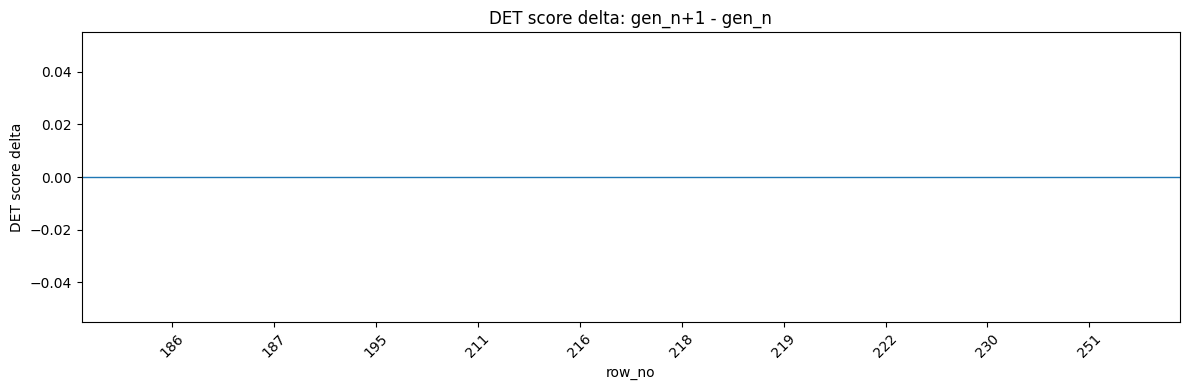

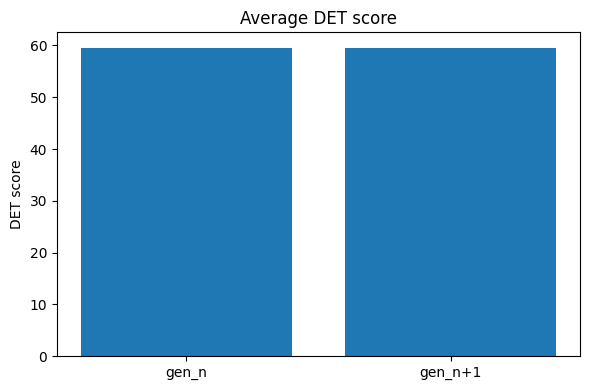


Artifacts:
FINAL_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449
run_index: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/final_run_index.csv
compare: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/final_gen_n_vs_gen_n1_compare.csv
summary: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/final_summary.csv
reason_delta: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/final_failure_reason_delta.csv
before_eval_rows: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/gen_n_eval_rows.csv
after_eval_rows: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/final_gen_compare_20260626_153449/gen_n1_eval_

In [53]:
# ============================================================
# FINAL ONE-CELL GEN_N vs GEN_N+1 COMPARISON
# Use canonical utils.ga_search.cli eval, NOT model_suite_benchmark.
# This avoids the unsupported --genome-json error.
# ============================================================

import os
import re
import json
import shlex
import time
import subprocess
from pathlib import Path
from datetime import datetime
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 300)

# ------------------------------------------------------------
# 0. Resolve core paths robustly after kernel restart
# ------------------------------------------------------------
BASE_DIR = Path(globals().get("BASE_DIR", os.environ.get("JOILANG_BASE_DIR", "/home/mgjeong/Desktop/llm/JOILang-Server"))).expanduser().resolve()
JOI_PY = Path(globals().get("JOI_PY", os.environ.get("JOI_PY", "/home/mgjeong/miniconda3/envs/joi/bin/python3.10"))).expanduser().resolve()
LOCAL_MODEL_BASE = Path(globals().get("LOCAL_MODEL_BASE", os.environ.get("LOCAL_MODEL_BASE", "/home/mgjeong/Desktop/llm/local_models"))).expanduser().resolve()

DATASET = Path(globals().get("DATASET", BASE_DIR / "datasets" / "JOICommands-280.csv")).expanduser().resolve()
SERVICE_SCHEMA = Path(globals().get("SERVICE_SCHEMA", BASE_DIR / "datasets" / "service_list_ver2.0.1.json")).expanduser().resolve()

MODEL = str(globals().get("MODEL", os.environ.get("JOI_GA_MODEL", "gpt_mg.version0_13")))
MODEL_KEY = str(os.environ.get("FINAL_MODEL_KEY", globals().get("MODEL_KEY", globals().get("MODEL_KEY_7B", "qwen25_coder_7b"))))
LOCAL_DEVICE = str(globals().get("LOCAL_DEVICE", os.environ.get("LOCAL_DEVICE", "cuda:0")))

MAX_NEW_TOKENS = int(os.environ.get("FINAL_MAX_NEW_TOKENS", str(globals().get("MAX_NEW_TOKENS", globals().get("MAX_NEW_TOKENS_7B", 512)))))
TIMEOUT_SEC = int(os.environ.get("FINAL_TIMEOUT_SEC", "1800"))
DET_THRESHOLD = int(os.environ.get("FINAL_DET_THRESHOLD", "70"))

assert BASE_DIR.exists(), BASE_DIR
assert JOI_PY.exists(), JOI_PY
assert DATASET.exists(), DATASET
assert SERVICE_SCHEMA.exists(), SERVICE_SCHEMA

def final_ts():
    return datetime.now().strftime("%Y%m%d_%H%M%S")

FINAL_ROOT = BASE_DIR / "artifacts" / "ga_search_tutorial_runs" / f"final_gen_compare_{final_ts()}"
FINAL_ROOT.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("JOI_PY:", JOI_PY)
print("MODEL:", MODEL)
print("MODEL_KEY:", MODEL_KEY)
print("LOCAL_MODEL_BASE:", LOCAL_MODEL_BASE)
print("LOCAL_DEVICE:", LOCAL_DEVICE)
print("MAX_NEW_TOKENS:", MAX_NEW_TOKENS)
print("FINAL_ROOT:", FINAL_ROOT)

# ------------------------------------------------------------
# 1. Find row set
# ------------------------------------------------------------
def _safe_read_csv(p):
    p = Path(p)
    if p.exists() and p.stat().st_size > 0:
        return pd.read_csv(p)
    return pd.DataFrame()

def _as_list_from_env(text):
    out = []
    for x in str(text or "").replace(";", ",").split(","):
        x = x.strip()
        if x:
            out.append(int(x))
    return out

def find_row_eval_csv():
    env = os.environ.get("ROW_EVALUATION_CSV", "").strip()
    if env and Path(env).exists():
        return Path(env)

    candidates = []
    for name in ["ROW_EVALUATION_CSV"]:
        if name in globals() and Path(globals()[name]).exists():
            candidates.append(Path(globals()[name]))

    roots = [
        globals().get("ROW_ADVISOR_OUT_DIR", None),
        globals().get("NB_ROOT", None),
        BASE_DIR / "artifacts" / "ga_search_tutorial_runs",
    ]
    for r in roots:
        if r is None:
            continue
        r = Path(r)
        if r.is_file() and r.name == "row_evaluation.csv":
            candidates.append(r)
        elif r.exists():
            candidates.extend(sorted(r.rglob("row_evaluation.csv"), key=lambda p: p.stat().st_mtime, reverse=True)[:20])

    # Prefer files paired with row_advisor_mapping/advisor_prompt_patches.json.
    scored = []
    for p in candidates:
        if not p.exists():
            continue
        score = p.stat().st_mtime
        if (p.parent.parent / "row_advisor_mapping" / "advisor_prompt_patches.json").exists():
            score += 10**12
        scored.append((score, p))

    if scored:
        return sorted(scored, reverse=True)[0][1]
    return None

ROW_EVALUATION_CSV_FINAL = find_row_eval_csv()
row_eval_ref = _safe_read_csv(ROW_EVALUATION_CSV_FINAL) if ROW_EVALUATION_CSV_FINAL else pd.DataFrame()

if os.environ.get("FINAL_COMPARE_ROWS", "").strip():
    FINAL_ROWS = _as_list_from_env(os.environ["FINAL_COMPARE_ROWS"])
elif not row_eval_ref.empty and "row_no" in row_eval_ref.columns:
    tmp = row_eval_ref.copy()
    if "det_score" in tmp.columns:
        tmp["_det_score_num"] = pd.to_numeric(tmp["det_score"], errors="coerce").fillna(0)
        tmp = tmp.sort_values("_det_score_num", ascending=True)
    FINAL_ROWS = tmp["row_no"].astype(int).drop_duplicates().head(int(os.environ.get("FINAL_COMPARE_LIMIT", "10"))).tolist()
else:
    FINAL_ROWS = [218, 222, 195, 186, 187, 251, 211, 219, 230, 216]

print("ROW_EVALUATION_CSV_FINAL:", ROW_EVALUATION_CSV_FINAL)
print("FINAL_ROWS:", FINAL_ROWS)

# ------------------------------------------------------------
# 2. Find patched genome
# ------------------------------------------------------------
def find_patched_genome():
    env = os.environ.get("GEN_N1_GENOME_JSON", "").strip()
    if env:
        p = Path(env).expanduser()
        if not p.exists():
            raise FileNotFoundError(p)
        return p

    var_candidates = [
        globals().get("DPMAR_PATCHED_GENOME", None),
        globals().get("DPMAC_PATCHED_GENOME", None),
        globals().get("DPMAS_PATCHED_GENOME", None),
    ]
    for v in var_candidates:
        if v:
            p = Path(v)
            if p.exists():
                return p

    search_roots = [
        globals().get("DPMA_GEN_PROMPT_ROOT", None),
        globals().get("DPMA_ROOT", None),
        globals().get("NB_ROOT", None),
        BASE_DIR / "artifacts" / "ga_search_tutorial_runs",
    ]

    hits = []
    for r in search_roots:
        if r is None:
            continue
        r = Path(r)
        if r.exists():
            hits.extend(r.rglob("*_patched_genome.json"))
            hits.extend(r.rglob("patched_genome.json"))

    hits = sorted(set(hits), key=lambda p: p.stat().st_mtime, reverse=True)
    if not hits:
        raise FileNotFoundError("No patched genome found. Run patch_apply / Cell 26 first, or set GEN_N1_GENOME_JSON.")
    return hits[0]

GEN_N1_GENOME = find_patched_genome()
print("GEN_N1_GENOME:", GEN_N1_GENOME)

# ------------------------------------------------------------
# 3. Optional sanity check: version0_13 block discovery issue
# ------------------------------------------------------------
def show_block_card_warning():
    cards = globals().get("DPMA_GEN_N_BLOCK_CARDS", [])
    if not cards:
        return
    df = pd.DataFrame(cards)
    if not df.empty:
        display_cols = [c for c in ["block_id", "block_family", "title", "char_count", "path"] if c in df.columns]
        print("\n[Block card sanity check]")
        display(df[display_cols].head(20))
        bad = (
            "block_id" in df.columns
            and len(set(df["block_id"].astype(str))) == 1
            and list(set(df["block_id"].astype(str)))[0] == "13"
        )
        if bad:
            print("[WARN] block_id=13 for all cards means the regex captured version0_13, not logical block IDs.")
            print("       This affects advisor block-targeting display, but does not prevent direct patched-genome evaluation.")

show_block_card_warning()

# ------------------------------------------------------------
# 4. Build local worker extra JSON for canonical CLI eval
# ------------------------------------------------------------
def resolve_local_model_name(model_key):
    # Prefer explicit env.
    explicit = os.environ.get("JOI_GA_LOCAL_MODEL_NAME", "").strip()
    if explicit and Path(explicit).exists():
        return explicit

    # Try repository registry if available.
    try:
        import sys
        if str(BASE_DIR) not in sys.path:
            sys.path.insert(0, str(BASE_DIR))
        from utils.ga_search.local_model_registry import resolve_local_model_config  # type: ignore
        cfg = resolve_local_model_config(str(model_key), local_model_base_dir=str(LOCAL_MODEL_BASE))
        for key in ["local_model_name", "model_path", "path"]:
            val = getattr(cfg, key, None) if not isinstance(cfg, dict) else cfg.get(key)
            if val and Path(str(val)).exists():
                return str(val)
    except Exception:
        pass

    # Fallback to known HF cache layouts.
    if "14b" in str(model_key).lower():
        patterns = [
            "/data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-14B-Instruct/snapshots/*",
            str(LOCAL_MODEL_BASE / "qwen25_coder_14b"),
        ]
    else:
        patterns = [
            "/data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-7B-Instruct/snapshots/*",
            str(LOCAL_MODEL_BASE / "qwen25_coder_7b"),
        ]

    for pat in patterns:
        matches = sorted(Path("/").glob(pat.lstrip("/"))) if "*" in pat else [Path(pat)]
        matches = [p for p in matches if p.exists()]
        if matches:
            return str(matches[-1])

    # Last resort: let backend fail clearly.
    return str(LOCAL_MODEL_BASE / str(model_key))

LOCAL_MODEL_NAME = resolve_local_model_name(MODEL_KEY)

LLM_EXTRA = {
    "local_worker": str(BASE_DIR / "utils" / "ga_search" / "local_worker.py"),
    "worker_python": str(JOI_PY),
    "local_model_name": LOCAL_MODEL_NAME,
    "local_model_base_dir": str(LOCAL_MODEL_BASE),
    "local_device": LOCAL_DEVICE,
    "local_files_only": True,
    "local_trust_remote_code": True,
    "local_dtype": os.environ.get("FINAL_LOCAL_DTYPE", "bf16"),
    "local_load_in_4bit": os.environ.get("FINAL_LOAD_IN_4BIT", "false").lower() == "true",
    "local_max_new_tokens": MAX_NEW_TOKENS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "temperature": 0.0,
    "model_key": MODEL_KEY,
}

print("LOCAL_MODEL_NAME:", LOCAL_MODEL_NAME, "exists=", Path(LOCAL_MODEL_NAME).exists())
print("LLM_EXTRA:")
print(json.dumps(LLM_EXTRA, ensure_ascii=False, indent=2))

# ------------------------------------------------------------
# 5. Run canonical CLI eval for gen_n and gen_n+1
# ------------------------------------------------------------
def final_run_cmd(cmd, log_path, timeout_sec):
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env["CUDA_VISIBLE_DEVICES"] = str(os.environ.get("CUDA_VISIBLE_DEVICES_FOR_NOTEBOOK", "0"))
    env["LD_LIBRARY_PATH"] = ""

    cmd = [str(x) for x in cmd]
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)

    print("\n[CMD]")
    print(" ".join(shlex.quote(x) for x in cmd))
    print("[LOG]", log_path)

    t0 = time.time()
    proc = subprocess.run(
        cmd,
        cwd=str(BASE_DIR),
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout_sec + 300,
    )
    elapsed = time.time() - t0
    out = proc.stdout or ""
    log_path.write_text(out, encoding="utf-8", errors="replace")
    print(out[-6000:])
    print(f"[RC] {proc.returncode} [elapsed] {elapsed:.2f}s")
    return proc.returncode, out

def cli_eval_one(row_no, genome_json, label):
    out_dir = FINAL_ROOT / label
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(JOI_PY), "-m", "utils.ga_search.cli", "eval",
        "--model", MODEL,
        "--dataset", str(DATASET),
        "--service-schema", str(SERVICE_SCHEMA),
        "--llm-mode", "worker",
        "--engine-mode", "real",
        "--model-key", MODEL_KEY,
        "--det-profile", "strict",
        "--det-threshold", str(DET_THRESHOLD),
        "--out-dir", str(out_dir),
        "--print-mode", "summary",
        "--row-no", str(int(row_no)),
        "--candidate-k", "1",
        "--timeout-sec", str(TIMEOUT_SEC),
        "--llm-extra-json", json.dumps(LLM_EXTRA, ensure_ascii=False),
    ]

    if genome_json:
        cmd += ["--genome-json", str(genome_json)]

    rc, out = final_run_cmd(cmd, out_dir / "run.log", TIMEOUT_SEC)
    return out_dir, rc

def find_eval_csv_in_dir(root):
    root = Path(root)
    candidates = [
        root / "eval" / "row_evaluation.csv",
        root / "row_evaluation.csv",
    ]
    candidates.extend(root.rglob("row_evaluation.csv"))
    for p in candidates:
        if p.exists() and p.stat().st_size > 0:
            return p
    return None

records = []
before_frames = []
after_frames = []

for i, row_no in enumerate(FINAL_ROWS, start=1):
    print("\n" + "=" * 120)
    print(f"[{i}/{len(FINAL_ROWS)}] row={row_no}")
    print("=" * 120)

    before_dir, before_rc = cli_eval_one(
        row_no=row_no,
        genome_json=None,
        label=f"gen_n_row{int(row_no):03d}_{final_ts()}",
    )

    after_dir, after_rc = cli_eval_one(
        row_no=row_no,
        genome_json=GEN_N1_GENOME,
        label=f"gen_n1_row{int(row_no):03d}_{final_ts()}",
    )

    before_csv = find_eval_csv_in_dir(before_dir)
    after_csv = find_eval_csv_in_dir(after_dir)

    if before_csv:
        bdf = pd.read_csv(before_csv)
        bdf["_run_dir"] = str(before_dir)
        bdf["_eval_csv"] = str(before_csv)
        before_frames.append(bdf)

    if after_csv:
        adf = pd.read_csv(after_csv)
        adf["_run_dir"] = str(after_dir)
        adf["_eval_csv"] = str(after_csv)
        after_frames.append(adf)

    records.append({
        "row_no": int(row_no),
        "gen_n_dir": str(before_dir),
        "gen_n_rc": before_rc,
        "gen_n_eval_csv": str(before_csv or ""),
        "gen_n1_dir": str(after_dir),
        "gen_n1_rc": after_rc,
        "gen_n1_eval_csv": str(after_csv or ""),
        "gen_n1_genome": str(GEN_N1_GENOME),
    })

run_index_df = pd.DataFrame(records)
run_index_path = FINAL_ROOT / "final_run_index.csv"
run_index_df.to_csv(run_index_path, index=False, encoding="utf-8-sig")

before_all = pd.concat(before_frames, ignore_index=True) if before_frames else pd.DataFrame()
after_all = pd.concat(after_frames, ignore_index=True) if after_frames else pd.DataFrame()

before_path = FINAL_ROOT / "gen_n_eval_rows.csv"
after_path = FINAL_ROOT / "gen_n1_eval_rows.csv"
before_all.to_csv(before_path, index=False, encoding="utf-8-sig")
after_all.to_csv(after_path, index=False, encoding="utf-8-sig")

print("\nrun_index_path:", run_index_path)
print("before_path:", before_path)
print("after_path:", after_path)

# ------------------------------------------------------------
# 6. Compare
# ------------------------------------------------------------
def normalize_for_compare(df, suffix):
    if df.empty:
        return pd.DataFrame()
    df = df.copy()
    df["row_no"] = df["row_no"].astype(int)
    keep = [c for c in [
        "row_no", "category", "det_score", "det_pass", "failure_reasons",
        "generated_code", "gt_code", "generation_error_type", "generation_error_count",
        "gt_similarity", "schedule_match", "cron_match", "period_match",
        "gt_service_coverage", "gt_receiver_coverage", "numeric_grounding", "enum_grounding",
        "_run_dir", "_eval_csv"
    ] if c in df.columns]
    df = df[keep].drop_duplicates("row_no", keep="last")
    rename = {c: f"{c}_{suffix}" for c in df.columns if c != "row_no"}
    return df.rename(columns=rename)

b = normalize_for_compare(before_all, "before")
a = normalize_for_compare(after_all, "after")

compare = b.merge(a, on="row_no", how="outer")

if "det_score_before" in compare.columns and "det_score_after" in compare.columns:
    compare["det_score_before"] = pd.to_numeric(compare["det_score_before"], errors="coerce")
    compare["det_score_after"] = pd.to_numeric(compare["det_score_after"], errors="coerce")
    compare["det_score_delta"] = compare["det_score_after"] - compare["det_score_before"]

for col in ["generated_code_before", "generated_code_after"]:
    if col in compare.columns:
        compare[col + "_nonempty"] = compare[col].fillna("").astype(str).str.strip().ne("")

def parse_reasons(x):
    if isinstance(x, list):
        return [str(v) for v in x]
    try:
        v = json.loads(str(x))
        return [str(z) for z in v] if isinstance(v, list) else []
    except Exception:
        return []

before_reason_counter = Counter()
after_reason_counter = Counter()

if "failure_reasons_before" in compare.columns:
    for x in compare["failure_reasons_before"]:
        before_reason_counter.update(parse_reasons(x))

if "failure_reasons_after" in compare.columns:
    for x in compare["failure_reasons_after"]:
        after_reason_counter.update(parse_reasons(x))

reason_delta = pd.DataFrame([
    {
        "failure_reason": k,
        "before_count": before_reason_counter.get(k, 0),
        "after_count": after_reason_counter.get(k, 0),
        "delta": after_reason_counter.get(k, 0) - before_reason_counter.get(k, 0),
    }
    for k in sorted(set(before_reason_counter) | set(after_reason_counter))
]).sort_values(["delta", "failure_reason"], ascending=[False, True])

summary = {
    "rows": int(len(compare)),
    "gen_n_rc_nonzero": int((run_index_df["gen_n_rc"] != 0).sum()),
    "gen_n1_rc_nonzero": int((run_index_df["gen_n1_rc"] != 0).sum()),
    "avg_det_before": float(compare["det_score_before"].mean()) if "det_score_before" in compare else None,
    "avg_det_after": float(compare["det_score_after"].mean()) if "det_score_after" in compare else None,
    "avg_det_delta": float(compare["det_score_delta"].mean()) if "det_score_delta" in compare else None,
    "det_pass_before": float(compare["det_pass_before"].astype(str).str.lower().isin(["true", "1"]).mean()) if "det_pass_before" in compare else None,
    "det_pass_after": float(compare["det_pass_after"].astype(str).str.lower().isin(["true", "1"]).mean()) if "det_pass_after" in compare else None,
    "generated_nonempty_before": float(compare["generated_code_before_nonempty"].mean()) if "generated_code_before_nonempty" in compare else None,
    "generated_nonempty_after": float(compare["generated_code_after_nonempty"].mean()) if "generated_code_after_nonempty" in compare else None,
    "genome": str(GEN_N1_GENOME),
}

summary_df = pd.DataFrame([summary])

compare_path = FINAL_ROOT / "final_gen_n_vs_gen_n1_compare.csv"
summary_path = FINAL_ROOT / "final_summary.csv"
reason_delta_path = FINAL_ROOT / "final_failure_reason_delta.csv"

compare.to_csv(compare_path, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
reason_delta.to_csv(reason_delta_path, index=False, encoding="utf-8-sig")

print("\n" + "=" * 120)
print("FINAL SUMMARY")
print("=" * 120)
display(summary_df)

print("\n" + "=" * 120)
print("ROW-LEVEL COMPARISON")
print("=" * 120)
cols = [c for c in [
    "row_no",
    "category_before",
    "det_score_before",
    "det_score_after",
    "det_score_delta",
    "det_pass_before",
    "det_pass_after",
    "generated_code_before_nonempty",
    "generated_code_after_nonempty",
    "generation_error_type_before",
    "generation_error_type_after",
    "failure_reasons_before",
    "failure_reasons_after",
] if c in compare.columns]
display(compare[cols].sort_values("det_score_delta", ascending=False if "det_score_delta" in compare.columns else True))

print("\n" + "=" * 120)
print("FAILURE REASON DELTA")
print("=" * 120)
display(reason_delta)

# ------------------------------------------------------------
# 7. Graphs
# ------------------------------------------------------------
if "det_score_delta" in compare.columns and not compare.empty:
    plt.figure(figsize=(12, 4))
    plot_df = compare.sort_values("row_no")
    plt.bar(plot_df["row_no"].astype(str), plot_df["det_score_delta"].fillna(0))
    plt.axhline(0, linewidth=1)
    plt.title("DET score delta: gen_n+1 - gen_n")
    plt.xlabel("row_no")
    plt.ylabel("DET score delta")
    plt.xticks(rotation=45)
    plt.tight_layout()
    delta_png = FINAL_ROOT / "det_score_delta_by_row.png"
    plt.savefig(delta_png, dpi=160)
    plt.show()

if "avg_det_before" in summary and summary["avg_det_before"] is not None:
    plt.figure(figsize=(6, 4))
    plt.bar(["gen_n", "gen_n+1"], [summary["avg_det_before"], summary["avg_det_after"]])
    plt.title("Average DET score")
    plt.ylabel("DET score")
    plt.tight_layout()
    avg_png = FINAL_ROOT / "avg_det_before_after.png"
    plt.savefig(avg_png, dpi=160)
    plt.show()

print("\nArtifacts:")
print("FINAL_ROOT:", FINAL_ROOT)
print("run_index:", run_index_path)
print("compare:", compare_path)
print("summary:", summary_path)
print("reason_delta:", reason_delta_path)
print("before_eval_rows:", before_path)
print("after_eval_rows:", after_path)

## 32. One-cell iterative DPMA loop: `gen_n → gen_n+1` repeated N times

이 cell은 `DPMA_LOOP_GENERATIONS=10`처럼 설정하면, 지정한 row set에 대해 다음 과정을 N번 반복합니다.

```text
gen_n 평가
→ 최신 DET 결과로 diagnostic summary 구성
→ advisor mutation payload 생성
→ mutation validation
→ patch_apply
→ gen_n+1 생성
→ 다음 generation으로 진행
```

기본값은 안전을 위해 `RUN_DPMA_ITER_LOOP=false`입니다. 실행하려면 cell 상단 또는 이전 cell에서 다음을 설정하세요.

```python
os.environ["RUN_DPMA_ITER_LOOP"] = "true"
os.environ["DPMA_LOOP_GENERATIONS"] = "10"
os.environ["DPMA_LOOP_ROWS"] = "1,2,3,121,170,251"
os.environ["DPMA_LOOP_ADVISOR"] = "rulebased"  # rulebased 또는 cloud
```

주의: `DPMA_LOOP_ADVISOR=cloud`는 각 generation마다 API 호출을 수행합니다. local self-advisor는 자동 반복보다는 block-local 수동 검증 후 연결하는 것을 권장합니다.


In [40]:
os.environ["RUN_DPMA_ITER_LOOP"] = "true"
os.environ["DPMA_LOOP_GENERATIONS"] = "10"
os.environ["DPMA_LOOP_ROWS"] = ""
os.environ["DPMA_LOOP_ADVISOR"] = "cloud"  # rulebased 또는 cloud

In [41]:
# ============================================================
# Cell 32. One-cell iterative DPMA loop: repeat eval -> mutation -> gen_n+1
# ============================================================

RUN_DPMA_ITER_LOOP = os.environ.get("RUN_DPMA_ITER_LOOP", "false").lower() == "true"
DPMA_LOOP_GENERATIONS = int(os.environ.get("DPMA_LOOP_GENERATIONS", "10"))
DPMA_LOOP_ADVISOR = os.environ.get("DPMA_LOOP_ADVISOR", "rulebased").lower().strip()  # rulebased | cloud
DPMA_LOOP_ROWS_TEXT = os.environ.get("DPMA_LOOP_ROWS", "").strip()
DPMA_LOOP_LIMIT = int(os.environ.get("DPMA_LOOP_LIMIT", "12"))
DPMA_LOOP_MODEL_KEY = os.environ.get("DPMA_LOOP_MODEL_KEY", str(globals().get("MODEL_KEY", globals().get("MODEL_KEY_7B", "qwen25_coder_7b"))))
DPMA_LOOP_MAX_NEW_TOKENS = int(os.environ.get("DPMA_LOOP_MAX_NEW_TOKENS", str(globals().get("MAX_NEW_TOKENS", globals().get("MAX_NEW_TOKENS_7B", 1024)))))
DPMA_LOOP_TIMEOUT_SEC = int(os.environ.get("DPMA_LOOP_TIMEOUT_SEC", "18000"))
DPMA_LOOP_NAME = dpma_safe_name(os.environ.get("DPMA_LOOP_NAME", f"dpma_loop_{DPMA_LOOP_ADVISOR}"))
DPMA_LOOP_MAX_PATCHES = int(os.environ.get("DPMA_LOOP_MAX_PATCHES", "16"))
DPMA_LOOP_CLOUD_MODEL = os.environ.get("DPMA_LOOP_CLOUD_MODEL", os.environ.get("DPMAC_MODEL", "gpt-4.1-mini"))
DPMA_LOOP_CLOUD_TEMPERATURE = float(os.environ.get("DPMA_LOOP_CLOUD_TEMPERATURE", "0.1"))
DPMA_LOOP_HTTP_TIMEOUT_SEC = int(os.environ.get("DPMA_LOOP_HTTP_TIMEOUT_SEC", "3000"))
DPMA_LOOP_START_GENOME = os.environ.get("DPMA_LOOP_START_GENOME", "").strip()

DPMA_ITER_ROOT = DPMA_ROOT / "iterative_loops" / f"{DPMA_LOOP_NAME}_{dpma_ts()}"

# -----------------------------
# Iterative-loop helpers
# -----------------------------
def dpma_loop_rows():
    if DPMA_LOOP_ROWS_TEXT:
        return dpma_parse_row_list(DPMA_LOOP_ROWS_TEXT)
    return dpma_default_test_rows(DPMA_LOOP_LIMIT)

def dpma_loop_run_row(row_no, genome_json, gen_label):
    extra = []
    if genome_json:
        extra += ["--genome-json", str(genome_json)]

    label = f"{DPMA_LOOP_NAME}_{gen_label}_row{int(row_no):03d}_{dpma_ts()}"
    root, rc = run_model_suite_row(
        label=label,
        model_key=DPMA_LOOP_MODEL_KEY,
        row_no=int(row_no),
        max_new_tokens=DPMA_LOOP_MAX_NEW_TOKENS,
        timeout_sec=DPMA_LOOP_TIMEOUT_SEC,
        extra_args=extra,
        check=False,
    )
    return Path(root), rc

def dpma_loop_eval_generation(rows, genome_json, gen_idx):
    gen_label = f"gen{int(gen_idx):02d}"
    eval_root = DPMA_ITER_ROOT / "evals" / gen_label
    eval_root.mkdir(parents=True, exist_ok=True)

    records = []
    eval_frames = []
    for k, row_no in enumerate(rows, start=1):
        print("\n" + "=" * 110)
        print(f"[EVAL {gen_label}] row {k}/{len(rows)} = {row_no}, genome={genome_json or 'BASE gen_0'}")
        run_root, rc = dpma_loop_run_row(row_no, genome_json, gen_label)
        eval_csv = dpma_find_eval_csv(run_root, model_key=DPMA_LOOP_MODEL_KEY)
        records.append({
            "generation": int(gen_idx),
            "row_no": int(row_no),
            "genome_json": str(genome_json or ""),
            "run_root": str(run_root),
            "rc": rc,
            "eval_csv": str(eval_csv or ""),
        })
        if eval_csv:
            df = pd.read_csv(eval_csv)
            df["_generation"] = int(gen_idx)
            df["_run_root"] = str(run_root)
            df["_eval_csv"] = str(eval_csv)
            eval_frames.append(df)

    index_df = pd.DataFrame(records)
    index_path = eval_root / "eval_index.csv"
    index_df.to_csv(index_path, index=False, encoding="utf-8-sig")

    eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
    eval_rows_path = eval_root / "eval_rows.csv"
    eval_df.to_csv(eval_rows_path, index=False, encoding="utf-8-sig")

    return {
        "generation": int(gen_idx),
        "genome_json": Path(genome_json) if genome_json else None,
        "eval_root": eval_root,
        "index_path": index_path,
        "eval_rows_path": eval_rows_path,
        "index_df": index_df,
        "eval_df": eval_df,
    }

def dpma_loop_count_reasons(eval_df):
    cnt = Counter()
    if eval_df is None or eval_df.empty or "failure_reasons" not in eval_df.columns:
        return cnt
    for x in eval_df["failure_reasons"]:
        cnt.update(dpma_as_list(x))
    return cnt

def dpma_loop_detect_output_collapse(eval_df):
    if eval_df is None or eval_df.empty or "generated_code" not in eval_df.columns:
        return False, ""
    codes = eval_df["generated_code"].fillna("").astype(str).str.strip()
    codes = codes[codes.ne("")]
    if codes.empty:
        return False, ""
    vc = codes.value_counts()
    top_code = str(vc.index[0])
    top_count = int(vc.iloc[0])
    threshold = max(2, int(len(eval_df) * 0.5))
    return top_count >= threshold, top_code[:500]

def dpma_loop_signal_to_rule(signal):
    sig = str(signal or "").split(":", 1)[0]
    mapping = {
        "unknown_service": {
            "family": "Service_Mapping", "block": "02",
            "text": "Never invent service/member names. Copy the exact canonical device-prefixed service member from the injected schema; do not emit camelCase, class-style, capitalized, or paraphrased service names.",
            "effect": ["reduce unknown_service", "increase service coverage"],
        },
        "gt_service_coverage": {
            "family": "Service_Mapping", "block": "02",
            "text": "Include every service implied by the current command and select services only from the injected schema under the selected receiver; do not substitute adjacent service families.",
            "effect": ["increase gt_service_coverage"],
        },
        "gt_receiver_coverage": {
            "family": "Receiver_Tag_Preservation", "block": "02",
            "text": "Select receiver tags from the current command target before service selection. Preserve owner, location, group, and sector tags exactly, and never reuse a receiver from another row.",
            "effect": ["increase receiver coverage"],
        },
        "enum_grounding": {
            "family": "Enum_Grounding", "block": "02",
            "text": "For enum-valued services, copy the allowed enum string exactly from the selected service descriptor; do not translate, paraphrase, or borrow enum values from another device or previous row.",
            "effect": ["reduce enum_grounding"],
        },
        "period_mismatch": {
            "family": "Temporal_Rule", "block": "06",
            "text": "Classify schedule type before writing JSON. Use period=0 for one-shot or scheduled one-shot commands, preserve explicit cron triggers, and use positive period only when repeated monitoring is explicit.",
            "effect": ["reduce period_mismatch"],
        },
        "cron_mismatch": {
            "family": "Temporal_Rule", "block": "06",
            "text": "For explicit fixed times, weekdays, midnight, or scheduled commands, derive cron first and preserve it exactly; do not replace a fixed schedule with only a period loop or Clock guard.",
            "effect": ["reduce cron_mismatch"],
        },
        "numeric_grounding": {
            "family": "Numeric_Unit_Grounding", "block": "06",
            "text": "Preserve every numeric literal required by the current command and bind it to the selected service argument or condition. Convert units using the selected service descriptor and never drop thresholds, durations, or target values.",
            "effect": ["reduce numeric_grounding"],
        },
        "missing_generated_code": {
            "family": "Intent_Fulfillment", "block": "06",
            "text": "For every non-empty command, the code field must contain the required JOILang action, condition, schedule body, or notification; do not return empty code unless the official GT behavior is empty.",
            "effect": ["reduce missing_generated_code"],
        },
        "missing_required_key": {
            "family": "Output_Schema", "block": "03",
            "text": "Return exactly one bare JSON object with required keys name, cron, period, and code. Do not omit required keys, add markdown fences, or rename code to an unsupported field.",
            "effect": ["reduce missing_required_key", "reduce invalid_json"],
        },
        "gt_mismatch": {
            "family": "DET_Helper", "block": "06",
            "text": "Before final JSON, compare schedule, receiver, service, numeric literals, enum arguments, dataflow, and action order against the current command; repair concrete mismatches before output.",
            "effect": ["improve strict DET score"],
        },
    }
    return mapping.get(sig, {
        "family": "DET_Helper", "block": "06",
        "text": f"When {sig} appears, compare the row's GT and generated components and repair the concrete mismatch before final JSON.",
        "effect": [f"reduce {sig}"],
    })

def dpma_loop_diagnostics_for_signal(eval_df, signal, max_items=4):
    sig = str(signal or "").split(":", 1)[0]
    rows = []
    if eval_df is None or eval_df.empty:
        return rows
    for _, r in eval_df.iterrows():
        reasons = [str(x).split(":", 1)[0] for x in dpma_as_list(r.get("failure_reasons", []))]
        if sig not in reasons and sig != "output_collapse":
            continue
        diff = dpma_as_dict(r.get("diff_summary", {}))
        row_no = r.get("row_no", "")
        if sig in {"unknown_service", "gt_service_coverage"}:
            rows.append(f"row {row_no}: service mismatch: gt={diff.get('gt_services', [])}, generated={diff.get('generated_services', [])}")
        elif sig == "gt_receiver_coverage":
            rows.append(f"row {row_no}: receiver mismatch: gt={diff.get('gt_receivers', [])}, generated={diff.get('generated_receivers', [])}")
        elif sig == "numeric_grounding":
            rows.append(f"row {row_no}: numeric mismatch: gt={diff.get('gt_numeric_literals', [])}, generated={diff.get('generated_numeric_literals', [])}")
        elif sig == "enum_grounding":
            rows.append(f"row {row_no}: enum/string mismatch: gt={diff.get('gt_string_args', [])}, generated={diff.get('generated_string_args', [])}")
        elif sig == "period_mismatch":
            gt = dpma_as_dict(r.get("gt_json", {})); gen = dpma_as_dict(r.get("generated_json", {}))
            rows.append(f"row {row_no}: period mismatch: gt={gt.get('period')!r}, generated={gen.get('period')!r}")
        elif sig == "cron_mismatch":
            gt = dpma_as_dict(r.get("gt_json", {})); gen = dpma_as_dict(r.get("generated_json", {}))
            rows.append(f"row {row_no}: cron mismatch: gt={gt.get('cron')!r}, generated={gen.get('cron')!r}")
        else:
            rows.append(f"row {row_no}: {sig}; failure_reasons={r.get('failure_reasons', '')}")
        if len(rows) >= max_items:
            break
    return rows

def dpma_loop_rulebased_payload(eval_df, gen_idx, max_patches=8):
    cnt = dpma_loop_count_reasons(eval_df)
    collapse, top_code = dpma_loop_detect_output_collapse(eval_df)
    if collapse:
        cnt["output_collapse"] += len(eval_df)

    priority_order = [
        "output_collapse", "unknown_service", "gt_service_coverage", "gt_receiver_coverage",
        "period_mismatch", "cron_mismatch", "numeric_grounding", "enum_grounding",
        "missing_generated_code", "missing_required_key", "gt_mismatch",
    ]
    signals = [s for s in priority_order if cnt.get(s, 0) > 0]
    for s, _ in cnt.most_common():
        base = str(s).split(":", 1)[0]
        if base not in signals:
            signals.append(base)
    signals = signals[:max_patches]

    patches = []
    for i, sig in enumerate(signals):
        if sig == "output_collapse":
            rule = {
                "family": "Skeleton", "block": "06",
                "text": "Solve each dataset row independently from the current command only. Never reuse a previous row's JSON name, receiver, service, enum argument, numeric argument, or code skeleton.",
                "effect": ["reduce output_collapse"],
            }
            diagnostics = [f"output collapse detected: repeated generated code starts with {top_code[:220]!r}"]
        else:
            rule = dpma_loop_signal_to_rule(sig)
            diagnostics = dpma_loop_diagnostics_for_signal(eval_df, sig, max_items=4)
        patches.append({
            "patch_id": f"iter_gen{int(gen_idx):02d}_{i:02d}_{dpma_safe_name(sig)}",
            "target_block_family": rule["family"],
            "target_block_id": rule["block"],
            "operation": "append_micro_rule",
            "priority": max(1, 100 - i),
            "patch_text": rule["text"],
            "rationale": f"Generated from gen_{int(gen_idx)} strict DET failures; signal={sig}, count={cnt.get(sig, 0)}.",
            "evidence_rows": [str(x) for x in eval_df.get("row_no", pd.Series([], dtype=str)).astype(str).head(12).tolist()],
            "evidence_diagnostics": diagnostics,
            "mutation_intent": "iterative_dpma_rulebased_prompt_mutation",
            "expected_effect": rule.get("effect", []),
            "token_delta_estimate": len(rule["text"].split()),
        })

    return {
        "advisor_meta": {
            "schema_version": "row_advisor_prompt_patches_v1",
            "source": f"{DPMA_LOOP_NAME}_gen{int(gen_idx):02d}_{DPMA_LOOP_ADVISOR}",
            "official_metric": "strict_det",
            "cloud_is_auxiliary": DPMA_LOOP_ADVISOR == "cloud",
        },
        "prompt_patches": patches,
    }

def dpma_loop_cloud_payload(eval_df, gen_idx):
    api_key = os.environ.get("OPENAI_API_KEY", "").strip()
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY is not set for DPMA_LOOP_ADVISOR=cloud")

    # Compact evidence only; do not send full 30k gen prompt.
    evidence_rows = []
    for _, r in eval_df.head(12).iterrows():
        evidence_rows.append({
            "row_no": str(r.get("row_no", "")),
            "category": str(r.get("category", "")),
            "det_score": str(r.get("det_score", "")),
            "failure_reasons": dpma_as_list(r.get("failure_reasons", [])),
            "gt_code": dpma_compact_text(r.get("gt_code", ""), 800),
            "generated_code": dpma_compact_text(r.get("generated_code", ""), 800),
            "diff_summary": dpma_as_dict(r.get("diff_summary", {})),
        })

    block_candidates = dpma_soft_block_candidates(eval_df, DPMA_GEN_N_BLOCK_CARDS, max_cards=8)
    prompt_package = {
        "task": "Generate block-level JOILang generation prompt mutations for the next prompt generation.",
        "generation": int(gen_idx),
        "official_metric": "strict_det",
        "expected_block_by_family": EXPECTED_BLOCK_BY_FAMILY,
        "forbidden_families": sorted(FORBIDDEN_MUTATION_FAMILIES),
        "selected_block_candidates": block_candidates,
        "evidence_rows": evidence_rows,
        "current_rulebased_payload": dpma_loop_rulebased_payload(eval_df, gen_idx, max_patches=DPMA_LOOP_MAX_PATCHES),
        "output_schema": {
            "advisor_meta": {},
            "prompt_patches": [{
                "patch_id": "string",
                "target_block_family": "one of selected family names",
                "target_block_id": "02/03/06/AUX",
                "operation": "append_micro_rule",
                "priority": 100,
                "patch_text": "imperative localized mutation text",
                "rationale": "diagnostic-grounded reason",
                "evidence_rows": ["row ids"],
                "evidence_diagnostics": ["concrete diagnostics"],
                "mutation_intent": "iterative_dpma_cloud_prompt_mutation",
            }]
        },
    }
    system_prompt = (
        "You are a JOILang prompt mutation advisor. You do not generate JOILang code and do not rewrite the full prompt. "
        "Use strict DET diagnostics and selected prompt block cards to output a non-empty JSON mutation payload only. "
        "Do not include runtime-only Block 00 patches."
    )
    user_prompt = "Generate advisor_prompt_patches JSON only.\n\n" + json.dumps(prompt_package, ensure_ascii=False, indent=2)

    payload = {
        "model": DPMA_LOOP_CLOUD_MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "temperature": DPMA_LOOP_CLOUD_TEMPERATURE,
        "response_format": {"type": "json_object"},
    }
    req = urllib.request.Request(
        "https://api.openai.com/v1/chat/completions",
        data=json.dumps(payload).encode("utf-8"),
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=DPMA_LOOP_HTTP_TIMEOUT_SEC) as resp:
        raw_text = resp.read().decode("utf-8")
    raw = json.loads(raw_text)
    content = raw["choices"][0]["message"]["content"]
    obj = dpma_extract_json_object(content) if "dpma_extract_json_object" in globals() else json.loads(content)

    raw_path = DPMA_ITER_ROOT / "cloud_raw" / f"cloud_response_gen{int(gen_idx):02d}_{dpma_ts()}.json"
    dpma_write_json(raw_path, raw)
    return obj

def dpma_loop_payload(eval_df, gen_idx):
    if DPMA_LOOP_ADVISOR == "cloud":
        try:
            obj = dpma_loop_cloud_payload(eval_df, gen_idx)
            normalized = dpma_normalize_mutation_payload(obj, source=f"{DPMA_LOOP_NAME}_cloud_gen{int(gen_idx):02d}")
            validation = dpma_validate_patch_payload(normalized)
            if validation.get("ok"):
                return normalized
            print("[WARN] cloud payload invalid; falling back to rulebased. validation=", validation)
        except Exception as exc:
            print("[WARN] cloud advisor failed; falling back to rulebased:", repr(exc))
    return dpma_loop_rulebased_payload(eval_df, gen_idx, max_patches=DPMA_LOOP_MAX_PATCHES)

def dpma_loop_summarize_eval(eval_df, gen_idx, genome_json):
    if eval_df is None or eval_df.empty:
        return {
            "generation": int(gen_idx), "genome_json": str(genome_json or ""),
            "rows": 0, "avg_det_score": None, "det_pass_rate": None,
            "generated_nonempty_rate": None, "generation_error_rate": None,
        }
    det = pd.to_numeric(eval_df.get("det_score", pd.Series([], dtype=float)), errors="coerce")
    det_pass = eval_df.get("det_pass", pd.Series([], dtype=str)).astype(str).str.lower().eq("true") if "det_pass" in eval_df.columns else pd.Series([False] * len(eval_df))
    nonempty = eval_df.get("generated_code", pd.Series([""] * len(eval_df))).fillna("").astype(str).str.strip().ne("")
    gen_err = eval_df.get("generation_error_type", pd.Series([""] * len(eval_df))).fillna("").astype(str).str.strip().ne("")
    return {
        "generation": int(gen_idx),
        "genome_json": str(genome_json or ""),
        "rows": int(len(eval_df)),
        "avg_det_score": float(det.mean()) if len(det) else None,
        "det_pass_rate": float(det_pass.mean()) if len(det_pass) else None,
        "det_pass_count": int(det_pass.sum()) if len(det_pass) else 0,
        "generated_nonempty_rate": float(nonempty.mean()) if len(nonempty) else None,
        "generated_nonempty_count": int(nonempty.sum()) if len(nonempty) else 0,
        "generation_error_rate": float(gen_err.mean()) if len(gen_err) else None,
        "generation_error_count": int(gen_err.sum()) if len(gen_err) else 0,
    }

# -----------------------------
# Execute iterative loop
# -----------------------------
print("RUN_DPMA_ITER_LOOP:", RUN_DPMA_ITER_LOOP)
print("DPMA_LOOP_GENERATIONS:", DPMA_LOOP_GENERATIONS)
print("DPMA_LOOP_ADVISOR:", DPMA_LOOP_ADVISOR)
print("DPMA_LOOP_ROWS_TEXT:", DPMA_LOOP_ROWS_TEXT)
print("DPMA_LOOP_MODEL_KEY:", DPMA_LOOP_MODEL_KEY)
print("DPMA_LOOP_MAX_NEW_TOKENS:", DPMA_LOOP_MAX_NEW_TOKENS)
print("DPMA_ITER_ROOT:", DPMA_ITER_ROOT)

DPMA_ITER_RECORDS = []
DPMA_ITER_SUMMARY_DF = pd.DataFrame()
DPMA_ITER_LAST_SUMMARY = None
DPMA_ITER_LAST_GENOME = Path(DPMA_LOOP_START_GENOME) if DPMA_LOOP_START_GENOME else None

if RUN_DPMA_ITER_LOOP:
    DPMA_ITER_ROOT.mkdir(parents=True, exist_ok=True)
    rows = dpma_loop_rows()
    print("DPMA iterative rows:", rows)

    current_genome = DPMA_ITER_LAST_GENOME
    generation_summaries = []

    for gen_idx in range(DPMA_LOOP_GENERATIONS):
        print("\n" + "#" * 120)
        print(f"DPMA ITERATION {gen_idx} -> {gen_idx + 1}")
        print("#" * 120)

        eval_info = dpma_loop_eval_generation(rows, current_genome, gen_idx)
        eval_df = eval_info["eval_df"]
        generation_summaries.append(dpma_loop_summarize_eval(eval_df, gen_idx, current_genome))

        if eval_df.empty:
            print("[STOP] No eval rows for current generation. Cannot mutate.")
            break

        mutation_payload = dpma_loop_payload(eval_df, gen_idx)
        mutation_payload_path = DPMA_ITER_ROOT / "mutation_payloads" / f"mutation_payload_gen{gen_idx:02d}_to_gen{gen_idx+1:02d}_{dpma_ts()}.json"
        dpma_write_json(mutation_payload_path, mutation_payload)

        validation = dpma_validate_patch_payload(dpma_normalize_mutation_payload(mutation_payload, source=f"loop_gen{gen_idx:02d}"))
        print("Mutation validation:")
        print(json.dumps(validation, ensure_ascii=False, indent=2))
        if not validation.get("ok"):
            print("[STOP] Mutation payload invalid. See", mutation_payload_path)
            break

        variant = f"{DPMA_LOOP_NAME}_gen{gen_idx:02d}_to_gen{gen_idx+1:02d}"
        gen_n1 = dpma_apply_payload_to_gen_n(
            mutation_payload_path,
            variant=variant,
            base_genome=current_genome,
            source=f"iter_{DPMA_LOOP_ADVISOR}",
        )

        record = {
            "iteration": int(gen_idx),
            "from_generation": int(gen_idx),
            "to_generation": int(gen_idx + 1),
            "advisor": DPMA_LOOP_ADVISOR,
            "eval_rows_path": str(eval_info["eval_rows_path"]),
            "eval_index_path": str(eval_info["index_path"]),
            "mutation_payload_path": str(mutation_payload_path),
            "patched_genome": str(gen_n1.get("patched_genome", "")),
            "gen_prompt": str(gen_n1.get("gen_prompt", "")),
            "diff": str(gen_n1.get("diff", "")),
            "report": str(gen_n1.get("report", "")),
        }
        DPMA_ITER_RECORDS.append(record)
        current_genome = Path(gen_n1["patched_genome"])
        DPMA_ITER_LAST_GENOME = current_genome

        pd.DataFrame(DPMA_ITER_RECORDS).to_csv(DPMA_ITER_ROOT / "iteration_records.csv", index=False, encoding="utf-8-sig")
        pd.DataFrame(generation_summaries).to_csv(DPMA_ITER_ROOT / "generation_summary_partial.csv", index=False, encoding="utf-8-sig")

    # Evaluate final gen_N after the last mutation so gen10 has a real score.
    final_gen = len(DPMA_ITER_RECORDS)
    if current_genome and final_gen > 0:
        print("\n" + "#" * 120)
        print(f"FINAL EVAL gen{final_gen:02d}")
        print("#" * 120)
        final_eval = dpma_loop_eval_generation(rows, current_genome, final_gen)
        generation_summaries.append(dpma_loop_summarize_eval(final_eval["eval_df"], final_gen, current_genome))

    DPMA_ITER_RECORDS_DF = pd.DataFrame(DPMA_ITER_RECORDS)
    DPMA_ITER_SUMMARY_DF = pd.DataFrame(generation_summaries)

    DPMA_ITER_RECORDS_PATH = DPMA_ITER_ROOT / "iteration_records.csv"
    DPMA_ITER_SUMMARY_PATH = DPMA_ITER_ROOT / "generation_summary.csv"
    DPMA_ITER_MANIFEST_PATH = DPMA_ITER_ROOT / "loop_manifest.json"

    DPMA_ITER_RECORDS_DF.to_csv(DPMA_ITER_RECORDS_PATH, index=False, encoding="utf-8-sig")
    DPMA_ITER_SUMMARY_DF.to_csv(DPMA_ITER_SUMMARY_PATH, index=False, encoding="utf-8-sig")
    dpma_write_json(DPMA_ITER_MANIFEST_PATH, {
        "loop_name": DPMA_LOOP_NAME,
        "advisor": DPMA_LOOP_ADVISOR,
        "requested_generations": DPMA_LOOP_GENERATIONS,
        "completed_mutations": len(DPMA_ITER_RECORDS),
        "rows": rows,
        "model_key": DPMA_LOOP_MODEL_KEY,
        "max_new_tokens": DPMA_LOOP_MAX_NEW_TOKENS,
        "root": str(DPMA_ITER_ROOT),
        "last_genome": str(DPMA_ITER_LAST_GENOME or ""),
        "summary_csv": str(DPMA_ITER_SUMMARY_PATH),
        "records_csv": str(DPMA_ITER_RECORDS_PATH),
    })

    DPMA_ITER_LAST_SUMMARY = DPMA_ITER_SUMMARY_PATH
    print("\nDONE iterative loop")
    print("DPMA_ITER_ROOT:", DPMA_ITER_ROOT)
    print("DPMA_ITER_RECORDS_PATH:", DPMA_ITER_RECORDS_PATH)
    print("DPMA_ITER_SUMMARY_PATH:", DPMA_ITER_SUMMARY_PATH)
    print("DPMA_ITER_LAST_GENOME:", DPMA_ITER_LAST_GENOME)
    display(DPMA_ITER_SUMMARY_DF)
    display(DPMA_ITER_RECORDS_DF)
else:
    print("Iterative loop skipped.")
    print('Set os.environ["RUN_DPMA_ITER_LOOP"]="true" and os.environ["DPMA_LOOP_GENERATIONS"]="10" to run gen0→gen10.')


RUN_DPMA_ITER_LOOP: True
DPMA_LOOP_GENERATIONS: 10
DPMA_LOOP_ADVISOR: cloud
DPMA_LOOP_ROWS_TEXT: 
DPMA_LOOP_MODEL_KEY: qwen25_coder_7b
DPMA_LOOP_MAX_NEW_TOKENS: 1024
DPMA_ITER_ROOT: /home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/iterative_loops/dpma_loop_cloud_20260625_225300
DPMA iterative rows: [218, 222, 195, 186, 187, 251, 211, 219, 230, 216, 217, 264]

########################################################################################################################
DPMA ITERATION 0 -> 1
########################################################################################################################

[EVAL gen00] row 1/12 = 218, genome=BASE gen_0

[CMD]
/home/mgjeong/miniconda3/envs/joi/bin/python3.10 -m utils.ga_search.model_suite_benchmark --model gpt_mg.version0_13 --model-key qwen25_coder_7b --llm-mode worker --local-model-base-dir /home/mgjeong/Desktop/llm/local_models --worker-p

,generation,genome_json,rows,avg_det_score,det_pass_rate,det_pass_count,generated_nonempty_rate,generated_nonempty_count,generation_error_rate,generation_error_count
0,0,,12,56.517283,0.083333,1.0,1.0,12.0,0.0,0.0
1,1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_patched_genome.json,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_patched_genome.json,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,iteration,from_generation,to_generation,advisor,eval_rows_path,eval_index_path,mutation_payload_path,patched_genome,gen_prompt,diff,report
0,0,0,1,cloud,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/iterative_loops/dpma_loop_cloud_20260625_225300/evals/gen00/eval_rows.csv,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/iterative_loops/dpma_loop_cloud_20260625_225300/evals/gen00/eval_index.csv,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/iterative_loops/dpma_loop_cloud_20260625_225300/mutation_payloads/mutation_payload_gen00_to_gen01_20260625_225908.json,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_patched_genome.json,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01.md,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_diff.md,/home/mgjeong/Desktop/llm/JOILang-Server/artifacts/ga_search_tutorial_runs/kernel_resume_20260625_212912/dpma_gen_prompt_experiments/gen_prompts/gen_prompt_dpma_loop_cloud_gen00_to_gen01_gen01_patch_report.json


## 수정된 blocks에 대한 코드 

In [34]:
import os

os.environ["RUN_DPMA_ITER_LOOP"] = "true"
os.environ["DPMA_LOOP_GENERATIONS"] = "10"
os.environ["DPMA_LOOP_ADVISOR"] = "rulebased"
os.environ["DPMA_LOOP_ROWS"] = ""
os.environ["DPMA_LOOP_MODEL_KEY"] = "qwen25_coder_7b"
os.environ["DPMA_LOOP_MAX_NEW_TOKENS"] = "1024"
os.environ["DPMA_LOOP_TIMEOUT_SEC"] = "18000"

In [36]:
# ============================================================
# FIX for Cell 32:
# Use canonical utils.ga_search.cli eval for genome_json support.
# Do NOT use model_suite_benchmark with --genome-json.
# ============================================================

def dpma_loop_build_llm_extra_json(model_key=None, max_new_tokens=None):
    """
    Build worker backend config for utils.ga_search.cli eval.
    This keeps gen_n and gen_n+1 under the same local worker/runtime condition.
    """
    model_key = model_key or DPMA_LOOP_MODEL_KEY
    max_new_tokens = int(max_new_tokens or DPMA_LOOP_MAX_NEW_TOKENS)

    base_dir = Path(globals().get("BASE_DIR", os.environ.get("JOILANG_BASE_DIR", "/home/mgjeong/Desktop/llm/JOILang-Server"))).expanduser().resolve()
    joi_py = Path(globals().get("JOI_PY", os.environ.get("JOI_PY", "/home/mgjeong/miniconda3/envs/joi/bin/python3.10"))).expanduser().resolve()
    local_model_base = Path(globals().get("LOCAL_MODEL_BASE", os.environ.get("LOCAL_MODEL_BASE", "/home/mgjeong/Desktop/llm/local_models"))).expanduser().resolve()
    local_device = str(globals().get("LOCAL_DEVICE", os.environ.get("LOCAL_DEVICE", "cuda:0")))

    def _resolve_model_name():
        explicit = os.environ.get("JOI_GA_LOCAL_MODEL_NAME", "").strip()
        if explicit and Path(explicit).exists():
            return explicit

        # Try registry if available.
        try:
            import sys
            if str(base_dir) not in sys.path:
                sys.path.insert(0, str(base_dir))
            from utils.ga_search.local_model_registry import resolve_local_model_config
            cfg = resolve_local_model_config(str(model_key), local_model_base_dir=str(local_model_base))
            if isinstance(cfg, dict):
                for k in ["local_model_name", "model_path", "path"]:
                    if cfg.get(k) and Path(str(cfg[k])).exists():
                        return str(cfg[k])
            else:
                for k in ["local_model_name", "model_path", "path"]:
                    v = getattr(cfg, k, None)
                    if v and Path(str(v)).exists():
                        return str(v)
        except Exception:
            pass

        # Fallback to known local cache layout.
        if "14b" in str(model_key).lower():
            patterns = [
                "/data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-14B-Instruct/snapshots/*",
                str(local_model_base / "qwen25_coder_14b"),
            ]
        else:
            patterns = [
                "/data/mgjeong/cache/huggingface/hub/models--Qwen--Qwen2.5-Coder-7B-Instruct/snapshots/*",
                str(local_model_base / "qwen25_coder_7b"),
            ]

        for pat in patterns:
            if "*" in pat:
                matches = sorted(Path("/").glob(pat.lstrip("/")))
            else:
                matches = [Path(pat)]
            matches = [p for p in matches if p.exists()]
            if matches:
                return str(matches[-1])

        return str(local_model_base / str(model_key))

    return {
        "local_worker": str(base_dir / "utils" / "ga_search" / "local_worker.py"),
        "worker_python": str(joi_py),
        "local_model_name": _resolve_model_name(),
        "local_model_base_dir": str(local_model_base),
        "local_device": local_device,
        "local_files_only": True,
        "local_trust_remote_code": True,
        "local_dtype": os.environ.get("DPMA_LOOP_LOCAL_DTYPE", "bf16"),
        "local_load_in_4bit": os.environ.get("DPMA_LOOP_LOAD_IN_4BIT", "false").lower() == "true",
        "local_max_new_tokens": max_new_tokens,
        "max_new_tokens": max_new_tokens,
        "temperature": 0.0,
        "model_key": str(model_key),
    }


def dpma_loop_run_cmd(cmd, log_path, timeout_sec):
    """
    Minimal subprocess runner for iterative DPMA loop.
    """
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    env.setdefault("CUDA_VISIBLE_DEVICES", os.environ.get("CUDA_VISIBLE_DEVICES_FOR_NOTEBOOK", "0"))

    # Avoid stale CUDA/lib conflicts from notebook shell state.
    if os.environ.get("DPMA_LOOP_CLEAR_LD_LIBRARY_PATH", "true").lower() == "true":
        env["LD_LIBRARY_PATH"] = ""

    cmd = [str(x) for x in cmd]
    log_path = Path(log_path)
    log_path.parent.mkdir(parents=True, exist_ok=True)

    print("\n[CMD]")
    print(" ".join(shlex.quote(x) for x in cmd))
    print("[LOG]", log_path)

    proc = subprocess.run(
        cmd,
        cwd=str(BASE_DIR),
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=int(timeout_sec) + 300,
    )

    out = proc.stdout or ""
    log_path.write_text(out, encoding="utf-8", errors="replace")
    print(out[-5000:])
    print("[RC]", proc.returncode)
    return proc.returncode, out


def dpma_loop_run_row(row_no, genome_json, gen_label):
    """
    Corrected runner:
    use canonical utils.ga_search.cli eval because it supports --genome-json.
    """
    base_dir = Path(globals().get("BASE_DIR", os.environ.get("JOILANG_BASE_DIR", "/home/mgjeong/Desktop/llm/JOILang-Server"))).expanduser().resolve()
    joi_py = Path(globals().get("JOI_PY", os.environ.get("JOI_PY", "/home/mgjeong/miniconda3/envs/joi/bin/python3.10"))).expanduser().resolve()
    dataset = Path(globals().get("DATASET", base_dir / "datasets" / "JOICommands-280.csv")).expanduser().resolve()
    service_schema = Path(globals().get("SERVICE_SCHEMA", base_dir / "datasets" / "service_list_ver2.0.1.json")).expanduser().resolve()
    model = str(globals().get("MODEL", os.environ.get("JOI_GA_MODEL", "gpt_mg.version0_13")))

    label = f"{DPMA_LOOP_NAME}_{gen_label}_row{int(row_no):03d}_{dpma_ts()}"
    out_dir = DPMA_ITER_ROOT / "eval_runs" / label
    out_dir.mkdir(parents=True, exist_ok=True)

    llm_extra = dpma_loop_build_llm_extra_json(
        model_key=DPMA_LOOP_MODEL_KEY,
        max_new_tokens=DPMA_LOOP_MAX_NEW_TOKENS,
    )

    cmd = [
        str(joi_py), "-m", "utils.ga_search.cli", "eval",
        "--model", model,
        "--dataset", str(dataset),
        "--service-schema", str(service_schema),
        "--llm-mode", "worker",
        "--engine-mode", "real",
        "--model-key", str(DPMA_LOOP_MODEL_KEY),
        "--det-profile", "strict",
        "--det-threshold", str(os.environ.get("DPMA_LOOP_DET_THRESHOLD", "70")),
        "--out-dir", str(out_dir),
        "--print-mode", "summary",
        "--row-no", str(int(row_no)),
        "--candidate-k", "1",
        "--timeout-sec", str(int(DPMA_LOOP_TIMEOUT_SEC)),
        "--llm-extra-json", json.dumps(llm_extra, ensure_ascii=False),
    ]

    if genome_json:
        cmd += ["--genome-json", str(genome_json)]

    rc, _ = dpma_loop_run_cmd(
        cmd,
        log_path=out_dir / "run.log",
        timeout_sec=DPMA_LOOP_TIMEOUT_SEC,
    )

    return Path(out_dir), rc


def dpma_loop_eval_generation(rows, genome_json, gen_idx):
    """
    Evaluate one generation on selected rows.
    This now works for both base gen_n and patched gen_n+k genomes.
    """
    gen_label = f"gen{int(gen_idx):02d}"
    eval_root = DPMA_ITER_ROOT / "evals" / gen_label
    eval_root.mkdir(parents=True, exist_ok=True)

    records = []
    eval_frames = []

    for k, row_no in enumerate(rows, start=1):
        print("\n" + "=" * 110)
        print(f"[EVAL {gen_label}] row {k}/{len(rows)} = {row_no}, genome={genome_json or 'BASE gen_0'}")

        run_root, rc = dpma_loop_run_row(row_no, genome_json, gen_label)

        eval_csv = None
        for cand in [
            run_root / "eval" / "row_evaluation.csv",
            run_root / "row_evaluation.csv",
        ]:
            if cand.exists() and cand.stat().st_size > 0:
                eval_csv = cand
                break
        if eval_csv is None:
            hits = list(run_root.rglob("row_evaluation.csv"))
            hits = [p for p in hits if p.exists() and p.stat().st_size > 0]
            eval_csv = hits[0] if hits else None

        records.append({
            "generation": int(gen_idx),
            "row_no": int(row_no),
            "genome_json": str(genome_json or ""),
            "run_root": str(run_root),
            "rc": rc,
            "eval_csv": str(eval_csv or ""),
        })

        if eval_csv:
            df = pd.read_csv(eval_csv)
            df["_generation"] = int(gen_idx)
            df["_run_root"] = str(run_root)
            df["_eval_csv"] = str(eval_csv)
            eval_frames.append(df)

    index_df = pd.DataFrame(records)
    index_path = eval_root / "eval_index.csv"
    index_df.to_csv(index_path, index=False, encoding="utf-8-sig")

    eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
    eval_rows_path = eval_root / "eval_rows.csv"
    eval_df.to_csv(eval_rows_path, index=False, encoding="utf-8-sig")

    return {
        "generation": int(gen_idx),
        "genome_json": Path(genome_json) if genome_json else None,
        "eval_root": eval_root,
        "index_path": index_path,
        "eval_rows_path": eval_rows_path,
        "index_df": index_df,
        "eval_df": eval_df,
    }

## 33. Iterative DPMA loop analysis: table and graphs

이 cell은 Cell 32의 `gen0 → genN` 반복 결과를 읽어 표와 그래프로 분석합니다.

출력:

- generation별 평균 DET score / DET pass / generated non-empty / generation error rate
- gen0 대비 delta
- 최종 generation vs gen0 row-level 비교
- failure reason count 변화
- 추세 그래프 3개


In [37]:
# ============================================================
# Cell 33. Iterative DPMA loop result analysis: tables and graphs
# ============================================================

import matplotlib.pyplot as plt

def dpma_find_latest_iter_root():
    if "DPMA_ITER_ROOT" in globals() and Path(DPMA_ITER_ROOT).exists():
        if (Path(DPMA_ITER_ROOT) / "generation_summary.csv").exists():
            return Path(DPMA_ITER_ROOT)
    roots = sorted((DPMA_ROOT / "iterative_loops").glob("*")) if (DPMA_ROOT / "iterative_loops").exists() else []
    roots = [r for r in roots if (r / "generation_summary.csv").exists()]
    if not roots:
        return None
    return roots[-1]

def dpma_load_iter_eval_rows(iter_root):
    frames = []
    for p in sorted(Path(iter_root).glob("evals/gen*/eval_rows.csv")):
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        m = re.search(r"gen(\d+)", str(p))
        gen = int(m.group(1)) if m else None
        df["generation"] = gen
        df["_eval_rows_csv"] = str(p)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

ITER_ANALYSIS_ROOT = dpma_find_latest_iter_root()
if ITER_ANALYSIS_ROOT is None:
    print("No iterative loop result found. Run Cell 32 first.")
else:
    print("ITER_ANALYSIS_ROOT:", ITER_ANALYSIS_ROOT)
    summary_path = ITER_ANALYSIS_ROOT / "generation_summary.csv"
    records_path = ITER_ANALYSIS_ROOT / "iteration_records.csv"
    manifest_path = ITER_ANALYSIS_ROOT / "loop_manifest.json"

    iter_summary = pd.read_csv(summary_path)
    iter_records = pd.read_csv(records_path) if records_path.exists() else pd.DataFrame()
    iter_manifest = dpma_read_json(manifest_path, default={}) if manifest_path.exists() else {}
    iter_eval_rows = dpma_load_iter_eval_rows(ITER_ANALYSIS_ROOT)

    print("Loop manifest:")
    print(json.dumps(iter_manifest, ensure_ascii=False, indent=2)[:6000])

    # Add gen0 deltas.
    iter_summary = iter_summary.copy()
    for c in ["avg_det_score", "det_pass_rate", "generated_nonempty_rate", "generation_error_rate"]:
        if c in iter_summary.columns:
            iter_summary[c] = pd.to_numeric(iter_summary[c], errors="coerce")
            base = iter_summary[c].iloc[0] if len(iter_summary) else None
            iter_summary[c + "_delta_from_gen0"] = iter_summary[c] - base

    print("\nGeneration-level summary")
    display(iter_summary)

    print("\nIteration mutation records")
    display(iter_records)

    # Final vs gen0 row-level comparison.
    if not iter_eval_rows.empty and "generation" in iter_eval_rows.columns:
        gens = sorted([int(x) for x in iter_eval_rows["generation"].dropna().unique()])
        if len(gens) >= 2:
            g0 = gens[0]
            gf = gens[-1]
            base = iter_eval_rows[iter_eval_rows["generation"] == g0].copy()
            final = iter_eval_rows[iter_eval_rows["generation"] == gf].copy()
            keep = [
                "row_no", "category", "det_score", "det_pass", "gt_similarity",
                "failure_reasons", "generated_code", "generation_error_type"
            ]
            bcols = [c for c in keep if c in base.columns]
            fcols = [c for c in keep if c in final.columns]
            pair = base[bcols].merge(final[fcols], on="row_no", how="inner", suffixes=("_gen0", f"_gen{gf}"))
            if "det_score_gen0" in pair.columns and f"det_score_gen{gf}" in pair.columns:
                pair["det_score_gen0"] = pd.to_numeric(pair["det_score_gen0"], errors="coerce")
                pair[f"det_score_gen{gf}"] = pd.to_numeric(pair[f"det_score_gen{gf}"], errors="coerce")
                pair["det_score_delta_final"] = pair[f"det_score_gen{gf}"] - pair["det_score_gen0"]
            print(f"\nRow-level comparison: gen{g0} vs gen{gf}")
            display(pair.sort_values("det_score_delta_final", ascending=False if "det_score_delta_final" in pair.columns else True))

            # Failure reason delta final vs gen0
            before_cnt = dpma_count_failure_reasons(pair.get("failure_reasons_gen0", pd.Series([], dtype=str)))
            after_cnt = dpma_count_failure_reasons(pair.get(f"failure_reasons_gen{gf}", pd.Series([], dtype=str)))
            reason_rows = []
            for reason in sorted(set(before_cnt) | set(after_cnt)):
                reason_rows.append({
                    "failure_reason": reason,
                    "count_gen0": before_cnt.get(reason, 0),
                    f"count_gen{gf}": after_cnt.get(reason, 0),
                    "delta_final_minus_gen0": after_cnt.get(reason, 0) - before_cnt.get(reason, 0),
                })
            reason_delta_df = pd.DataFrame(reason_rows).sort_values("delta_final_minus_gen0", ascending=False) if reason_rows else pd.DataFrame()
            print("\nFailure reason delta: final - gen0")
            display(reason_delta_df)

            out_dir = ITER_ANALYSIS_ROOT / "analysis"
            out_dir.mkdir(parents=True, exist_ok=True)
            pair.to_csv(out_dir / "row_level_gen0_vs_final.csv", index=False, encoding="utf-8-sig")
            reason_delta_df.to_csv(out_dir / "failure_reason_delta_gen0_vs_final.csv", index=False, encoding="utf-8-sig")
            iter_summary.to_csv(out_dir / "generation_summary_with_deltas.csv", index=False, encoding="utf-8-sig")
            print("analysis output dir:", out_dir)

    # Graphs. Each chart is its own figure.
    if not iter_summary.empty and "generation" in iter_summary.columns:
        x = iter_summary["generation"]

        if "avg_det_score" in iter_summary.columns:
            plt.figure(figsize=(8, 4))
            plt.plot(x, iter_summary["avg_det_score"], marker="o")
            plt.xlabel("Generation")
            plt.ylabel("Average strict DET score")
            plt.title("Average strict DET score by generation")
            plt.grid(True, alpha=0.3)
            plt.show()

        if "det_pass_rate" in iter_summary.columns:
            plt.figure(figsize=(8, 4))
            plt.plot(x, iter_summary["det_pass_rate"], marker="o")
            plt.xlabel("Generation")
            plt.ylabel("DET pass rate")
            plt.title("DET pass rate by generation")
            plt.grid(True, alpha=0.3)
            plt.show()

        if "generated_nonempty_rate" in iter_summary.columns:
            plt.figure(figsize=(8, 4))
            plt.plot(x, iter_summary["generated_nonempty_rate"], marker="o")
            plt.xlabel("Generation")
            plt.ylabel("Generated non-empty rate")
            plt.title("Generated-code non-empty rate by generation")
            plt.grid(True, alpha=0.3)
            plt.show()

        if "generation_error_rate" in iter_summary.columns:
            plt.figure(figsize=(8, 4))
            plt.plot(x, iter_summary["generation_error_rate"], marker="o")
            plt.xlabel("Generation")
            plt.ylabel("Generation error rate")
            plt.title("Generation error rate by generation")
            plt.grid(True, alpha=0.3)
            plt.show()


No iterative loop result found. Run Cell 32 first.
